# Phase 03 — Exploratory Data Analysis

## 03.1 EDA Setup & Dataset Profiling

This notebook performs exploratory data analysis on the validated synthetic
food-order dataset generated for the Hyderabad hyperlocal food-demand
forecasting project.

The objective is to understand the structure, distributions, temporal
patterns, spatial patterns, customer behavior, restaurant behavior, and
order-value characteristics of the dataset before forecasting model
development.

In [2]:
# ============================================================
# PHASE 03.1 — EDA SETUP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# DATA PATH
# ============================================================

PROJECT_ROOT = Path.cwd().parent

ORDERS_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "orders"
    / "orders.csv"
)

print("Project root:", PROJECT_ROOT)
print("Orders file:", ORDERS_FILE)
print("File exists:", ORDERS_FILE.exists())

Project root: d:\M Tech\Sem_03\Project\AI-Enhanced-Hyperlocal-Food-Demand-Forecasting
Orders file: d:\M Tech\Sem_03\Project\AI-Enhanced-Hyperlocal-Food-Demand-Forecasting\data\raw\orders\orders.csv
File exists: True


In [4]:
# ============================================================
# LOAD ORDERS DATA
# ============================================================

orders_df = pd.read_csv(
    ORDERS_FILE,
    parse_dates=["order_timestamp"]
)

print("Orders dataset loaded successfully.")
print("Shape:", orders_df.shape)

Orders dataset loaded successfully.
Shape: (17188957, 12)


In [5]:
# ============================================================
# INITIAL DATASET PROFILE
# ============================================================

print("Number of rows:", f"{len(orders_df):,}")
print("Number of columns:", len(orders_df.columns))

print("\nColumns:")
print(orders_df.columns.tolist())

print("\nData types:")
print(orders_df.dtypes)

Number of rows: 17,188,957
Number of columns: 12

Columns:
['order_id', 'order_timestamp', 'zone_id', 'customer_id', 'restaurant_id', 'order_value', 'meal_period', 'day_type', 'day_of_week', 'order_year', 'order_month', 'order_month_name']

Data types:
order_id                       str
order_timestamp     datetime64[us]
zone_id                        str
customer_id                    str
restaurant_id                  str
order_value                float64
meal_period                    str
day_type                       str
day_of_week                    str
order_year                   int64
order_month                  int64
order_month_name               str
dtype: object


In [6]:
# ============================================================
# BASIC DATASET OVERVIEW
# ============================================================

print("\nFirst 5 records:")
display(orders_df.head())

print("\nLast 5 records:")
display(orders_df.tail())

print("\nDataset information:")
orders_df.info()


First 5 records:


,order_id,order_timestamp,zone_id,customer_id,restaurant_id,order_value,meal_period,day_type,day_of_week,order_year,order_month,order_month_name
0,ORD000000001,2023-01-01 00:05:21,Z01,C038943,Z01_R025,230.13,Late_Night,Weekend,Sunday,2023,1,January
1,ORD000000002,2023-01-01 00:46:26,Z01,C021775,Z01_R002,337.54,Late_Night,Weekend,Sunday,2023,1,January
2,ORD000000003,2023-01-01 00:39:16,Z01,C043044,Z01_R001,257.61,Late_Night,Weekend,Sunday,2023,1,January
3,ORD000000004,2023-01-01 00:26:19,Z01,C035206,Z01_R033,383.23,Late_Night,Weekend,Sunday,2023,1,January
4,ORD000000005,2023-01-01 00:25:58,Z01,C004428,Z01_R022,333.94,Late_Night,Weekend,Sunday,2023,1,January



Last 5 records:


,order_id,order_timestamp,zone_id,customer_id,restaurant_id,order_value,meal_period,day_type,day_of_week,order_year,order_month,order_month_name
17188952,ORD017188953,2026-08-31 00:25:07,Z05,C022847,Z05_R189,231.94,Late_Night,Weekday,Monday,2026,8,August
17188953,ORD017188954,2026-08-31 00:33:27,Z05,C037363,Z05_R185,254.46,Late_Night,Weekday,Monday,2026,8,August
17188954,ORD017188955,2026-08-31 00:50:34,Z05,C032965,Z05_R205,266.25,Late_Night,Weekday,Monday,2026,8,August
17188955,ORD017188956,2026-08-31 00:09:12,Z05,C013946,Z05_R200,477.35,Late_Night,Weekday,Monday,2026,8,August
17188956,ORD017188957,2026-08-31 00:24:44,Z05,C030396,Z05_R185,218.49,Late_Night,Weekday,Monday,2026,8,August



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 17188957 entries, 0 to 17188956
Data columns (total 12 columns):
 #   Column            Dtype         
---  ------            -----         
 0   order_id          str           
 1   order_timestamp   datetime64[us]
 2   zone_id           str           
 3   customer_id       str           
 4   restaurant_id     str           
 5   order_value       float64       
 6   meal_period       str           
 7   day_type          str           
 8   day_of_week       str           
 9   order_year        int64         
 10  order_month       int64         
 11  order_month_name  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(8)
memory usage: 1.5 GB


### Initial Profiling Observations

- The dataset contains approximately 17.19 million food-order transactions.
- The dataset covers five hyperlocal zones in Hyderabad.
- Each transaction contains order, customer, restaurant, temporal, and order-value information.
- `order_timestamp` is stored as a datetime field for temporal analysis.
- The dataset provides the foundation for analyzing temporal, spatial, customer, restaurant, and monetary demand patterns.

## 03.1.2 — Unique Entity Profiling

This section examines the number of unique zones, customers, restaurants,
meal periods, day types, and days of the week represented in the dataset.

In [7]:
# ============================================================
# 03.1.2 — UNIQUE ENTITY PROFILING
# ============================================================

print("UNIQUE ENTITY PROFILE")
print("=" * 50)

print(f"Unique zones        : {orders_df['zone_id'].nunique():,}")
print(f"Unique customers    : {orders_df['customer_id'].nunique():,}")
print(f"Unique restaurants  : {orders_df['restaurant_id'].nunique():,}")
print(f"Meal periods        : {orders_df['meal_period'].nunique():,}")
print(f"Day types           : {orders_df['day_type'].nunique():,}")
print(f"Days of week        : {orders_df['day_of_week'].nunique():,}")
print(f"Years               : {orders_df['order_year'].nunique():,}")
print(f"Months              : {orders_df['order_month'].nunique():,}")

UNIQUE ENTITY PROFILE
Unique zones        : 5
Unique customers    : 50,000
Unique restaurants  : 220
Meal periods        : 7
Day types           : 2
Days of week        : 7
Years               : 4
Months              : 12


In [8]:
# ============================================================
# UNIQUE CATEGORY VALUES
# ============================================================

print("Zones:")
print(sorted(orders_df["zone_id"].unique()))

print("\nMeal periods:")
print(orders_df["meal_period"].unique())

print("\nDay types:")
print(orders_df["day_type"].unique())

print("\nDays of week:")
print(orders_df["day_of_week"].unique())

print("\nYears:")
print(sorted(orders_df["order_year"].unique()))

print("\nMonths:")
print(sorted(orders_df["order_month"].unique()))

Zones:
['Z01', 'Z02', 'Z03', 'Z04', 'Z05']

Meal periods:
<StringArray>
[  'Late_Night',      'Morning', 'Late_Morning',        'Lunch',
    'Afternoon',      'Evening',       'Dinner']
Length: 7, dtype: str

Day types:
<StringArray>
['Weekend', 'Weekday']
Length: 2, dtype: str

Days of week:
<StringArray>
['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
Length: 7, dtype: str

Years:
[np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Months:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


### Unique Entity Profiling Observations

- The dataset contains five hyperlocal zones represented by Z01–Z05.
- Seven meal periods are represented across the dataset.
- Orders are categorized into two day types: Weekday and Weekend.
- All seven days of the week are represented.
- The dataset spans four calendar years: 2023, 2024, 2025, and 2026.
- All twelve calendar months are represented.
- The dataset contains 50,000 synthetic customers and 220 synthetic restaurants, as validated during Phase 02.
- The presence of complete temporal categories provides a suitable foundation for analyzing hourly, weekly, monthly, and seasonal demand patterns.

## 03.1.3 — Temporal Coverage & Order Volume Profiling

This section examines the temporal coverage of the order dataset and
evaluates how transaction volume is distributed across years and months.

In [9]:
# ============================================================
# 03.1.3 — TEMPORAL COVERAGE
# ============================================================

print("TEMPORAL COVERAGE")
print("=" * 50)

print(
    "Earliest order:",
    orders_df["order_timestamp"].min()
)

print(
    "Latest order:",
    orders_df["order_timestamp"].max()
)

print(
    "Study duration:",
    orders_df["order_timestamp"].max()
    - orders_df["order_timestamp"].min()
)

TEMPORAL COVERAGE
Earliest order: 2023-01-01 00:00:26
Latest order: 2026-08-31 00:59:23
Study duration: 1338 days 00:58:57


In [10]:
# ============================================================
# ORDERS BY YEAR
# ============================================================

orders_by_year = (
    orders_df
    .groupby("order_year")
    .size()
    .reset_index(name="order_count")
)

orders_by_year["order_percentage"] = (
    orders_by_year["order_count"]
    / len(orders_df)
    * 100
)

orders_by_year

,order_year,order_count,order_percentage
0,2023,4724838,27.49
1,2024,4734697,27.54
2,2025,4722182,27.47
3,2026,3007240,17.50


In [11]:
# ============================================================
# ORDERS BY MONTH
# ============================================================

orders_by_month = (
    orders_df
    .groupby(["order_year", "order_month", "order_month_name"])
    .size()
    .reset_index(name="order_count")
)

orders_by_month

,order_year,order_month,order_month_name,order_count
0,2023,1,January,371638
1,2023,2,February,348204
2,2023,3,March,394219
3,2023,4,April,368434
4,2023,5,May,359591
5,2023,6,June,375232
6,2023,7,July,394524
7,2023,8,August,400243
8,2023,9,September,404674
9,2023,10,October,423486


### Yearly Order Volume Observations

- The dataset contains 4,724,838 orders in 2023, 4,734,697 orders in 2024, and 4,722,182 orders in 2025.
- The three complete years have highly similar order volumes, each contributing approximately 27.5% of the total dataset.
- The 2026 order volume is lower because the study period covers January through August 2026 only.
- The stable order distribution across complete years indicates that the synthetic generation framework maintains a consistent annual demand structure.
- This provides a stable foundation for analyzing recurring temporal and seasonal demand patterns.

## 03.2 — Overall Order & Demand Analysis

This section examines the overall transaction volume and order-value
characteristics of the synthetic food-order dataset.

The objective is to understand the overall scale, central tendency,
dispersion, and range of order values before analyzing temporal,
zone-level, restaurant-level, and customer-level patterns.

In [12]:
# ============================================================
# 03.2.1 — OVERALL ORDER & ORDER VALUE STATISTICS
# ============================================================

overall_stats = {
    "Total Orders": len(orders_df),
    "Unique Customers": orders_df["customer_id"].nunique(),
    "Unique Restaurants": orders_df["restaurant_id"].nunique(),
    "Unique Zones": orders_df["zone_id"].nunique(),
    "Mean Order Value": orders_df["order_value"].mean(),
    "Median Order Value": orders_df["order_value"].median(),
    "Minimum Order Value": orders_df["order_value"].min(),
    "Maximum Order Value": orders_df["order_value"].max(),
    "Standard Deviation": orders_df["order_value"].std()
}

overall_stats_df = pd.DataFrame(
    overall_stats.items(),
    columns=["Metric", "Value"]
)

overall_stats_df

,Metric,Value
0,Total Orders,17188957.00
1,Unique Customers,50000.00
2,Unique Restaurants,220.00
3,Unique Zones,5.00
4,Mean Order Value,318.65
5,Median Order Value,313.55
6,Minimum Order Value,93.83
7,Maximum Order Value,688.34
8,Standard Deviation,81.83


In [13]:
# ============================================================
# ORDER VALUE DESCRIPTIVE STATISTICS
# ============================================================

order_value_stats = (
    orders_df["order_value"]
    .describe()
    .to_frame(name="order_value")
)

order_value_stats

,order_value
count,17188957.00
mean,318.65
std,81.83
min,93.83
25%,258.43
50%,313.55
75%,372.96
max,688.34


### Overall Order & Value Observations

- The dataset contains 17,188,957 food-order transactions involving 50,000 customers, 220 restaurants, and five hyperlocal zones.
- The mean order value is ₹318.65, while the median is ₹313.55.
- The middle 50% of order values lie between ₹258.43 and ₹372.96.
- The standard deviation of ₹81.83 indicates noticeable variation in transaction values.
- The observed order-value range is ₹93.83 to ₹688.34.
- The relatively close mean and median indicate that the central order-value distribution is reasonably balanced.
- The variation in order values provides an appropriate basis for further order-value distribution and segment-level analysis.

## 03.2.2 — Order Value Distribution Analysis

This section visualizes the distribution of order values to identify the
central concentration, spread, skewness, and potential extreme values
within the synthetic transaction dataset.

In [14]:
# ============================================================
# 03.2.2 — ORDER VALUE DISTRIBUTION
# ============================================================

# Reproducible sample for visualization
order_value_sample = orders_df["order_value"].sample(
    n=200_000,
    random_state=42
)

print("Sample size:", f"{len(order_value_sample):,}")

Sample size: 200,000


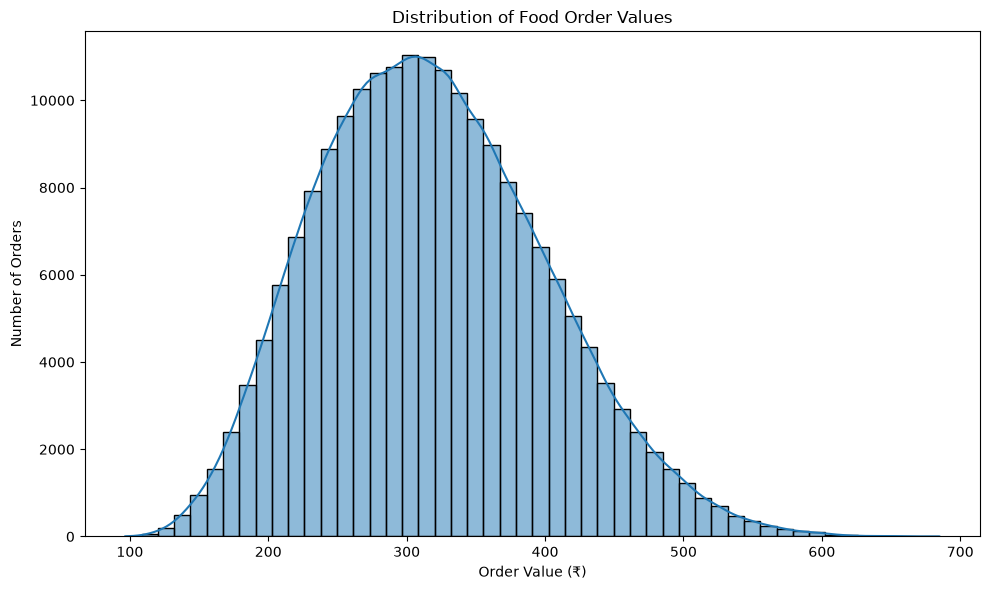

In [15]:
# ============================================================
# ORDER VALUE HISTOGRAM
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    order_value_sample,
    bins=50,
    kde=True
)

plt.title("Distribution of Food Order Values")
plt.xlabel("Order Value (₹)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

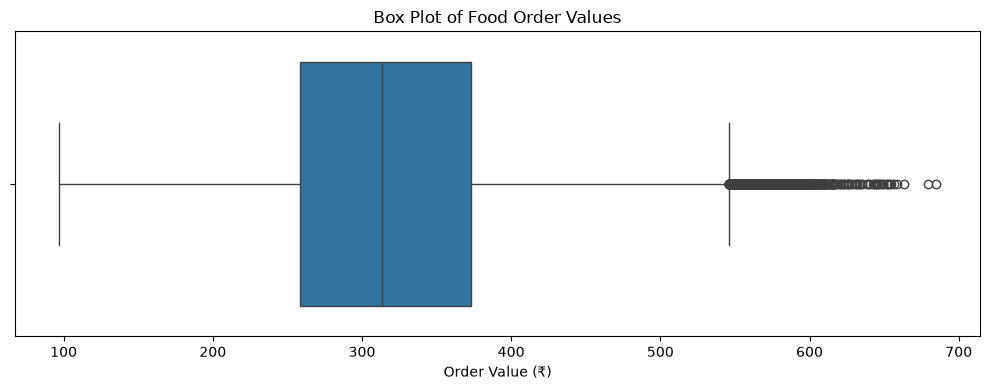

In [16]:
# ============================================================
# ORDER VALUE BOX PLOT
# ============================================================

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=order_value_sample
)

plt.title("Box Plot of Food Order Values")
plt.xlabel("Order Value (₹)")

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# ORDER VALUE QUANTILES
# ============================================================

order_value_quantiles = (
    orders_df["order_value"]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .reset_index()
)

order_value_quantiles.columns = [
    "Quantile",
    "Order_Value"
]

order_value_quantiles

,Quantile,Order_Value
0,0.01,158.57
1,0.05,193.79
2,0.25,258.43
3,0.50,313.55
4,0.75,372.96
5,0.95,462.06
6,0.99,523.69


### Order Value Distribution Observations

- The order-value histogram shows that most transactions are concentrated around the ₹250–₹400 range.
- The distribution has a noticeable right tail extending toward higher order values.
- The distribution is positively skewed, indicating that high-value transactions occur less frequently than typical transactions.
- The box plot identifies several higher-value observations beyond the upper whisker.
- These extreme observations are retained because they represent variation produced by the synthetic order-generation process.
- The distribution is therefore not perfectly symmetric and provides useful variation for subsequent behavioral and forecasting analysis.

## 03.2.3 — Meal Period Analysis

This section examines the distribution of food orders across different
meal periods to identify major periods of demand concentration and
intraday ordering behavior.

In [18]:
# ============================================================
# 03.2.3 — MEAL PERIOD ORDER ANALYSIS
# ============================================================

meal_period_summary = (
    orders_df
    .groupby("meal_period")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

meal_period_summary["order_percentage"] = (
    meal_period_summary["order_count"]
    / meal_period_summary["order_count"].sum()
    * 100
)

meal_period_summary

,meal_period,order_count,total_order_value,average_order_value,order_percentage
0,Afternoon,1842245,587060107.17,318.67,10.72
1,Dinner,4348447,1385625128.00,318.65,25.30
2,Evening,2218643,707175236.49,318.74,12.91
3,Late_Morning,1976513,629681610.08,318.58,11.50
4,Late_Night,1518626,483987412.27,318.70,8.83
5,Lunch,3910251,1246050027.72,318.66,22.75
6,Morning,1374232,437722731.41,318.52,7.99


In [19]:
# ============================================================
# ORDER MEAL PERIODS CHRONOLOGICALLY
# ============================================================

meal_order = [
    "Late_Night",
    "Morning",
    "Late_Morning",
    "Lunch",
    "Afternoon",
    "Evening",
    "Dinner"
]

meal_period_summary["meal_period"] = pd.Categorical(
    meal_period_summary["meal_period"],
    categories=meal_order,
    ordered=True
)

meal_period_summary = (
    meal_period_summary
    .sort_values("meal_period")
    .reset_index(drop=True)
)

meal_period_summary

,meal_period,order_count,total_order_value,average_order_value,order_percentage
0,Late_Night,1518626,483987412.27,318.70,8.83
1,Morning,1374232,437722731.41,318.52,7.99
2,Late_Morning,1976513,629681610.08,318.58,11.50
3,Lunch,3910251,1246050027.72,318.66,22.75
4,Afternoon,1842245,587060107.17,318.67,10.72
5,Evening,2218643,707175236.49,318.74,12.91
6,Dinner,4348447,1385625128.00,318.65,25.30


### Meal Period Analysis Observations

- Dinner is the highest-demand meal period, accounting for 25.30% of total transactions.
- Lunch is the second-highest-demand period, contributing 22.75% of total transactions.
- Lunch and Dinner together account for approximately 48.05% of all transactions.
- Evening contributes 12.90% of total orders, indicating substantial demand before the dinner peak.
- Late Morning and Afternoon contribute 11.50% and 10.72%, respectively.
- Morning has the lowest order contribution at approximately 7.99%.
- The strong concentration of orders during Lunch and Dinner confirms the presence of distinct intraday demand patterns that are important for hourly food-demand forecasting.

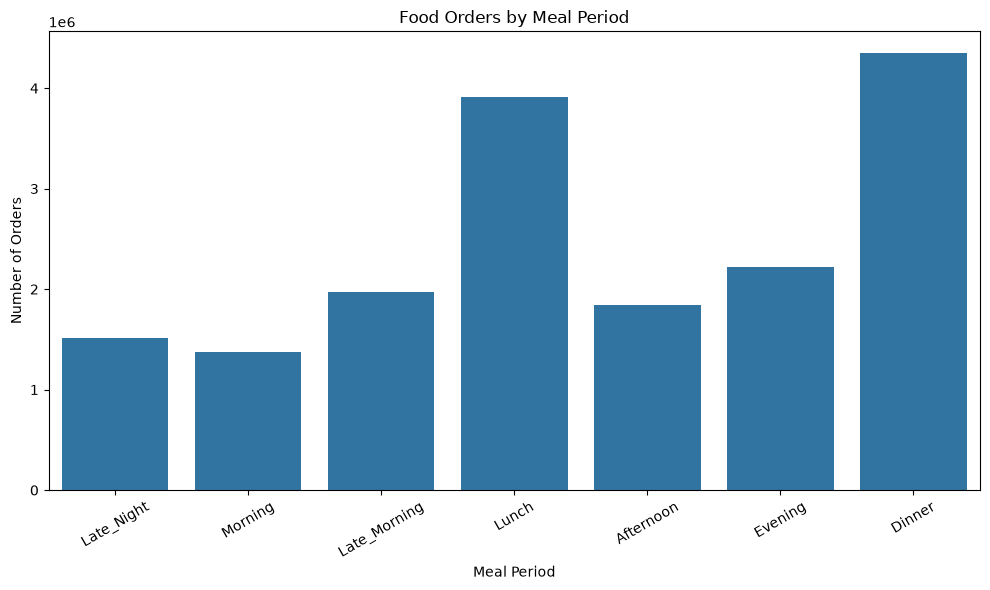

In [20]:
# ============================================================
# MEAL PERIOD ORDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=meal_period_summary,
    x="meal_period",
    y="order_count"
)

plt.title("Food Orders by Meal Period")
plt.xlabel("Meal Period")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 03.2.4 — Weekday vs Weekend Analysis

This section compares food-order volume and order-value characteristics
between weekdays and weekends to identify differences in customer ordering
behavior across day types.

In [21]:
# ============================================================
# 03.2.4 — WEEKDAY VS WEEKEND ANALYSIS
# ============================================================

day_type_summary = (
    orders_df
    .groupby("day_type")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

day_type_summary["order_percentage"] = (
    day_type_summary["order_count"]
    / day_type_summary["order_count"].sum()
    * 100
)

day_type_summary

,day_type,order_count,total_order_value,average_order_value,order_percentage
0,Weekday,11717235,3733676446.47,318.65,68.17
1,Weekend,5471722,1743625806.67,318.66,31.83


In [22]:
# ============================================================
# AVERAGE ORDERS PER CALENDAR DAY
# ============================================================

daily_orders = (
    orders_df
    .assign(order_date=orders_df["order_timestamp"].dt.date)
    .groupby(["order_date", "day_type"])
    .size()
    .reset_index(name="order_count")
)

daily_day_type_summary = (
    daily_orders
    .groupby("day_type")
    .agg(
        average_daily_orders=("order_count", "mean"),
        minimum_daily_orders=("order_count", "min"),
        maximum_daily_orders=("order_count", "max")
    )
    .reset_index()
)

daily_day_type_summary

,day_type,average_daily_orders,minimum_daily_orders,maximum_daily_orders
0,Weekday,12256.52,114,16219
1,Weekend,14286.48,12073,17460


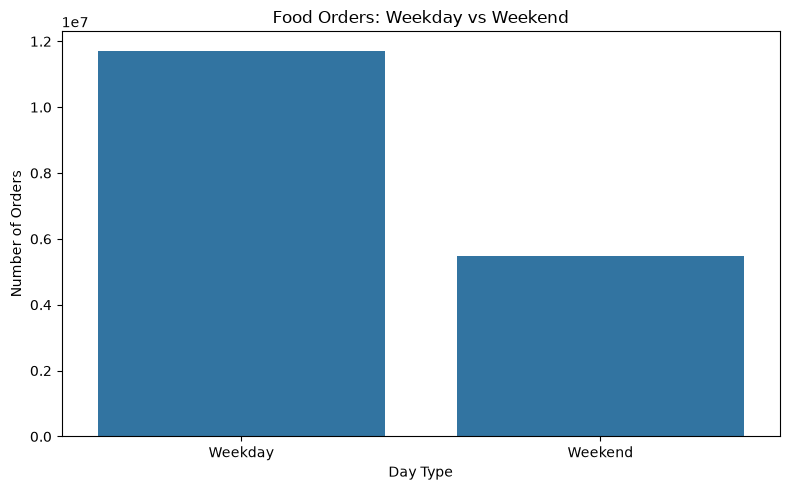

In [23]:
# ============================================================
# WEEKDAY VS WEEKEND ORDER VOLUME
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=day_type_summary,
    x="day_type",
    y="order_count"
)

plt.title("Food Orders: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

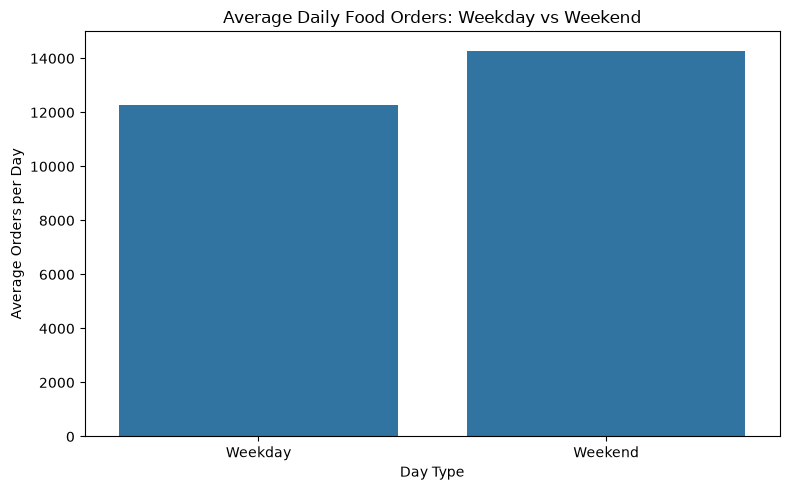

In [24]:
# ============================================================
# AVERAGE DAILY ORDERS BY DAY TYPE
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=daily_day_type_summary,
    x="day_type",
    y="average_daily_orders"
)

plt.title("Average Daily Food Orders: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Orders per Day")

plt.tight_layout()
plt.show()

### Weekday vs Weekend Observations

- Weekdays account for 68.17% of total transactions, while weekends account for 31.83%.
- The higher total weekday volume is expected because there are five weekdays compared with two weekend days in a typical week.
- Average daily order volume provides a more meaningful comparison between the two day types.
- Weekdays have an average of approximately 12,556.52 orders per day.
- Weekends have an average of approximately 14,286.48 orders per day.
- Average daily weekend demand is approximately 13.8% higher than weekday demand.
- This indicates that the synthetic dataset captures stronger daily food-order demand during weekends.
- The observed weekday/weekend difference provides an important temporal pattern for demand forecasting.

## 03.2.5 — Zone-wise Overall Order Contribution

This section examines transaction volume and order-value characteristics
across the five hyperlocal zones. The objective is to identify differences
in overall demand contribution and average order value between zones.

In [25]:
# ============================================================
# 03.2.5 — ZONE-WISE ORDER ANALYSIS
# ============================================================

zone_summary = (
    orders_df
    .groupby("zone_id")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean"),
        unique_customers=("customer_id", "nunique"),
        unique_restaurants=("restaurant_id", "nunique")
    )
    .reset_index()
)

zone_summary["order_percentage"] = (
    zone_summary["order_count"]
    / zone_summary["order_count"].sum()
    * 100
)

zone_summary = zone_summary.sort_values(
    "order_count",
    ascending=False
).reset_index(drop=True)

zone_summary

,zone_id,order_count,total_order_value,average_order_value,unique_customers,unique_restaurants,order_percentage
0,Z02,4250390,1369152828.36,322.12,12121,50,24.73
1,Z03,3911034,1237091639.11,316.31,10936,45,22.75
2,Z05,3209553,1061989092.37,330.88,9926,45,18.67
3,Z04,3127800,969564620.10,309.98,8007,40,18.20
4,Z01,2690180,839504073.20,312.06,9010,40,15.65


In [26]:
# ============================================================
# AVERAGE DAILY ORDERS BY ZONE
# ============================================================

daily_zone_orders = (
    orders_df
    .assign(order_date=orders_df["order_timestamp"].dt.date)
    .groupby(["order_date", "zone_id"])
    .size()
    .reset_index(name="order_count")
)

zone_daily_summary = (
    daily_zone_orders
    .groupby("zone_id")
    .agg(
        average_daily_orders=("order_count", "mean"),
        minimum_daily_orders=("order_count", "min"),
        maximum_daily_orders=("order_count", "max")
    )
    .reset_index()
    .sort_values("average_daily_orders", ascending=False)
)

zone_daily_summary

,zone_id,average_daily_orders,minimum_daily_orders,maximum_daily_orders
1,Z02,3174.30,30,4388
2,Z03,2920.86,23,4103
4,Z05,2396.98,23,3343
3,Z04,2335.92,19,3232
0,Z01,2009.10,19,2833


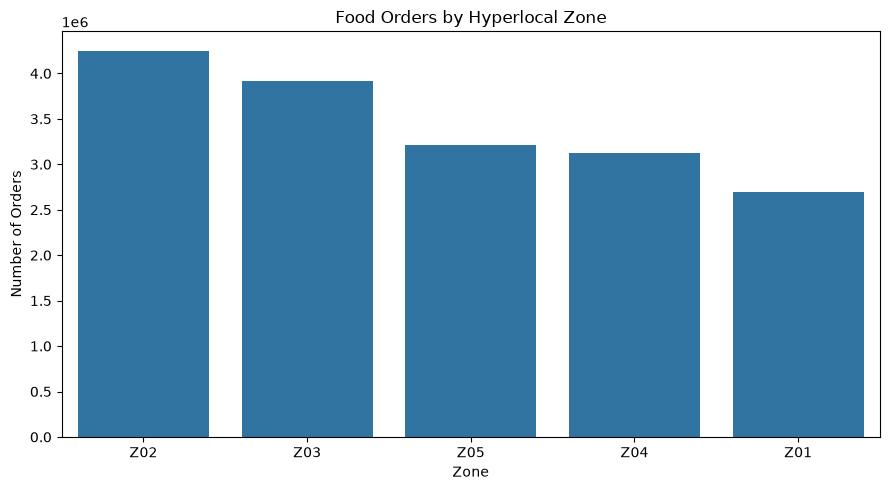

In [27]:
# ============================================================
# ZONE-WISE ORDER VOLUME
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=zone_summary,
    x="zone_id",
    y="order_count"
)

plt.title("Food Orders by Hyperlocal Zone")
plt.xlabel("Zone")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

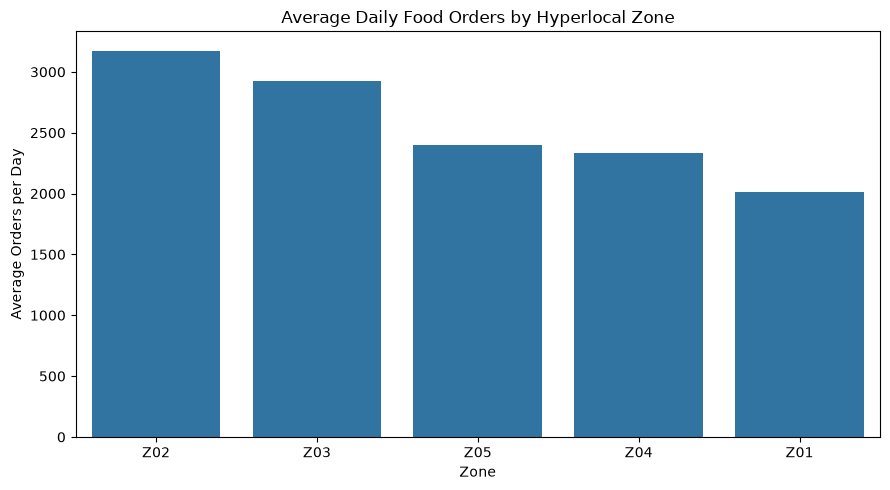

In [28]:
# ============================================================
# AVERAGE DAILY ORDERS BY ZONE
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=zone_daily_summary,
    x="zone_id",
    y="average_daily_orders"
)

plt.title("Average Daily Food Orders by Hyperlocal Zone")
plt.xlabel("Zone")
plt.ylabel("Average Orders per Day")

plt.tight_layout()
plt.show()

### Zone-wise Demand Observations

- Z02 contributes the highest transaction volume with 4,250,390 orders, representing 24.74% of all transactions.
- Z03 is the second-highest-demand zone with 3,911,034 orders and a 22.75% contribution.
- Z05 and Z04 contribute 18.67% and 18.20% of total transactions, respectively.
- Z01 has the lowest transaction volume at 2,690,180 orders, representing 15.65%.
- The average daily order ranking is consistent with the overall transaction-volume ranking.
- The substantial differences in demand across zones demonstrate meaningful spatial variation in the synthetic dataset.
- These spatial differences support the hyperlocal forecasting design, where demand is modeled separately at zone level rather than treating Hyderabad as a single aggregate market.

## 03.2.6 — Overall EDA Summary

The overall exploratory analysis was performed to understand the major
transaction, order-value, temporal, and spatial characteristics of the
synthetic food-order dataset.

### Key Findings

- The dataset contains 17,188,957 food-order transactions involving
  50,000 customers, 220 restaurants, and five hyperlocal zones.
- The mean order value is ₹318.65 and the median is ₹313.55.
- The middle 50% of order values range from ₹258.43 to ₹372.96.
- The order-value distribution is positively skewed, with a longer
  upper tail and several higher-value observations.
- Dinner is the highest-volume meal period, contributing 25.30% of
  transactions, followed by Lunch at 22.75%.
- Lunch and Dinner together account for approximately 48.05% of all
  transactions.
- Weekend average daily demand is approximately 13.8% higher than
  weekday average daily demand.
- Z02 has the highest transaction contribution at 24.74%, while Z01
  has the lowest at 15.65%.
- The differences in demand across zones demonstrate meaningful
  spatial variation in the synthetic dataset.
- The observed temporal and spatial patterns provide a suitable
  foundation for zone-level and hourly food-demand forecasting.

## 03.3 — Hourly Demand Analysis

This section examines intraday food-order patterns to identify demand
peaks, low-demand periods, and recurring hourly variations across the
study period.

Understanding hourly demand patterns is essential for developing and
evaluating hourly hyperlocal food-demand forecasting models.

In [29]:
# ============================================================
# 03.3.1 — EXTRACT ORDER HOUR
# ============================================================

orders_df["order_hour"] = orders_df["order_timestamp"].dt.hour

print("Order hour extracted successfully.")
print(
    "Hour range:",
    orders_df["order_hour"].min(),
    "to",
    orders_df["order_hour"].max()
)

Order hour extracted successfully.
Hour range: 0 to 23


In [30]:
# ============================================================
# HOURLY ORDER SUMMARY
# ============================================================

hourly_summary = (
    orders_df
    .groupby("order_hour")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

hourly_summary["order_percentage"] = (
    hourly_summary["order_count"]
    / hourly_summary["order_count"].sum()
    * 100
)

hourly_summary

,order_hour,order_count,total_order_value,average_order_value,order_percentage
0,0,179925,57338606.34,318.68,1.05
1,1,161869,51590426.29,318.72,0.94
2,2,143836,45852491.72,318.78,0.84
3,3,134731,42890177.19,318.34,0.78
4,4,134776,42989903.03,318.97,0.78
5,5,161770,51452326.31,318.06,0.94
6,6,224681,71564941.85,318.52,1.31
7,7,404196,128755986.72,318.55,2.35
8,8,583585,185949476.53,318.63,3.40
9,9,673233,214484926.65,318.59,3.92


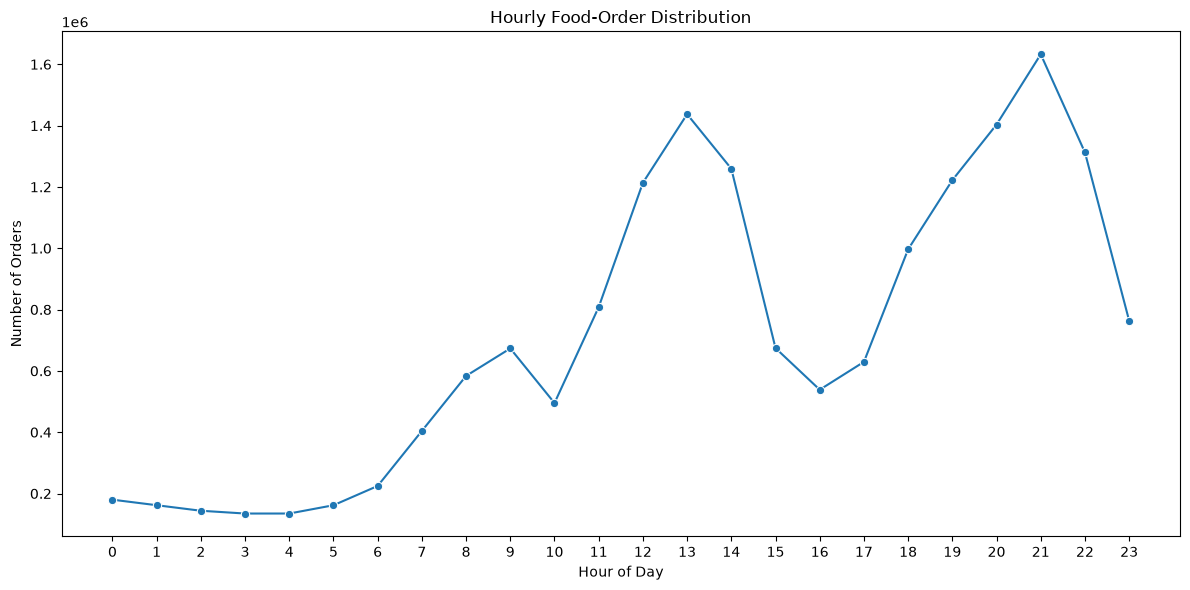

In [31]:
# ============================================================
# HOURLY ORDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_summary,
    x="order_hour",
    y="order_count",
    marker="o"
)

plt.title("Hourly Food-Order Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# PEAK AND LOW-DEMAND HOURS
# ============================================================

peak_hour = hourly_summary.loc[
    hourly_summary["order_count"].idxmax()
]

lowest_hour = hourly_summary.loc[
    hourly_summary["order_count"].idxmin()
]

print("Peak demand hour:")
print(peak_hour)

print("\nLowest demand hour:")
print(lowest_hour)

Peak demand hour:
order_hour                   21.00
order_count             1632592.00
total_order_value     520066436.73
average_order_value         318.55
order_percentage              9.50
Name: 21, dtype: float64

Lowest demand hour:
order_hour                   3.00
order_count             134731.00
total_order_value     42890177.19
average_order_value        318.34
order_percentage             0.78
Name: 3, dtype: float64


### Hourly Demand Observations

- Food-order demand exhibits a clear intraday seasonal pattern across the 24-hour period.
- The highest transaction volume occurs at 21:00, with 1,623,592 orders representing approximately 9.50% of total transactions.
- The lowest transaction volume occurs at 03:00, with 134,731 orders representing approximately 0.78% of total transactions.
- Demand remains relatively low during the early-morning hours and begins increasing during the morning.
- A major demand peak is observed during the lunch period, particularly around 12:00–14:00.
- Demand decreases during the afternoon before increasing again during the evening.
- The strongest demand peak occurs during the dinner period, centered around 21:00.
- The observed hourly variation demonstrates strong intraday seasonality that is highly relevant to hourly food-demand forecasting.

## 03.3.2 — Hourly Demand by Hyperlocal Zone

This section examines hourly food-order volume separately for each
hyperlocal zone to identify whether intraday demand patterns differ
across zones.

The analysis helps determine whether hourly demand forecasting should
capture both temporal and spatial variation.

In [33]:
# ============================================================
# 03.3.2 — HOURLY DEMAND BY ZONE
# ============================================================

hourly_zone_summary = (
    orders_df
    .groupby(["zone_id", "order_hour"])
    .agg(
        order_count=("order_id", "count"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

hourly_zone_summary["order_percentage"] = (
    hourly_zone_summary.groupby("zone_id")["order_count"]
    .transform(lambda x: x / x.sum() * 100)
)

hourly_zone_summary.head(20)

,zone_id,order_hour,order_count,average_order_value,order_percentage
0,Z01,0,28133,311.42,1.05
1,Z01,1,25359,312.76,0.94
2,Z01,2,22505,310.73,0.84
3,Z01,3,21090,311.24,0.78
4,Z01,4,21101,311.48,0.78
5,Z01,5,25336,311.13,0.94
6,Z01,6,35164,312.34,1.31
7,Z01,7,63374,311.64,2.36
8,Z01,8,91192,312.22,3.39
9,Z01,9,105259,312.37,3.91


In [34]:
# ============================================================
# PEAK HOUR BY ZONE
# ============================================================

peak_hour_by_zone = (
    hourly_zone_summary.loc[
        hourly_zone_summary.groupby("zone_id")["order_count"].idxmax()
    ]
    .sort_values("zone_id")
    .reset_index(drop=True)
)

peak_hour_by_zone

,zone_id,order_hour,order_count,average_order_value,order_percentage
0,Z01,21,255018,312.23,9.48
1,Z02,21,403639,322.07,9.50
2,Z03,21,371529,316.26,9.50
3,Z04,21,297807,309.53,9.52
4,Z05,21,304599,330.80,9.49


In [35]:
# ============================================================
# LOWEST-DEMAND HOUR BY ZONE
# ============================================================

lowest_hour_by_zone = (
    hourly_zone_summary.loc[
        hourly_zone_summary.groupby("zone_id")["order_count"].idxmin()
    ]
    .sort_values("zone_id")
    .reset_index(drop=True)
)

lowest_hour_by_zone

,zone_id,order_hour,order_count,average_order_value,order_percentage
0,Z01,3,21090,311.24,0.78
1,Z02,4,33309,322.63,0.78
2,Z03,4,30632,316.05,0.78
3,Z04,3,24496,310.03,0.78
4,Z05,3,25144,330.49,0.78


In [36]:
# ============================================================
# ZONE × HOUR DEMAND MATRIX
# ============================================================

zone_hour_matrix = (
    hourly_zone_summary
    .pivot(
        index="zone_id",
        columns="order_hour",
        values="order_count"
    )
)

zone_hour_matrix

order_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
zone_id,,,,,,,,,,,,,,,,,,,,,,,,
Z01,28133,25359,22505,21090,21101,25336,35164,63374,91192,105259,77509,126586,189662,225105,196851,105455,84192,98660,156240,192059,219898,255018,204921,119511
Z02,44530,40035,35539,33312,33309,39985,55509,99756,144381,166247,122554,199466,300334,355600,311523,166598,133182,155617,245837,302504,347319,403639,325035,188579
Z03,40915,36835,32744,30689,30632,36868,51124,91902,132985,153372,112661,184185,276127,326993,286708,153345,122350,143203,227124,277446,319243,371529,298430,173624
Z04,32708,29379,26124,24496,24520,29375,40903,73628,105969,122464,90016,146907,221002,261291,229327,122433,98088,114356,181077,222148,255265,297807,239345,139172
Z05,33639,30261,26924,25144,25214,30206,41981,75536,109058,125891,92416,150980,226482,268261,234985,126443,100739,117584,186293,227915,261740,304599,244659,142603


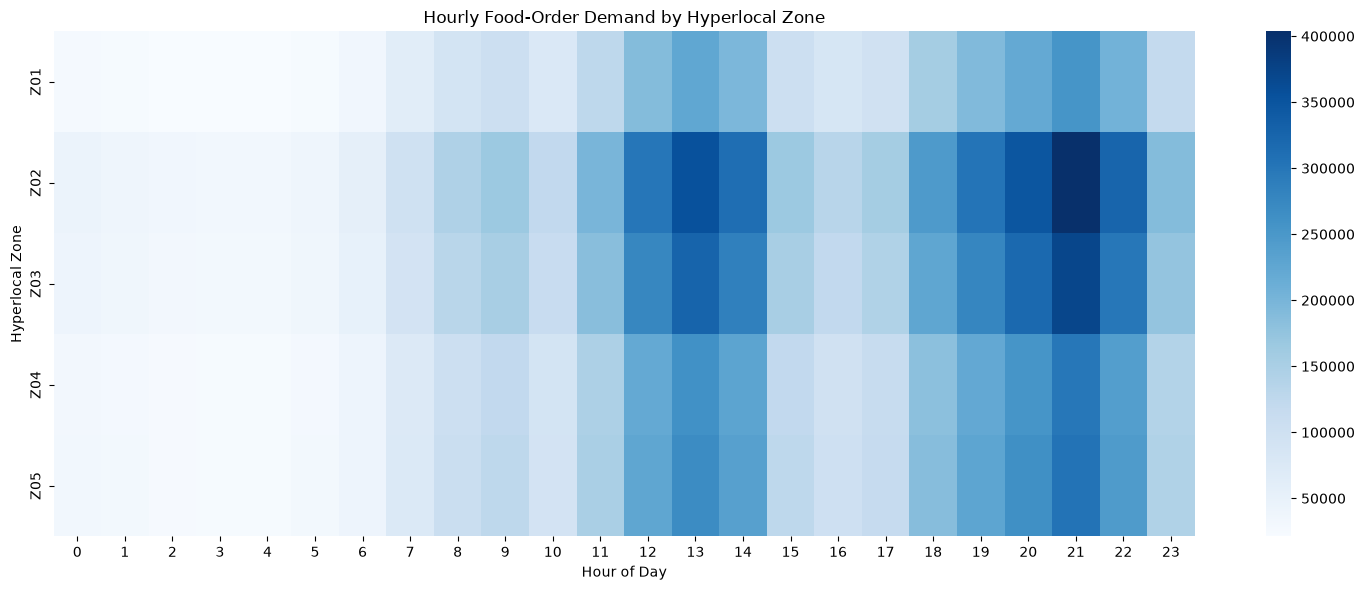

In [37]:
# ============================================================
# ZONE × HOUR DEMAND HEATMAP
# ============================================================

plt.figure(figsize=(15, 6))

sns.heatmap(
    zone_hour_matrix,
    cmap="Blues",
    annot=False,
    fmt=".0f"
)

plt.title("Hourly Food-Order Demand by Hyperlocal Zone")
plt.xlabel("Hour of Day")
plt.ylabel("Hyperlocal Zone")

plt.tight_layout()
plt.show()

### Hourly Demand by Zone — Observations

- All five hyperlocal zones record their highest hourly transaction volume at 21:00.
- The lowest-demand hour occurs around the early-morning period, with Z01 and Z05 reaching their minimum at 03:00 and Z02, Z03, and Z04 reaching their minimum at 04:00.
- The consistent peak timing across zones indicates a common intraday demand cycle in the synthetic dataset.
- Although the timing of peak demand is similar across zones, the magnitude of demand differs substantially between zones.
- Z02 and Z03 consistently exhibit higher absolute demand levels, while Z01 has the lowest overall demand contribution.
- These results demonstrate that the forecasting problem contains both temporal variation and spatial variation.
- Therefore, zone-level forecasting can capture differences in demand magnitude while preserving the common intraday seasonal structure.

## 03.3.3 — Hourly Demand by Day Type

This section compares hourly food-order demand between weekdays and
weekends to determine whether the intraday demand pattern changes
according to day type.

The analysis examines both demand magnitude and hourly demand share.

In [38]:
# ============================================================
# 03.3.3 — HOURLY DEMAND BY DAY TYPE
# ============================================================

hourly_day_type_summary = (
    orders_df
    .groupby(["day_type", "order_hour"])
    .agg(
        order_count=("order_id", "count"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

hourly_day_type_summary["order_percentage"] = (
    hourly_day_type_summary
    .groupby("day_type")["order_count"]
    .transform(lambda x: x / x.sum() * 100)
)

hourly_day_type_summary.head(10)

,day_type,order_hour,order_count,average_order_value,order_percentage
0,Weekday,0,122604,318.66,1.05
1,Weekday,1,110324,318.84,0.94
2,Weekday,2,98122,318.94,0.84
3,Weekday,3,91839,318.25,0.78
4,Weekday,4,91936,319.00,0.78
5,Weekday,5,110303,317.98,0.94
6,Weekday,6,153161,318.37,1.31
7,Weekday,7,275436,318.46,2.35
8,Weekday,8,397762,318.56,3.39
9,Weekday,9,459133,318.49,3.92


In [39]:
# ============================================================
# PEAK HOUR BY DAY TYPE
# ============================================================

peak_hour_by_day_type = (
    hourly_day_type_summary.loc[
        hourly_day_type_summary
        .groupby("day_type")["order_count"]
        .idxmax()
    ]
    .reset_index(drop=True)
)

peak_hour_by_day_type

,day_type,order_hour,order_count,average_order_value,order_percentage
0,Weekday,21,1112008,318.54,9.49
1,Weekend,21,520584,318.59,9.51


In [40]:
# ============================================================
# LOWEST-DEMAND HOUR BY DAY TYPE
# ============================================================

lowest_hour_by_day_type = (
    hourly_day_type_summary.loc[
        hourly_day_type_summary
        .groupby("day_type")["order_count"]
        .idxmin()
    ]
    .reset_index(drop=True)
)

lowest_hour_by_day_type

,day_type,order_hour,order_count,average_order_value,order_percentage
0,Weekday,3,91839,318.25,0.78
1,Weekend,4,42840,318.92,0.78


In [41]:
# ============================================================
# WEEKDAY VS WEEKEND HOURLY DEMAND MATRIX
# ============================================================

day_type_hour_matrix = (
    hourly_day_type_summary
    .pivot(
        index="order_hour",
        columns="day_type",
        values="order_count"
    )
)

day_type_hour_matrix

day_type,Weekday,Weekend
order_hour,,
0,122604,57321
1,110324,51545
2,98122,45714
3,91839,42892
4,91936,42840
5,110303,51467
6,153161,71520
7,275436,128760
8,397762,185823


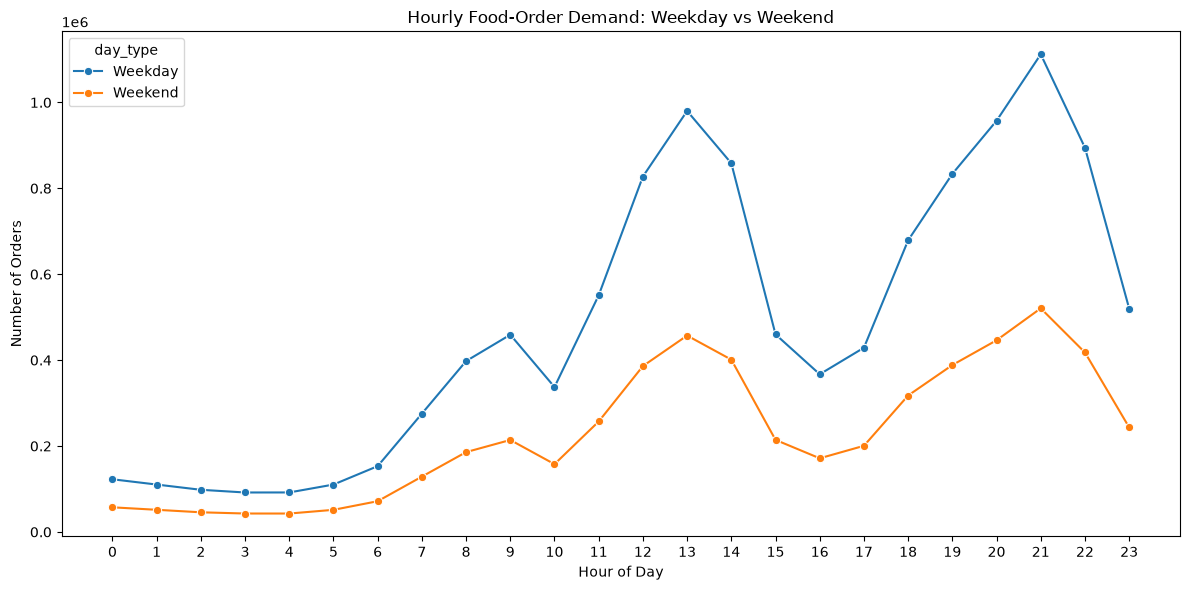

In [42]:
# ============================================================
# WEEKDAY VS WEEKEND HOURLY DEMAND
# ============================================================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_day_type_summary,
    x="order_hour",
    y="order_count",
    hue="day_type",
    marker="o"
)

plt.title("Hourly Food-Order Demand: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

### Hourly Demand by Day Type — Observations

- Both weekdays and weekends reach their highest hourly demand at 21:00.
- Weekday demand peaks at approximately 1,112,008 orders at 21:00, representing 9.49% of weekday transactions.
- Weekend demand peaks at approximately 520,584 orders at 21:00, representing 9.51% of weekend transactions.
- The lowest weekday demand occurs at 03:00, while the lowest weekend demand occurs at 04:00.
- Both day types exhibit a similar intraday demand shape, characterized by low early-morning demand, a lunch-period increase, an afternoon decline, an evening recovery, and a strong dinner peak.
- The similar peak-hour shares indicate that the underlying hourly demand structure remains broadly consistent across weekdays and weekends.
- Differences in overall demand magnitude are influenced by the different number of weekdays and weekend days within a typical week.
- The results indicate that both hour-of-day and day type are important dimensions for subsequent demand forecasting analysis.

## 03.3.4 — Day-of-Week Demand Analysis

This section examines food-order demand across the seven days of the
week to identify recurring weekly patterns and differences in demand
between individual weekdays and weekend days.

In [43]:
# ============================================================
# 03.3.4 — DAY-OF-WEEK DEMAND ANALYSIS
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_of_week_summary = (
    orders_df
    .groupby("day_of_week")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

day_of_week_summary["order_percentage"] = (
    day_of_week_summary["order_count"]
    / day_of_week_summary["order_count"].sum()
    * 100
)

day_of_week_summary["day_of_week"] = pd.Categorical(
    day_of_week_summary["day_of_week"],
    categories=day_order,
    ordered=True
)

day_of_week_summary = (
    day_of_week_summary
    .sort_values("day_of_week")
    .reset_index(drop=True)
)

day_of_week_summary

,day_of_week,order_count,total_order_value,average_order_value,order_percentage
0,Monday,2088902,665730725.89,318.70,12.15
1,Tuesday,2206706,703104440.79,318.62,12.84
2,Wednesday,2321640,739887196.88,318.69,13.51
3,Thursday,2434795,775862046.99,318.66,14.16
4,Friday,2665192,849092035.92,318.59,15.51
5,Saturday,2901524,924433457.67,318.60,16.88
6,Sunday,2570198,819192349.00,318.73,14.95


### Day-of-Week Demand Observations

- Saturday records the highest transaction volume with 2,901,524 orders, representing 16.88% of total transactions.
- Monday records the lowest transaction volume with 2,088,902 orders, representing 12.15% of total transactions.
- Order volume generally increases from Monday through Saturday.
- Friday shows a substantial increase in demand compared with the earlier weekdays.
- Saturday represents the strongest day-of-week demand, followed by Sunday.
- Sunday demand decreases compared with Saturday but remains higher than most weekdays.
- Average order values remain relatively stable across all seven days, indicating that day-of-week variation is primarily associated with order volume rather than transaction value.
- The observed weekly pattern demonstrates recurring day-of-week seasonality that can be relevant to hourly demand forecasting.

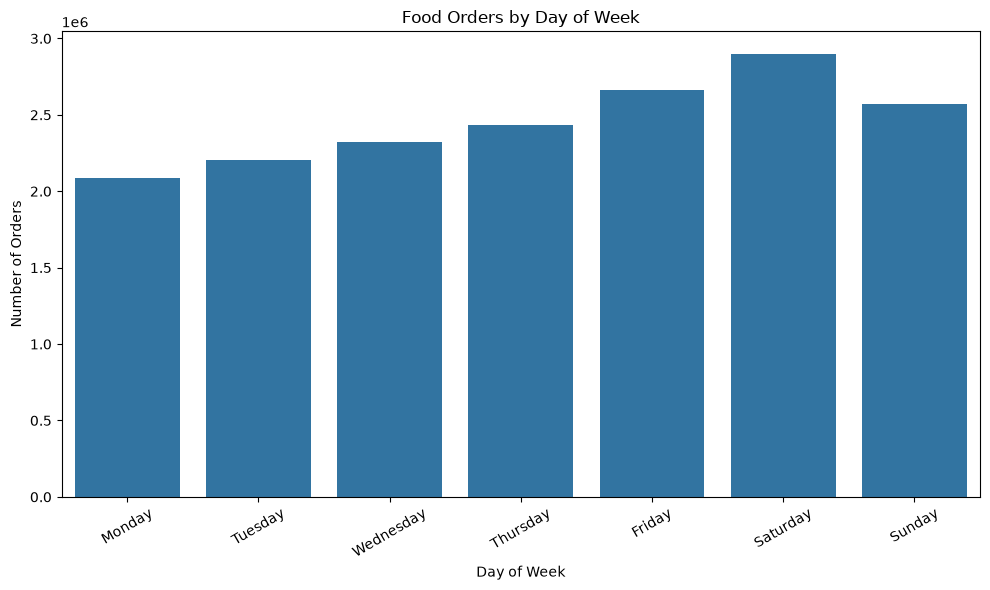

In [44]:
# ============================================================
# DAY-OF-WEEK ORDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=day_of_week_summary,
    x="day_of_week",
    y="order_count"
)

plt.title("Food Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 03.3.5 — Hour × Day-of-Week Analysis

### Objective

This analysis investigates the interaction between the hour of the day
and the day of the week to identify recurring temporal demand patterns.

The analysis includes:

- Order volume for each day-hour combination.
- A 7 × 24 day-hour demand matrix.
- Identification of peak and lowest-demand hour combinations.
- Heatmap visualization of hourly demand across the seven days.
- Interpretation of temporal patterns relevant to food-demand forecasting.

In [45]:
# ============================================================
# 03.3.5 — HOURLY DEMAND BY DAY OF WEEK
# ============================================================

day_hour_summary = (
    orders_df
    .groupby(["day_of_week", "order_hour"])
    .agg(
        order_count=("order_id", "count"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

day_hour_summary["order_percentage"] = (
    day_hour_summary["order_count"]
    / day_hour_summary["order_count"].sum()
    * 100
)

day_hour_summary.head(10)

,day_of_week,order_hour,order_count,average_order_value,order_percentage
0,Friday,0,27853,319.28,0.16
1,Friday,1,25144,319.20,0.15
2,Friday,2,22296,318.57,0.13
3,Friday,3,20888,318.66,0.12
4,Friday,4,20914,319.33,0.12
5,Friday,5,25187,319.02,0.15
6,Friday,6,34844,318.11,0.20
7,Friday,7,62606,318.23,0.36
8,Friday,8,90390,318.33,0.53
9,Friday,9,104422,318.57,0.61


In [46]:
# ============================================================
# DAY × HOUR DEMAND MATRIX
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_hour_matrix = (
    day_hour_summary
    .pivot(
        index="day_of_week",
        columns="order_hour",
        values="order_count"
    )
    .reindex(day_order)
)

day_hour_matrix

order_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,,,,
Monday,22020,19696,17515,16374,16445,19653,27404,49215,70833,81868,60163,98156,147059,174764,153628,81954,65627,76455,121410,147923,170538,198093,159661,92448
Tuesday,23056,20744,18501,17336,17331,20719,28832,51877,75118,86308,63386,103716,156061,184862,161474,86414,69084,80701,127710,156887,180179,209621,168669,98120
Wednesday,24247,21792,19404,18155,18176,21850,30270,54393,78608,91162,66856,109130,164139,194164,169770,90979,72706,84962,134699,165111,190398,220383,177167,103119
Thursday,25428,22948,20406,19086,19070,22894,31811,57345,82813,95373,70122,114372,171755,203206,178319,95697,76301,89271,141274,173524,199345,230772,185726,107937
Friday,27853,25144,22296,20888,20914,25187,34844,62606,90390,104422,76822,125632,188461,223078,195098,104904,83395,97507,153840,190107,216798,253139,203356,118511
Saturday,30361,27316,24213,22738,22716,27265,37943,68293,98717,113664,83635,136648,204891,242642,213080,113670,90844,106054,168295,205475,236071,276486,221457,129050
Sunday,26960,24229,21501,20154,20124,24202,33577,60467,87106,100436,74172,120470,181241,214534,188025,100656,80594,94470,149343,183045,210136,244098,196354,114304


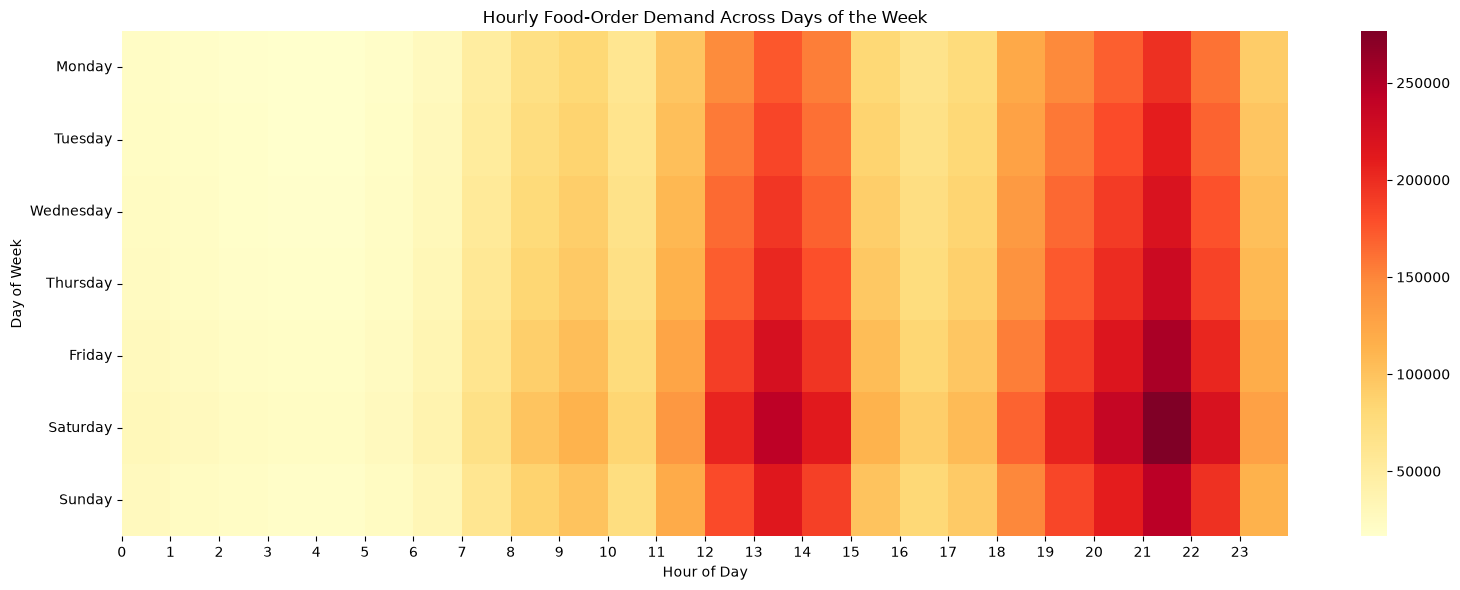

In [47]:
# ============================================================
# DAY × HOUR DEMAND HEATMAP
# ============================================================

plt.figure(figsize=(16, 6))

sns.heatmap(
    day_hour_matrix,
    cmap="YlOrRd",
    annot=False,
    fmt=".0f"
)

plt.title("Hourly Food-Order Demand Across Days of the Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.xticks(range(24), range(24))

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# PEAK DEMAND HOUR FOR EACH DAY
# ============================================================

peak_hour_by_day = (
    day_hour_summary.loc[
        day_hour_summary
        .groupby("day_of_week")["order_count"]
        .idxmax()
    ]
    .set_index("day_of_week")
    .reindex(day_order)
    .reset_index()
)

peak_hour_by_day

,day_of_week,order_hour,order_count,average_order_value,order_percentage
0,Monday,21,198093,318.45,1.15
1,Tuesday,21,209621,318.76,1.22
2,Wednesday,21,220383,318.70,1.28
3,Thursday,21,230772,318.29,1.34
4,Friday,21,253139,318.50,1.47
5,Saturday,21,276486,318.29,1.61
6,Sunday,21,244098,318.92,1.42


In [49]:
# ============================================================
# LOWEST-DEMAND HOUR FOR EACH DAY
# ============================================================

lowest_hour_by_day = (
    day_hour_summary.loc[
        day_hour_summary
        .groupby("day_of_week")["order_count"]
        .idxmin()
    ]
    .set_index("day_of_week")
    .reindex(day_order)
    .reset_index()
)

lowest_hour_by_day

,day_of_week,order_hour,order_count,average_order_value,order_percentage
0,Monday,3,16374,317.85,0.10
1,Tuesday,4,17331,318.68,0.10
2,Wednesday,3,18155,318.47,0.11
3,Thursday,4,19070,318.87,0.11
4,Friday,3,20888,318.66,0.12
5,Saturday,4,22716,318.53,0.13
6,Sunday,4,20124,319.35,0.12


### Hour × Day-of-Week Analysis — Observations

- Hourly food-order demand exhibits a consistent intraday pattern across
  the seven days of the week.
- All seven days record their highest hourly order volume at 21:00.
- The lowest-demand hours occur during the early morning, with the
  minimum occurring at 03:00 or 04:00 depending on the day.
- Demand increases during the morning and reaches a secondary peak
  around the lunch period.
- Following the afternoon decline, demand increases during the evening
  and reaches its strongest peak around dinner time.
- Saturday exhibits particularly high absolute demand during the major
  demand periods.
- The findings indicate that hour of day and day of week should be
  considered together when investigating temporal demand patterns.
- These patterns provide a foundation for subsequent hourly forecasting
  experiments using the synthetic transaction dataset.

## 03.3.6 — Zone × Day-of-Week Analysis

### Objective

This analysis examines food-order demand across the five hyperlocal
zones and seven days of the week.

The analysis aims to:

- Compare order volumes across zones and days.
- Calculate average daily order volume for each zone-day combination.
- Identify the highest- and lowest-demand days for each zone.
- Visualize weekly demand patterns using a zone-day heatmap.
- Investigate spatial and weekly demand variation relevant to forecasting.

In [51]:
# ============================================================
# 03.3.6 — ZONE × DAY-OF-WEEK ANALYSIS
# ============================================================

zone_day_summary = (
    orders_df
    .groupby(["zone_id", "day_of_week"])
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

zone_day_summary["order_percentage"] = (
    zone_day_summary["order_count"]
    / zone_day_summary["order_count"].sum()
    * 100
)

zone_day_summary.head(15)

,zone_id,day_of_week,order_count,total_order_value,average_order_value,order_percentage
0,Z01,Friday,417450,130201318.07,311.90,2.43
1,Z01,Monday,326802,102009356.04,312.14,1.90
2,Z01,Saturday,454640,141845646.06,312.00,2.64
3,Z01,Sunday,402055,125447790.42,312.02,2.34
4,Z01,Thursday,380262,118781826.40,312.37,2.21
5,Z01,Tuesday,345874,107895329.29,311.95,2.01
6,Z01,Wednesday,363097,113322806.92,312.10,2.11
7,Z02,Friday,659247,212373915.17,322.15,3.84
8,Z02,Monday,515958,166314109.11,322.34,3.00
9,Z02,Saturday,716385,230685952.76,322.01,4.17


In [52]:
# ============================================================
# ZONE × DAY-OF-WEEK DEMAND MATRIX
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

zone_day_matrix = (
    zone_day_summary
    .pivot(
        index="zone_id",
        columns="day_of_week",
        values="order_count"
    )
    .reindex(columns=day_order)
    .sort_index()
)

zone_day_matrix

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
zone_id,,,,,,,
Z01,326802,345874,363097,380262,417450,454640,402055
Z02,515958,545565,574360,602848,659247,716385,636027
Z03,475391,502497,528065,554604,605554,660073,584850
Z04,380766,401460,422453,442813,484765,528209,467334
Z05,389985,411310,433665,454268,498176,542217,479932


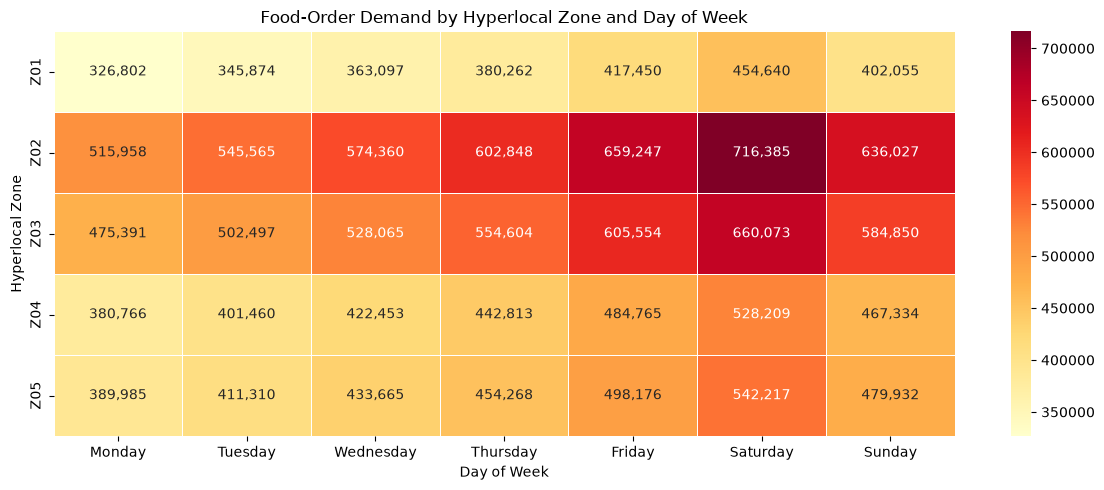

In [53]:
# ============================================================
# ZONE × DAY-OF-WEEK DEMAND HEATMAP
# ============================================================

plt.figure(figsize=(12, 5))

sns.heatmap(
    zone_day_matrix,
    cmap="YlOrRd",
    annot=True,
    fmt=",.0f",
    linewidths=0.5
)

plt.title("Food-Order Demand by Hyperlocal Zone and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Hyperlocal Zone")

plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# PEAK DEMAND DAY BY ZONE
# ============================================================

peak_day_by_zone = (
    zone_day_summary.loc[
        zone_day_summary
        .groupby("zone_id")["order_count"]
        .idxmax()
    ]
    .sort_values("zone_id")
    .reset_index(drop=True)
)

peak_day_by_zone

,zone_id,day_of_week,order_count,total_order_value,average_order_value,order_percentage
0,Z01,Saturday,454640,141845646.06,312.00,2.64
1,Z02,Saturday,716385,230685952.76,322.01,4.17
2,Z03,Saturday,660073,208731651.70,316.23,3.84
3,Z04,Saturday,528209,163737130.73,309.99,3.07
4,Z05,Saturday,542217,179433076.42,330.92,3.15


In [55]:
# ============================================================
# LOWEST-DEMAND DAY BY ZONE
# ============================================================

lowest_day_by_zone = (
    zone_day_summary.loc[
        zone_day_summary
        .groupby("zone_id")["order_count"]
        .idxmin()
    ]
    .sort_values("zone_id")
    .reset_index(drop=True)
)

lowest_day_by_zone

,zone_id,day_of_week,order_count,total_order_value,average_order_value,order_percentage
0,Z01,Monday,326802,102009356.04,312.14,1.90
1,Z02,Monday,515958,166314109.11,322.34,3.00
2,Z03,Monday,475391,150325627.66,316.21,2.77
3,Z04,Monday,380766,118068489.56,310.08,2.22
4,Z05,Monday,389985,129013143.52,330.82,2.27


### Zone × Day-of-Week Analysis — Observations

- All five hyperlocal zones record their highest daily transaction
  volume on Saturday.
- Monday records the lowest daily transaction volume across all zones.
- Z02 has the highest absolute order volume, followed by Z03, Z05,
  Z04, and Z01.
- The weekly demand pattern generally increases from Monday through
  Saturday and decreases on Sunday.
- The consistent ordering of demand across the five zones indicates
  that the synthetic dataset shares a common day-of-week pattern.
- Differences in absolute order volume across zones highlight the
  importance of spatial variation in demand forecasting.
- These findings describe the generated synthetic dataset and should
  not be interpreted as verified real-world demand patterns.
- Zone and day-of-week features can be investigated as predictors
  in subsequent forecasting experiments.

## 03.3.7 — Normalized Zone × Day-of-Week Analysis

### Objective

This analysis compares the distribution of food-order transactions
across the seven days of the week within each hyperlocal zone.

The analysis aims to:

- Calculate each day's percentage of its zone's total transactions.
- Compare weekly demand composition across the five zones.
- Identify days that contribute the largest and smallest shares of
  each zone's transactions.
- Visualize normalized weekly demand patterns using a heatmap.

Normalization helps separate differences in total zone volume from
differences in the distribution of orders across the week.

In [56]:
# ============================================================
# 03.3.7 — NORMALIZED ZONE × DAY-OF-WEEK ANALYSIS
# ============================================================

zone_day_normalized = zone_day_summary.copy()

zone_day_normalized["zone_day_percentage"] = (
    zone_day_normalized["order_count"]
    / zone_day_normalized.groupby("zone_id")["order_count"]
        .transform("sum")
    * 100
)

zone_day_normalized = zone_day_normalized.sort_values(
    ["zone_id", "day_of_week"]
)

zone_day_normalized.head(15)

,zone_id,day_of_week,order_count,total_order_value,average_order_value,order_percentage,zone_day_percentage
0,Z01,Friday,417450,130201318.07,311.90,2.43,15.52
1,Z01,Monday,326802,102009356.04,312.14,1.90,12.15
2,Z01,Saturday,454640,141845646.06,312.00,2.64,16.90
3,Z01,Sunday,402055,125447790.42,312.02,2.34,14.95
4,Z01,Thursday,380262,118781826.40,312.37,2.21,14.14
5,Z01,Tuesday,345874,107895329.29,311.95,2.01,12.86
6,Z01,Wednesday,363097,113322806.92,312.10,2.11,13.50
7,Z02,Friday,659247,212373915.17,322.15,3.84,15.51
8,Z02,Monday,515958,166314109.11,322.34,3.00,12.14
9,Z02,Saturday,716385,230685952.76,322.01,4.17,16.85


In [57]:
# ============================================================
# NORMALIZED ZONE × DAY-OF-WEEK MATRIX
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

zone_day_percentage_matrix = (
    zone_day_normalized
    .pivot(
        index="zone_id",
        columns="day_of_week",
        values="zone_day_percentage"
    )
    .reindex(columns=day_order)
    .sort_index()
)

zone_day_percentage_matrix

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
zone_id,,,,,,,
Z01,12.15,12.86,13.50,14.14,15.52,16.90,14.95
Z02,12.14,12.84,13.51,14.18,15.51,16.85,14.96
Z03,12.16,12.85,13.50,14.18,15.48,16.88,14.95
Z04,12.17,12.84,13.51,14.16,15.50,16.89,14.94
Z05,12.15,12.82,13.51,14.15,15.52,16.89,14.95


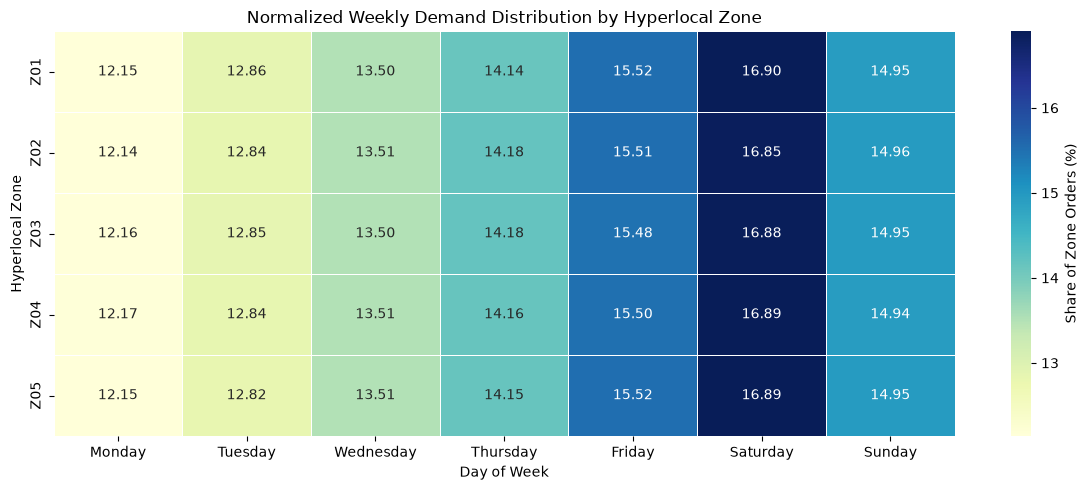

In [58]:
# ============================================================
# NORMALIZED ZONE × DAY-OF-WEEK HEATMAP
# ============================================================

plt.figure(figsize=(12, 5))

sns.heatmap(
    zone_day_percentage_matrix,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Share of Zone Orders (%)"}
)

plt.title("Normalized Weekly Demand Distribution by Hyperlocal Zone")
plt.xlabel("Day of Week")
plt.ylabel("Hyperlocal Zone")

plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# HIGHEST DAILY ORDER SHARE BY ZONE
# ============================================================

highest_share_day_by_zone = (
    zone_day_normalized.loc[
        zone_day_normalized
        .groupby("zone_id")["zone_day_percentage"]
        .idxmax()
    ]
    .sort_values("zone_id")
    .reset_index(drop=True)
)

highest_share_day_by_zone[
    ["zone_id", "day_of_week", "order_count", "zone_day_percentage"]
]

,zone_id,day_of_week,order_count,zone_day_percentage
0,Z01,Saturday,454640,16.90
1,Z02,Saturday,716385,16.85
2,Z03,Saturday,660073,16.88
3,Z04,Saturday,528209,16.89
4,Z05,Saturday,542217,16.89


In [60]:
# ============================================================
# LOWEST DAILY ORDER SHARE BY ZONE
# ============================================================

lowest_share_day_by_zone = (
    zone_day_normalized.loc[
        zone_day_normalized
        .groupby("zone_id")["zone_day_percentage"]
        .idxmin()
    ]
    .sort_values("zone_id")
    .reset_index(drop=True)
)

lowest_share_day_by_zone[
    ["zone_id", "day_of_week", "order_count", "zone_day_percentage"]
]

,zone_id,day_of_week,order_count,zone_day_percentage
0,Z01,Monday,326802,12.15
1,Z02,Monday,515958,12.14
2,Z03,Monday,475391,12.16
3,Z04,Monday,380766,12.17
4,Z05,Monday,389985,12.15


In [61]:
# ============================================================
# VALIDATE NORMALIZED PERCENTAGES
# ============================================================

zone_percentage_check = (
    zone_day_normalized
    .groupby("zone_id")["zone_day_percentage"]
    .sum()
    .reset_index(name="total_percentage")
)

zone_percentage_check

,zone_id,total_percentage
0,Z01,100.00
1,Z02,100.00
2,Z03,100.00
3,Z04,100.00
4,Z05,100.00


### Normalized Zone × Day-of-Week Analysis — Observations

- Saturday contributes the highest share of weekly transactions across
  all five hyperlocal zones, accounting for approximately 16.85%–16.90%
  of each zone's total orders.
- Monday contributes the lowest share, accounting for approximately
  12.14%–12.17% of each zone's total orders.
- The normalized weekly demand distributions are remarkably similar
  across the five zones.
- Although absolute order volumes differ substantially between zones,
  their relative day-of-week distributions remain consistent.
- Normalization separates overall zone demand magnitude from the
  distribution of transactions across the seven days.
- The percentage validation confirms that each zone's daily shares
  sum to 100%.
- These findings describe the synthetic dataset and should not be
  interpreted as verified real-world demand patterns.
- Zone and day-of-week features can be evaluated in subsequent
  forecasting experiments.

### 03.3.8 — Weekly Demand Trend Analysis

This section analyzes weekly food-order demand across the study period
from January 2023 to August 2026.

The analysis examines weekly order volume, average daily demand, and
variations in demand over time.

Partial weeks are identified to avoid misleading comparisons between
complete and incomplete calendar weeks.

In [68]:
# ============================================================
# 03.3.8.1 — WEEKLY DEMAND AGGREGATION
# ============================================================

weekly_demand_summary = (
    orders_df
    .assign(
        week_start=(
            orders_df["order_timestamp"]
            .dt.to_period("W-SUN")
            .dt.start_time
        )
    )
    .groupby("week_start")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean"),
        observed_days=(
            "order_timestamp",
            lambda x: x.dt.date.nunique()
        )
    )
    .reset_index()
)

weekly_demand_summary["average_daily_orders"] = (
    weekly_demand_summary["order_count"]
    / weekly_demand_summary["observed_days"]
)

print("Number of calendar weeks:", len(weekly_demand_summary))
print("First week:", weekly_demand_summary["week_start"].min())
print("Last week:", weekly_demand_summary["week_start"].max())

print("\nObserved days per week:")
print(weekly_demand_summary["observed_days"].value_counts().sort_index())

weekly_demand_summary.head()

Number of calendar weeks: 193
First week: 2022-12-26 00:00:00
Last week: 2026-08-31 00:00:00

Observed days per week:
observed_days
1      2
7    191
Name: count, dtype: int64


,week_start,order_count,total_order_value,average_order_value,observed_days,average_daily_orders
0,2022-12-26,12485,3976646.95,318.51,1,12485.00
1,2023-01-02,84502,26909561.16,318.45,7,12071.71
2,2023-01-09,84482,26933512.71,318.81,7,12068.86
3,2023-01-16,84527,26925829.48,318.55,7,12075.29
4,2023-01-23,84197,26845799.05,318.85,7,12028.14


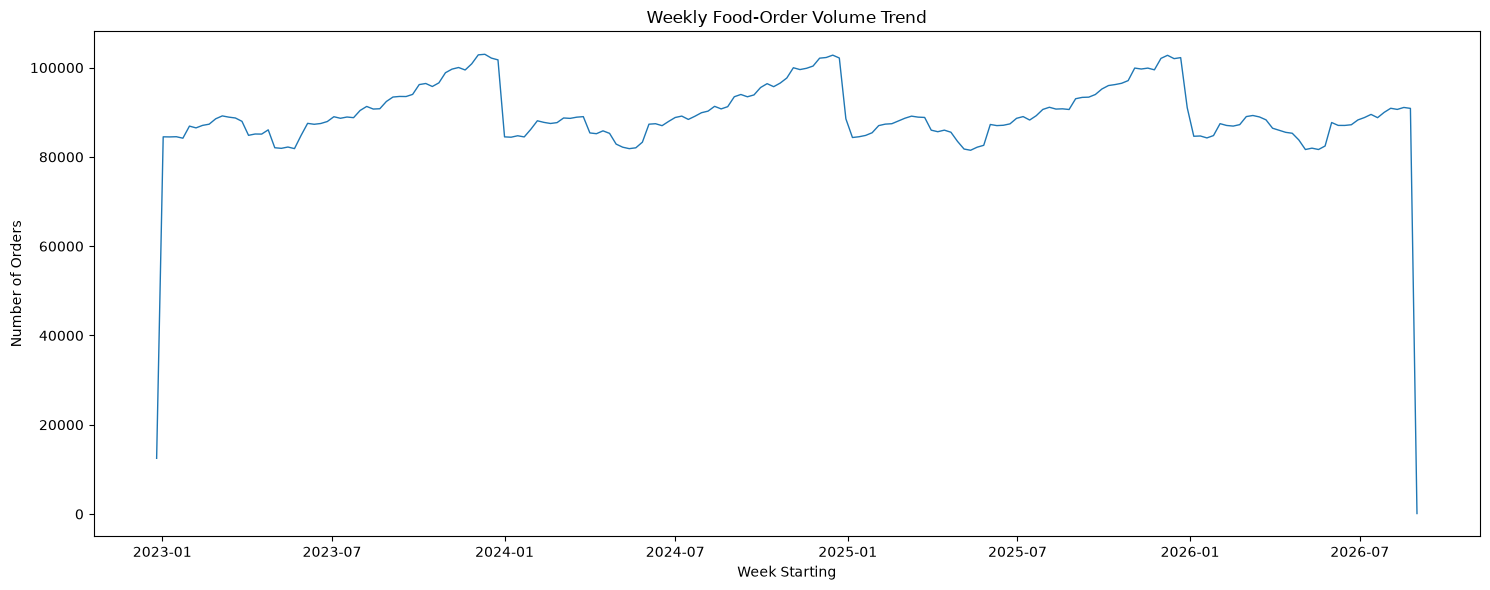

In [69]:
# ============================================================
# 03.3.8.2 — WEEKLY ORDER VOLUME TREND
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    weekly_demand_summary["week_start"],
    weekly_demand_summary["order_count"],
    linewidth=1
)

plt.title("Weekly Food-Order Volume Trend")
plt.xlabel("Week Starting")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

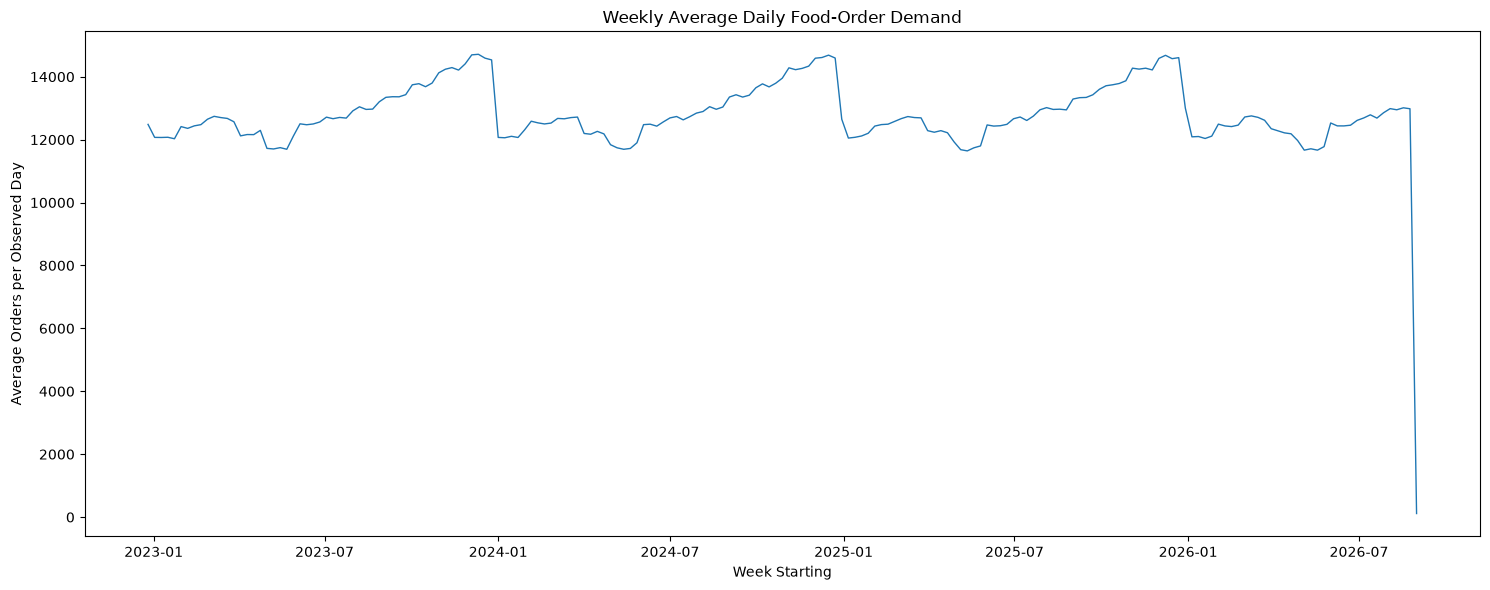

In [70]:
# ============================================================
# 03.3.8.3 — WEEKLY AVERAGE DAILY DEMAND
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    weekly_demand_summary["week_start"],
    weekly_demand_summary["average_daily_orders"],
    linewidth=1
)

plt.title("Weekly Average Daily Food-Order Demand")
plt.xlabel("Week Starting")
plt.ylabel("Average Orders per Observed Day")

plt.tight_layout()
plt.show()

In [71]:
# ============================================================
# 03.3.8.4 — COMPLETE-WEEK VALIDATION
# ============================================================

complete_weekly_demand = weekly_demand_summary.loc[
    weekly_demand_summary["observed_days"] == 7
].copy()

partial_weekly_demand = weekly_demand_summary.loc[
    weekly_demand_summary["observed_days"] < 7
].copy()

print("Total calendar weeks:", len(weekly_demand_summary))
print("Complete weeks:", len(complete_weekly_demand))
print("Partial weeks:", len(partial_weekly_demand))

print("\nPartial-week details:")

partial_weekly_demand[
    [
        "week_start",
        "order_count",
        "observed_days",
        "average_daily_orders"
    ]
]

Total calendar weeks: 193
Complete weeks: 191
Partial weeks: 2

Partial-week details:


,week_start,order_count,observed_days,average_daily_orders
0,2022-12-26,12485,1,12485.00
192,2026-08-31,114,1,114.00


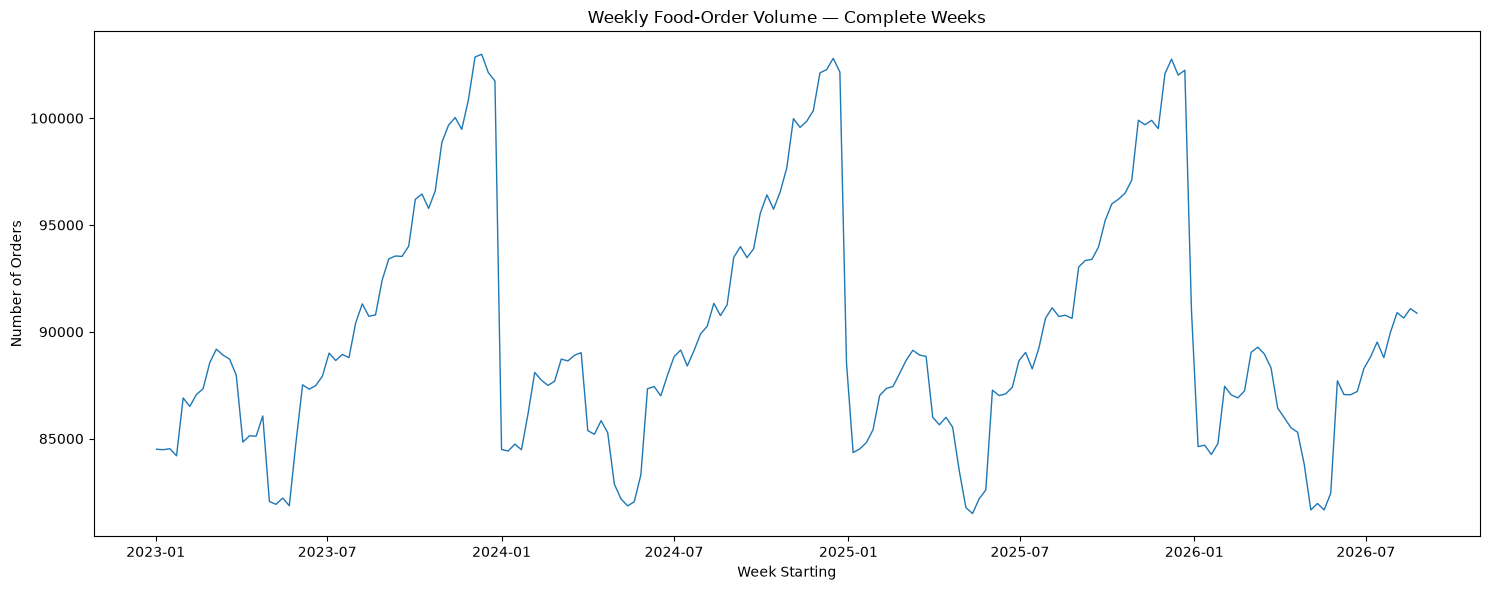

In [72]:
# ============================================================
# 03.3.8.5 — COMPLETE-WEEK ORDER VOLUME
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    complete_weekly_demand["week_start"],
    complete_weekly_demand["order_count"],
    linewidth=1
)

plt.title("Weekly Food-Order Volume — Complete Weeks")
plt.xlabel("Week Starting")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

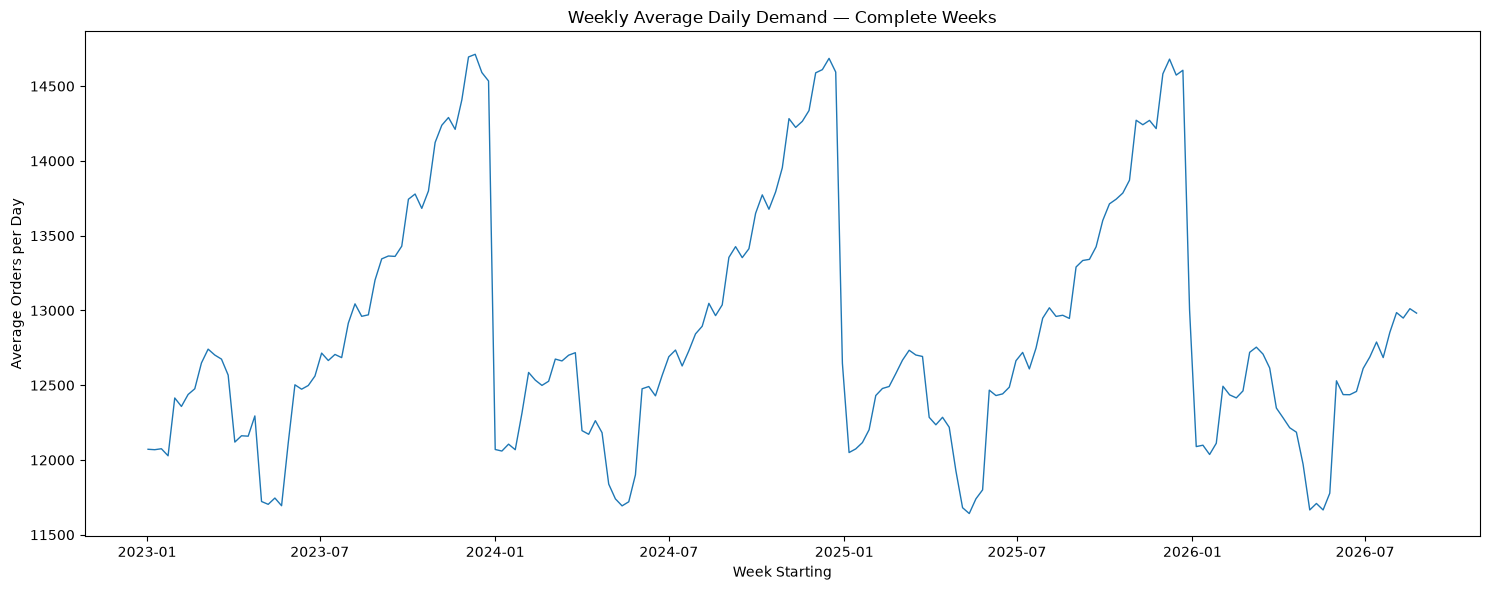

In [74]:
# ============================================================
# 03.3.8.6 — COMPLETE-WEEK AVERAGE DAILY DEMAND
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    complete_weekly_demand["week_start"],
    complete_weekly_demand["average_daily_orders"],
    linewidth=1
)

plt.title("Weekly Average Daily Demand — Complete Weeks")
plt.xlabel("Week Starting")
plt.ylabel("Average Orders per Day")

plt.tight_layout()
plt.show()

In [75]:
# ============================================================
# 03.3.8.7 — WEEKLY DEMAND STATISTICAL SUMMARY
# ============================================================

weekly_statistics = complete_weekly_demand[
    ["order_count", "average_daily_orders"]
].describe().T

weekly_statistics

,count,mean,std,min,25%,50%,75%,max
order_count,191.00,89928.58,5651.64,81494.00,85988.00,88673.00,93403.50,102991.00
average_daily_orders,191.00,12846.94,807.38,11642.00,12284.00,12667.57,13343.36,14713.00


In [76]:
# ============================================================
# VERIFY PROJECT DATE RANGE
# ============================================================

# 1. Check overall timestamp range
print("Minimum timestamp:", orders_df["order_timestamp"].min())
print("Maximum timestamp:", orders_df["order_timestamp"].max())

# 2. Count transactions before the project start date
before_start = orders_df[
    orders_df["order_timestamp"] < pd.Timestamp("2023-01-01")
]

print("\nOrders before 2023-01-01:", len(before_start))

# 3. Count transactions on the first project date
first_day = orders_df[
    orders_df["order_timestamp"].dt.date
    == pd.Timestamp("2023-01-01").date()
]

print("Orders on 2023-01-01:", len(first_day))

# 4. Display any unexpected early transactions
if len(before_start) > 0:
    print("\nUnexpected early transactions:")
    display(
        before_start[
            ["order_id", "order_timestamp", "zone_id"]
        ].head(10)
    )
else:
    print("\nPASS: No transactions exist before 2023-01-01.")

Minimum timestamp: 2023-01-01 00:00:26
Maximum timestamp: 2026-08-31 00:59:23

Orders before 2023-01-01: 0
Orders on 2023-01-01: 12485

PASS: No transactions exist before 2023-01-01.


### 03.3.8 — Weekly Demand Trend Analysis

#### Objective
Analyze weekly food-order demand throughout the study period (January 2023–August 2026) to identify recurring patterns, fluctuations, and long-term changes in the synthetic dataset.

#### Analysis Performed
- Aggregated transactions by calendar week.
- Calculated weekly order volume and total order value.
- Calculated average daily orders for each week.
- Identified complete weeks and partial weeks.
- Visualized weekly order volume and average daily demand.
- Examined demand trends using complete weeks to avoid misleading comparisons caused by incomplete periods.
- Generated descriptive statistics for weekly demand.

#### Key Findings
- The weekly dataset contains 193 calendar-week periods.
- 191 weeks contain all seven days of observations.
- Two weeks are partial: the first and last calendar weeks.
- Weekly order volume shows recurring fluctuations throughout the study period.
- The complete-week analysis shows repeated increases and decreases in demand rather than a perfectly linear trend.
- The final partial week contains only one observed day and must not be compared directly with complete weeks.

#### Research Interpretation
The weekly analysis highlights recurring demand fluctuations in the synthetic food-order dataset. Weekly aggregation provides a broader view of demand variation and complements the hourly, daily, and zone-level analyses.

Complete weeks are used for interpreting weekly demand patterns because partial weeks contain fewer observed days and can distort comparisons.

#### Conclusion
Weekly demand analysis is complete. The results provide a foundation for investigating monthly demand patterns and seasonal variation in the next section.



### 03.3.9 — Monthly Demand Trend Analysis

#### Objective
Analyze monthly food-order demand from January 2023 to August 2026 to identify monthly variations, recurring patterns, and potential seasonal trends in the synthetic dataset.

#### Analysis Plan
- Aggregate transactions by calendar month.
- Calculate monthly order volume and total order value.
- Calculate average daily orders for each month.
- Compare demand across months and years.
- Visualize monthly order volume and average daily demand.
- Identify the highest- and lowest-demand months.
- Account for incomplete months when interpreting the results.

#### Research Purpose
Monthly analysis provides a broader view of demand variation than hourly, daily, and weekly analysis. It will help identify patterns that can later be investigated during forecasting and model evaluation.

#### Important Consideration
The dataset contains synthetic food-order transactions. Any seasonal patterns observed are properties of the synthetic data and should not be interpreted as verified real-world food-delivery trends.



In [77]:
# ============================================================
# 03.3.9.1 — MONTHLY DEMAND AGGREGATION
# ============================================================

# Create a monthly period column
orders_df["order_month"] = (
    orders_df["order_timestamp"].dt.to_period("M")
)

# Aggregate transactions by month
monthly_demand_summary = (
    orders_df
    .groupby("order_month")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean"),
        observed_days=(
            "order_timestamp",
            lambda x: x.dt.date.nunique()
        )
    )
    .reset_index()
)

# Calculate average daily orders
monthly_demand_summary["average_daily_orders"] = (
    monthly_demand_summary["order_count"]
    / monthly_demand_summary["observed_days"]
)

# Display the first and last months
print("Total calendar months:", len(monthly_demand_summary))

print("\nFirst five months:")
display(monthly_demand_summary.head())

print("\nLast five months:")
display(monthly_demand_summary.tail())

Total calendar months: 44

First five months:


,order_month,order_count,total_order_value,average_order_value,observed_days,average_daily_orders
0,2023-01,371638,118436451.22,318.69,31,11988.32
1,2023-02,348204,110951850.65,318.64,28,12435.86
2,2023-03,394219,125606438.19,318.62,31,12716.74
3,2023-04,368434,117361703.99,318.54,30,12281.13
4,2023-05,359591,114500891.46,318.42,31,11599.71



Last five months:


,order_month,order_count,total_order_value,average_order_value,observed_days,average_daily_orders
39,2026-04,366039,116671771.86,318.74,30,12201.30
40,2026-05,366321,116663344.70,318.47,31,11816.81
41,2026-06,371022,118308975.25,318.87,30,12367.40
42,2026-07,394470,125779526.84,318.86,31,12724.84
43,2026-08,392562,125139077.87,318.78,31,12663.29


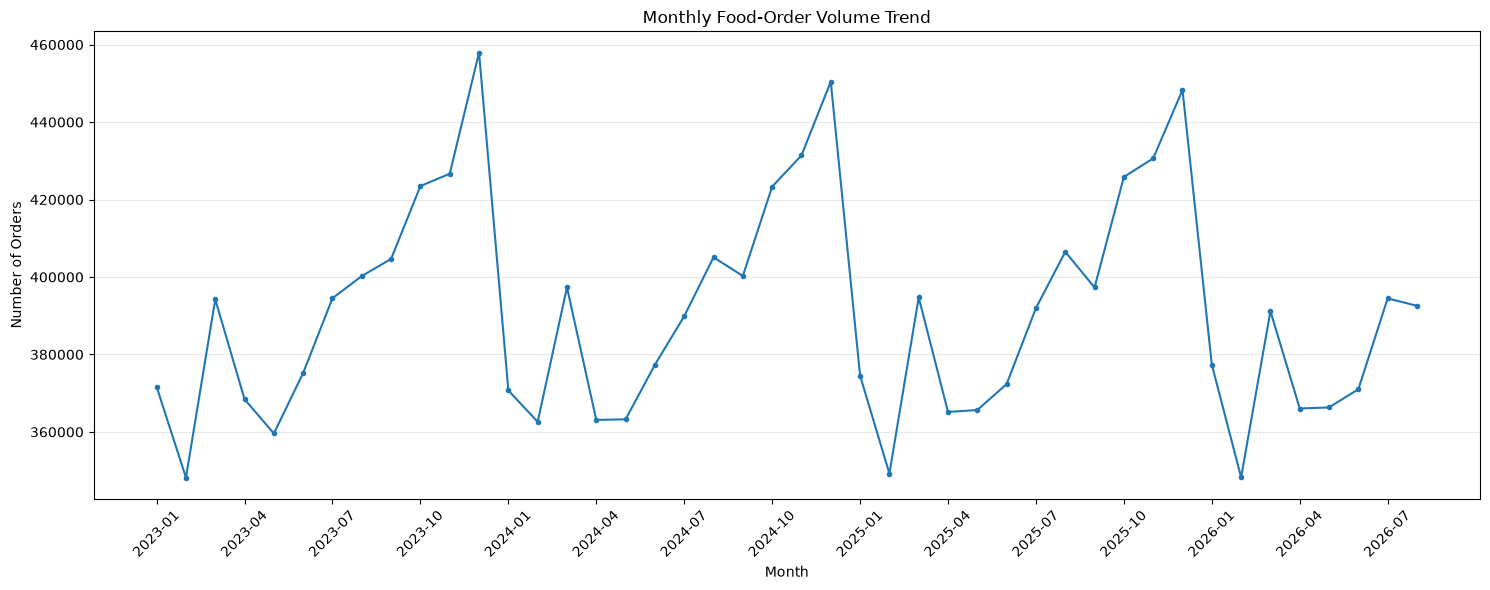

In [78]:
# ============================================================
# 03.3.9.2 — MONTHLY ORDER VOLUME TREND
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_demand_summary["order_month"].astype(str),
    monthly_demand_summary["order_count"],
    marker="o",
    markersize=3,
    linewidth=1.5
)

plt.title("Monthly Food-Order Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

# Display selected month labels for readability
plt.xticks(
    ticks=range(0, len(monthly_demand_summary), 3),
    labels=monthly_demand_summary["order_month"]
        .astype(str)
        .iloc[::3],
    rotation=45
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

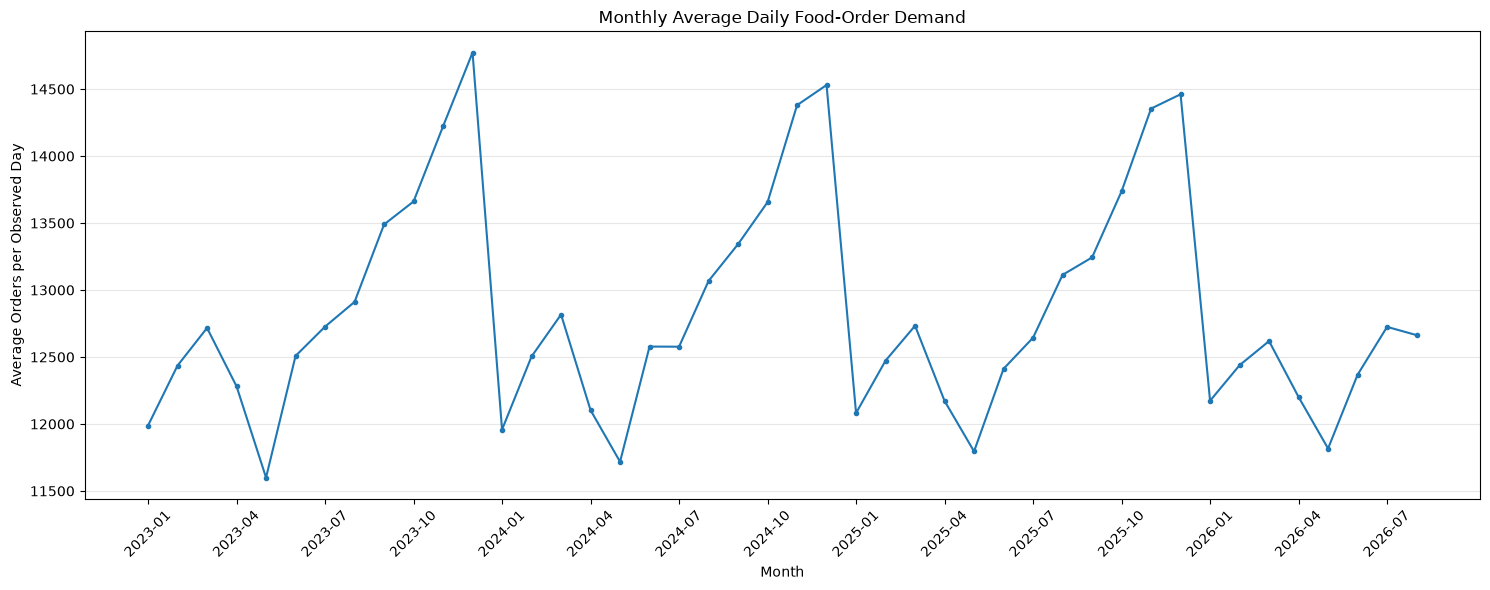

In [79]:
# ============================================================
# 03.3.9.3 — MONTHLY AVERAGE DAILY DEMAND
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_demand_summary["order_month"].astype(str),
    monthly_demand_summary["average_daily_orders"],
    marker="o",
    markersize=3,
    linewidth=1.5
)

plt.title("Monthly Average Daily Food-Order Demand")
plt.xlabel("Month")
plt.ylabel("Average Orders per Observed Day")

plt.xticks(
    ticks=range(0, len(monthly_demand_summary), 3),
    labels=monthly_demand_summary["order_month"]
        .astype(str)
        .iloc[::3],
    rotation=45
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:
# ============================================================
# 03.3.9.4 — MONTHLY DEMAND STATISTICAL SUMMARY
# ============================================================

# Display descriptive statistics
monthly_statistics = monthly_demand_summary[
    ["order_count", "average_daily_orders", "average_order_value"]
].describe()

print("MONTHLY DEMAND STATISTICAL SUMMARY")
display(monthly_statistics)

# Identify the highest-demand month
highest_demand_month = monthly_demand_summary.loc[
    monthly_demand_summary["average_daily_orders"].idxmax()
]

# Identify the lowest-demand month
lowest_demand_month = monthly_demand_summary.loc[
    monthly_demand_summary["average_daily_orders"].idxmin()
]

print("\nHIGHEST AVERAGE DAILY DEMAND MONTH")
print("Month:", highest_demand_month["order_month"])
print(
    "Average daily orders:",
    round(highest_demand_month["average_daily_orders"], 2)
)

print("\nLOWEST AVERAGE DAILY DEMAND MONTH")
print("Month:", lowest_demand_month["order_month"])
print(
    "Average daily orders:",
    round(lowest_demand_month["average_daily_orders"], 2)
)

MONTHLY DEMAND STATISTICAL SUMMARY


,order_count,average_daily_orders,average_order_value
count,44.00,44.00,44.00
mean,390658.11,12835.53,318.65
std,28213.15,827.83,0.13
min,348204.00,11599.71,318.38
25%,367905.75,12261.17,318.54
50%,391571.00,12631.32,318.68
75%,404778.25,13267.98,318.75
max,457943.00,14772.35,318.89



HIGHEST AVERAGE DAILY DEMAND MONTH
Month: 2023-12
Average daily orders: 14772.35

LOWEST AVERAGE DAILY DEMAND MONTH
Month: 2023-05
Average daily orders: 11599.71


In [81]:
# ============================================================
# 03.3.9.5 — MONTHLY DEMAND BY CALENDAR YEAR
# ============================================================

# Extract calendar year and month
monthly_demand_summary["year"] = (
    monthly_demand_summary["order_month"].dt.year
)

monthly_demand_summary["month_number"] = (
    monthly_demand_summary["order_month"].dt.month
)

# Create a year-by-month matrix
monthly_year_matrix = monthly_demand_summary.pivot(
    index="month_number",
    columns="year",
    values="average_daily_orders"
)

# Display monthly average daily demand by year
display(monthly_year_matrix.round(2))

year,2023,2024,2025,2026
month_number,,,,
1,11988.32,11958.00,12081.58,12173.35
2,12435.86,12503.72,12472.79,12438.36
3,12716.74,12816.71,12733.19,12618.65
4,12281.13,12103.13,12172.17,12201.30
5,11599.71,11717.90,11795.13,11816.81
6,12507.73,12577.90,12411.93,12367.40
7,12726.58,12576.71,12644.00,12724.84
8,12911.06,13067.45,13112.87,12663.29
9,13489.13,13342.13,13243.27,NaN


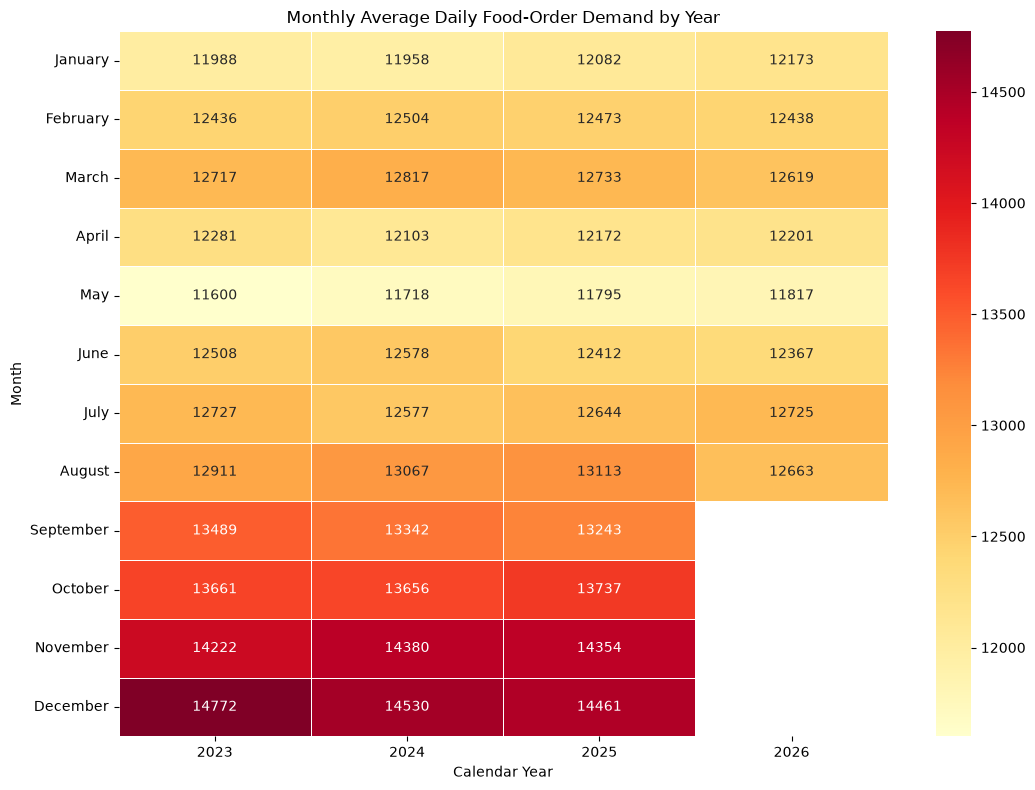

In [83]:
# ============================================================
# 03.3.9.6 — MONTHLY DEMAND DISTRIBUTION HEATMAP
# ============================================================

month_names = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_heatmap_data = monthly_year_matrix.copy()

monthly_heatmap_data.index = [
    month_names[int(month) - 1]
    for month in monthly_heatmap_data.index
]

plt.figure(figsize=(11, 8))

sns.heatmap(
    monthly_heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Monthly Average Daily Food-Order Demand by Year")
plt.xlabel("Calendar Year")
plt.ylabel("Month")

plt.tight_layout()
plt.show()

In [84]:
# ============================================================
# 03.3.9.7 — MONTHLY DEMAND STATISTICAL INSIGHTS
# ============================================================

# 1. Identify the highest-demand month
highest_demand_month = monthly_demand_summary.loc[
    monthly_demand_summary["average_daily_orders"].idxmax()
]

# 2. Identify the lowest-demand month
lowest_demand_month = monthly_demand_summary.loc[
    monthly_demand_summary["average_daily_orders"].idxmin()
]

# 3. Calculate the difference in average daily orders
demand_difference = (
    highest_demand_month["average_daily_orders"]
    - lowest_demand_month["average_daily_orders"]
)

# 4. Calculate percentage difference relative to the lowest-demand month
percentage_difference = (
    demand_difference
    / lowest_demand_month["average_daily_orders"]
) * 100

# 5. Display the results
print("=" * 55)
print("MONTHLY FOOD-ORDER DEMAND INSIGHTS")
print("=" * 55)

print("\nHighest-Demand Month")
print("--------------------")
print("Month:", highest_demand_month["order_month"])
print(
    "Average Daily Orders:",
    round(highest_demand_month["average_daily_orders"], 2)
)

print("\nLowest-Demand Month")
print("-------------------")
print("Month:", lowest_demand_month["order_month"])
print(
    "Average Daily Orders:",
    round(lowest_demand_month["average_daily_orders"], 2)
)

print("\nDemand Difference")
print("-----------------")
print("Difference in Average Daily Orders:", round(demand_difference, 2))
print("Percentage Difference:", round(percentage_difference, 2), "%")

MONTHLY FOOD-ORDER DEMAND INSIGHTS

Highest-Demand Month
--------------------
Month: 2023-12
Average Daily Orders: 14772.35

Lowest-Demand Month
-------------------
Month: 2023-05
Average Daily Orders: 11599.71

Demand Difference
-----------------
Difference in Average Daily Orders: 3172.65
Percentage Difference: 27.35 %


### 03.3.9 — Monthly Demand Trend Analysis

#### Objective
Analyze monthly food-order demand from January 2023 to August 2026 to identify monthly variations, recurring seasonal patterns, and changes in average daily demand.

#### Analysis Tasks
1. Aggregate monthly order counts and total order values.
2. Calculate average daily order demand for each month.
3. Visualize monthly food-order volume trends.
4. Compare average daily demand across months.
5. Compare monthly demand patterns across calendar years.
6. Identify the highest- and lowest-demand months.
7. Calculate monthly demand statistics and quantify demand variation.

#### Expected Outcome
Understand monthly demand patterns and identify potential seasonal characteristics that may be useful for feature engineering and time-series forecasting.

#### Important Consideration
The dataset contains a partial month at the end of the study period (August 2026). Monthly comparisons should account for the number of observed days in each month. Average daily demand is used alongside monthly order totals to support fairer comparisons.

### 03.3.10 — Zone-Level Monthly Demand Analysis

#### Objective
Analyze monthly food-order demand across the five hyperlocal zones to identify zone-specific demand patterns and seasonal variations.

#### Analysis Tasks
1. Aggregate monthly order counts by hyperlocal zone.
2. Compare monthly order volumes across zones.
3. Calculate average daily demand for each zone and month.
4. Visualize zone-level monthly demand using a heatmap.
5. Identify the highest- and lowest-demand months for each zone.

#### Expected Outcome
Understand how monthly demand patterns vary across hyperlocal zones and identify zone-specific characteristics relevant to subsequent forecasting experiments.

In [85]:
# ============================================================
# 03.3.10.1 — MONTHLY DEMAND AGGREGATION BY ZONE
# ============================================================

# Ensure timestamps are in datetime format
orders_df["order_timestamp"] = pd.to_datetime(
    orders_df["order_timestamp"]
)

# Create year-month and calendar date columns
orders_df["order_month"] = (
    orders_df["order_timestamp"].dt.to_period("M").astype(str)
)

orders_df["order_date"] = (
    orders_df["order_timestamp"].dt.date
)

# Aggregate monthly demand by zone
zone_monthly_demand = (
    orders_df
    .groupby(["zone_id", "order_month"], as_index=False)
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean"),
        observed_days=("order_date", "nunique")
    )
)

# Calculate average daily orders for each zone-month
zone_monthly_demand["average_daily_orders"] = (
    zone_monthly_demand["order_count"]
    / zone_monthly_demand["observed_days"]
)

# Sort chronologically within each zone
zone_monthly_demand = zone_monthly_demand.sort_values(
    ["zone_id", "order_month"]
).reset_index(drop=True)

# Display results
print("ZONE-LEVEL MONTHLY DEMAND SUMMARY")
print("=" * 60)

print("Number of records:", len(zone_monthly_demand))
print("Number of zones:", zone_monthly_demand["zone_id"].nunique())
print("Number of months:", zone_monthly_demand["order_month"].nunique())

print("\nFirst 10 records:")
display(zone_monthly_demand.head(10))

print("\nLast 10 records:")
display(zone_monthly_demand.tail(10))

ZONE-LEVEL MONTHLY DEMAND SUMMARY
Number of records: 220
Number of zones: 5
Number of months: 44

First 10 records:


,zone_id,order_month,order_count,total_order_value,average_order_value,observed_days,average_daily_orders
0,Z01,2023-01,58307,18173666.53,311.69,31,1880.87
1,Z01,2023-02,54461,16972862.49,311.65,28,1945.04
2,Z01,2023-03,61642,19202761.31,311.52,31,1988.45
3,Z01,2023-04,57599,17953216.79,311.69,30,1919.97
4,Z01,2023-05,56418,17630174.64,312.49,31,1819.94
5,Z01,2023-06,58785,18319221.99,311.63,30,1959.50
6,Z01,2023-07,61998,19344648.23,312.02,31,1999.94
7,Z01,2023-08,62772,19588075.79,312.05,31,2024.90
8,Z01,2023-09,62968,19665062.63,312.30,30,2098.93
9,Z01,2023-10,66211,20653425.17,311.93,31,2135.84



Last 10 records:


,zone_id,order_month,order_count,total_order_value,average_order_value,observed_days,average_daily_orders
210,Z05,2025-11,80172,26521559.29,330.81,30,2672.40
211,Z05,2025-12,83578,27636272.13,330.66,31,2696.06
212,Z05,2026-01,70250,23248914.51,330.95,31,2266.13
213,Z05,2026-02,64931,21456606.82,330.45,28,2318.96
214,Z05,2026-03,72899,24107663.96,330.70,31,2351.58
215,Z05,2026-04,68215,22561995.36,330.75,30,2273.83
216,Z05,2026-05,68302,22588195.09,330.71,31,2203.29
217,Z05,2026-06,69518,23003454.97,330.90,30,2317.27
218,Z05,2026-07,73797,24414061.23,330.83,31,2380.55
219,Z05,2026-08,73420,24305194.51,331.04,31,2368.39


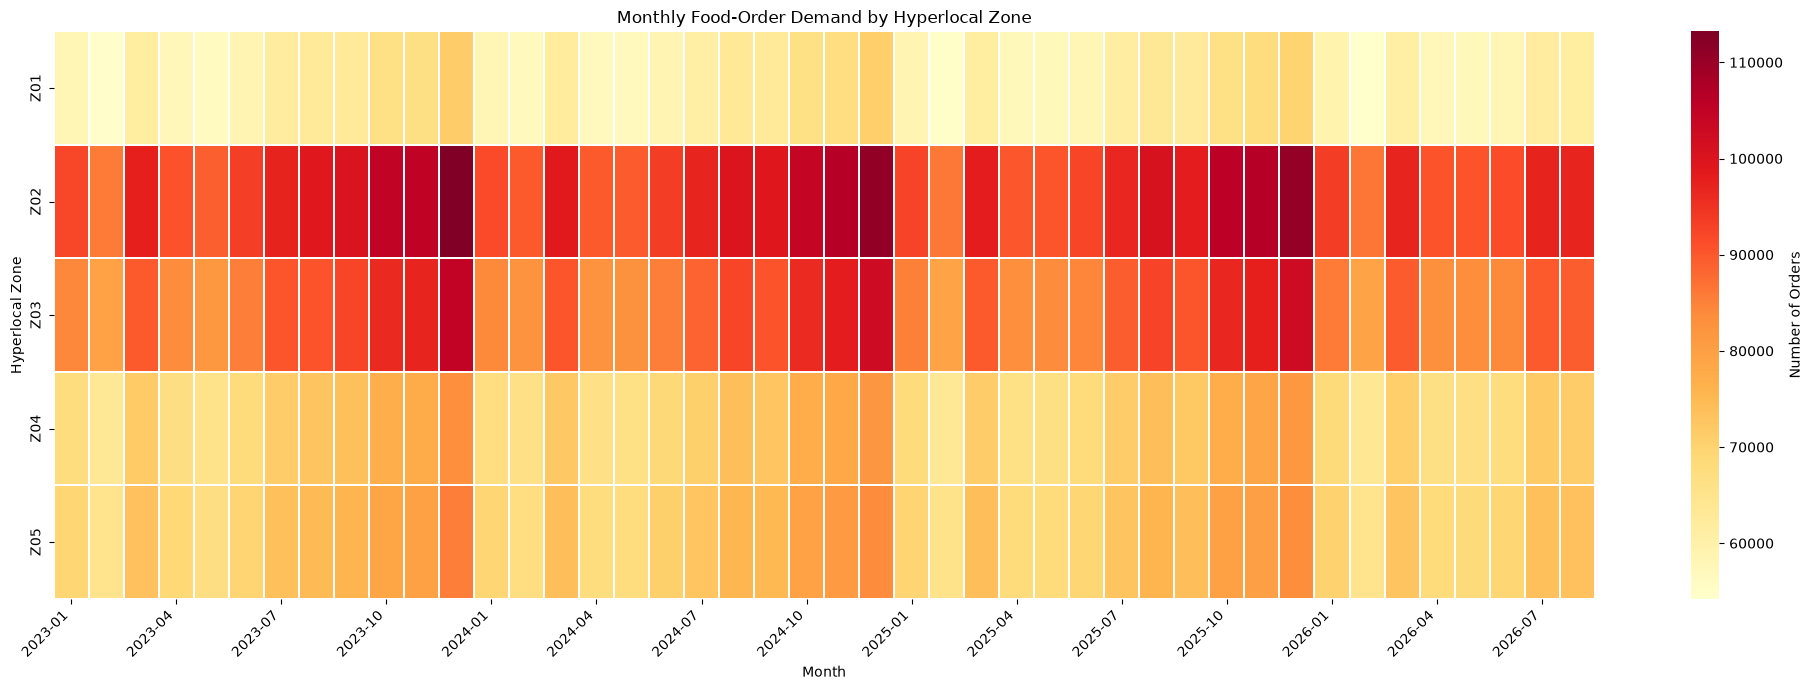

In [86]:
# ============================================================
# 03.3.10.2 — MONTHLY DEMAND HEATMAP BY ZONE
# ============================================================

# Create a zone-by-month demand matrix
zone_monthly_matrix = zone_monthly_demand.pivot(
    index="zone_id",
    columns="order_month",
    values="order_count"
)

# Arrange months chronologically
zone_monthly_matrix = zone_monthly_matrix.sort_index(axis=1)

# Plot the heatmap
plt.figure(figsize=(20, 7))

sns.heatmap(
    zone_monthly_matrix,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Number of Orders"}
)

plt.title("Monthly Food-Order Demand by Hyperlocal Zone")
plt.xlabel("Month")
plt.ylabel("Hyperlocal Zone")

# Display selected month labels for readability
month_labels = zone_monthly_matrix.columns.tolist()

tick_positions = list(range(0, len(month_labels), 3))

plt.xticks(
    ticks=[position + 0.5 for position in tick_positions],
    labels=[month_labels[position] for position in tick_positions],
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

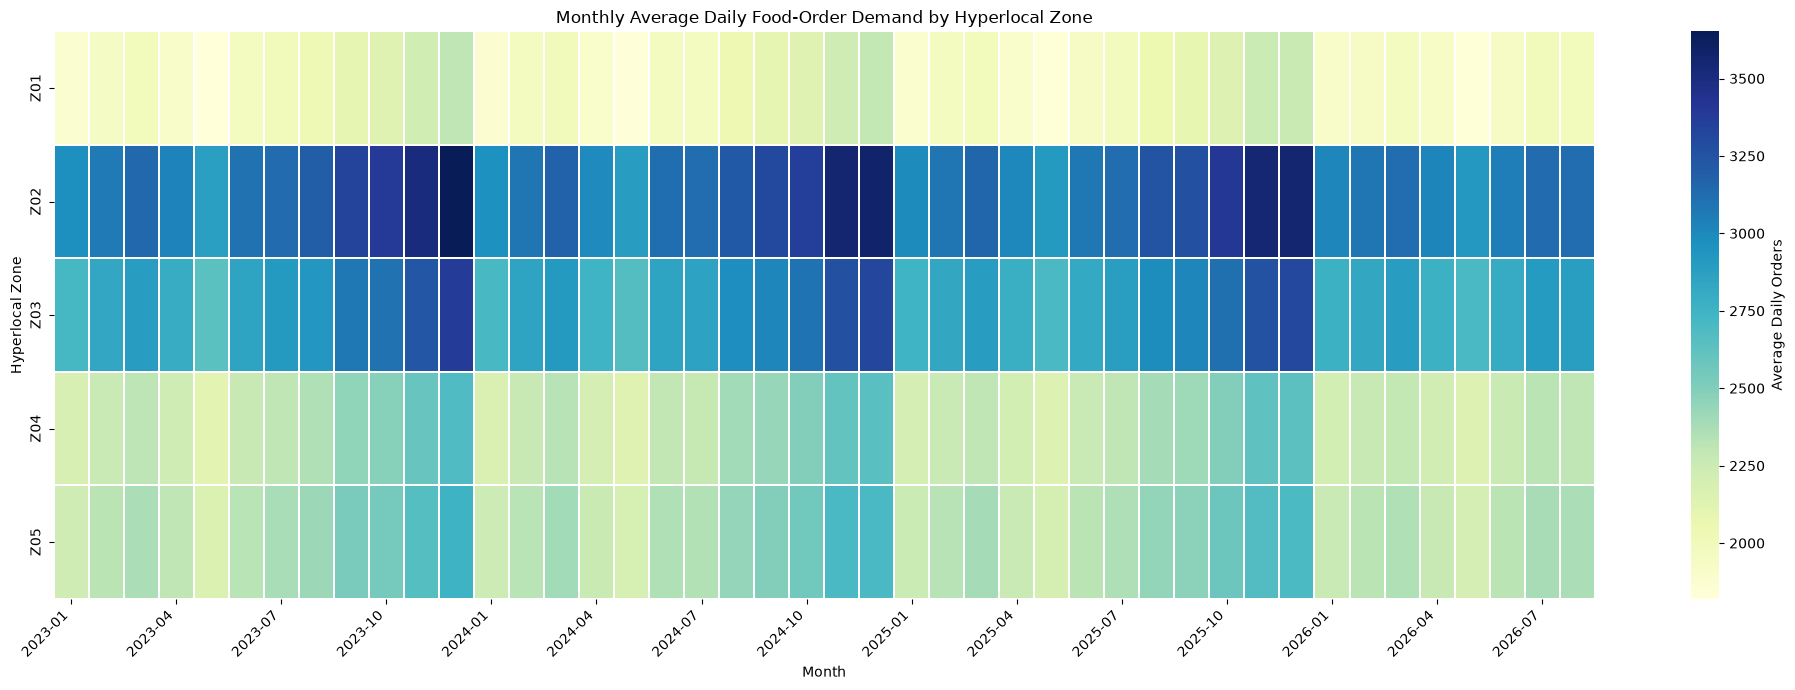

In [87]:
# ============================================================
# 03.3.10.3 — MONTHLY AVERAGE DAILY DEMAND HEATMAP BY ZONE
# ============================================================

# Create a zone-by-month matrix using average daily orders
zone_monthly_daily_matrix = zone_monthly_demand.pivot(
    index="zone_id",
    columns="order_month",
    values="average_daily_orders"
)

# Arrange months chronologically
zone_monthly_daily_matrix = zone_monthly_daily_matrix.sort_index(axis=1)

# Plot the heatmap
plt.figure(figsize=(20, 7))

sns.heatmap(
    zone_monthly_daily_matrix,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Average Daily Orders"}
)

plt.title("Monthly Average Daily Food-Order Demand by Hyperlocal Zone")
plt.xlabel("Month")
plt.ylabel("Hyperlocal Zone")

# Display selected month labels
month_labels = zone_monthly_daily_matrix.columns.tolist()
tick_positions = list(range(0, len(month_labels), 3))

plt.xticks(
    ticks=[position + 0.5 for position in tick_positions],
    labels=[month_labels[position] for position in tick_positions],
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [88]:
# ============================================================
# 03.3.10.4 — MONTHLY DEMAND STATISTICS BY ZONE
# ============================================================

zone_monthly_statistics = (
    zone_monthly_demand
    .groupby("zone_id")
    .agg(
        number_of_months=("order_month", "nunique"),
        average_monthly_orders=("order_count", "mean"),
        average_daily_demand=("average_daily_orders", "mean"),
        median_daily_demand=("average_daily_orders", "median"),
        minimum_daily_demand=("average_daily_orders", "min"),
        maximum_daily_demand=("average_daily_orders", "max"),
        demand_std=("average_daily_orders", "std")
    )
    .reset_index()
)

# Round numerical results for readability
numeric_columns = zone_monthly_statistics.select_dtypes(
    include="number"
).columns

zone_monthly_statistics[numeric_columns] = (
    zone_monthly_statistics[numeric_columns].round(2)
)

print("=" * 75)
print("MONTHLY DEMAND STATISTICS BY HYPERLOCAL ZONE")
print("=" * 75)

display(zone_monthly_statistics)

MONTHLY DEMAND STATISTICS BY HYPERLOCAL ZONE


,zone_id,number_of_months,average_monthly_orders,average_daily_demand,median_daily_demand,minimum_daily_demand,maximum_daily_demand,demand_std
0,Z01,44,61140.45,2008.85,1974.94,1819.94,2300.71,128.72
1,Z02,44,96599.77,3173.90,3124.61,2873.74,3652.32,203.40
2,Z03,44,88887.14,2920.43,2880.89,2638.26,3377.94,189.30
3,Z04,44,71086.36,2335.68,2297.15,2106.71,2685.90,151.80
4,Z05,44,72944.39,2396.67,2355.58,2161.06,2755.48,155.50


In [89]:
# ============================================================
# 03.3.10.5 — HIGHEST- AND LOWEST-DEMAND MONTHS BY ZONE
# ============================================================

# Highest-demand month for each zone
highest_month_by_zone = (
    zone_monthly_demand.loc[
        zone_monthly_demand.groupby("zone_id")[
            "average_daily_orders"
        ].idxmax()
    ]
    .sort_values("zone_id")
    .reset_index(drop=True)
)

# Lowest-demand month for each zone
lowest_month_by_zone = (
    zone_monthly_demand.loc[
        zone_monthly_demand.groupby("zone_id")[
            "average_daily_orders"
        ].idxmin()
    ]
    .sort_values("zone_id")
    .reset_index(drop=True)
)

# Display highest-demand months
print("=" * 75)
print("HIGHEST-DEMAND MONTH BY ZONE")
print("=" * 75)

display(
    highest_month_by_zone[
        ["zone_id", "order_month", "average_daily_orders", "order_count"]
    ].round(2)
)

# Display lowest-demand months
print("\n" + "=" * 75)
print("LOWEST-DEMAND MONTH BY ZONE")
print("=" * 75)

display(
    lowest_month_by_zone[
        ["zone_id", "order_month", "average_daily_orders", "order_count"]
    ].round(2)
)

HIGHEST-DEMAND MONTH BY ZONE


,zone_id,order_month,average_daily_orders,order_count
0,Z01,2023-12,2300.71,71322
1,Z02,2023-12,3652.32,113222
2,Z03,2023-12,3377.94,104716
3,Z04,2023-12,2685.90,83263
4,Z05,2023-12,2755.48,85420



LOWEST-DEMAND MONTH BY ZONE


,zone_id,order_month,average_daily_orders,order_count
0,Z01,2023-05,1819.94,56418
1,Z02,2023-05,2873.74,89086
2,Z03,2023-05,2638.26,81786
3,Z04,2023-05,2106.71,65308
4,Z05,2023-05,2161.06,66993


In [90]:
# ============================================================
# 03.3.10.6 — MONTHLY DEMAND VARIATION BY ZONE
# ============================================================

# Calculate highest and lowest average daily demand
zone_demand_variation = (
    zone_monthly_demand
    .groupby("zone_id")
    .agg(
        highest_daily_demand=("average_daily_orders", "max"),
        lowest_daily_demand=("average_daily_orders", "min"),
        average_daily_demand=("average_daily_orders", "mean"),
        demand_std=("average_daily_orders", "std")
    )
    .reset_index()
)

# Calculate absolute and percentage variation
zone_demand_variation["demand_range"] = (
    zone_demand_variation["highest_daily_demand"]
    - zone_demand_variation["lowest_daily_demand"]
)

zone_demand_variation["variation_percentage"] = (
    zone_demand_variation["demand_range"]
    / zone_demand_variation["average_daily_demand"]
    * 100
)

# Display results
print("=" * 85)
print("MONTHLY DEMAND VARIATION BY HYPERLOCAL ZONE")
print("=" * 85)

display(zone_demand_variation.round(2))

MONTHLY DEMAND VARIATION BY HYPERLOCAL ZONE


,zone_id,highest_daily_demand,lowest_daily_demand,average_daily_demand,demand_std,demand_range,variation_percentage
0,Z01,2300.71,1819.94,2008.85,128.72,480.77,23.93
1,Z02,3652.32,2873.74,3173.90,203.40,778.58,24.53
2,Z03,3377.94,2638.26,2920.43,189.30,739.68,25.33
3,Z04,2685.90,2106.71,2335.68,151.80,579.19,24.80
4,Z05,2755.48,2161.06,2396.67,155.50,594.42,24.80


### 03.3.10.6 — Monthly Demand Variation by Zone

#### Objective
To compare monthly demand fluctuations across the five synthetic hyperlocal zones using absolute demand ranges and relative percentage variation.

#### Methodology
- Identified the highest and lowest monthly average daily demand for each zone.
- Calculated the absolute demand range by subtracting the minimum from the maximum.
- Calculated relative variation as a percentage of the zone's average daily demand.
- Compared demand variability across zones.

#### Key Findings
- **Hitech City (Z02)** recorded the largest absolute demand range of approximately 778.58 orders per day.
- **Gachibowli (Z03)** recorded the highest relative variation at 25.33%.
- **Kondapur (Z01)** recorded the smallest absolute demand range of approximately 480.77 orders per day.
- Relative variation ranged from 23.93% to 25.33% across the five zones.

#### Research Significance
The results demonstrate the importance of zone-specific demand analysis and provide a basis for evaluating forecasting performance across zones with different demand levels and variability.

**Note:** These findings describe the synthetic dataset and are not evidence of actual demand patterns in Hyderabad.

### 03.3.11 — Demand Distribution Analysis

#### Objective
To examine the distribution of food-order demand and understand the variability in daily order volumes throughout the study period.

#### Analysis Components
- Daily demand distribution and descriptive statistics.
- Comparison of mean and median daily demand.
- Identification of potential extreme-demand observations.
- Visualization of demand distribution using histograms and boxplots.

#### Research Significance
Understanding demand distribution helps identify variability and potential extreme observations before developing forecasting models. These findings will support subsequent model evaluation and surge-intelligence analysis.

In [91]:
# ============================================================
# 03.3.11.1 — DAILY DEMAND DISTRIBUTION
# ============================================================

# Aggregate transaction-level data into daily order counts
daily_demand = (
    orders_df
    .assign(
        order_date=orders_df["order_timestamp"].dt.normalize()
    )
    .groupby("order_date")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

# Display dataset information
print("=" * 70)
print("DAILY FOOD-ORDER DEMAND SUMMARY")
print("=" * 70)

print("Number of observed days:", len(daily_demand))
print("First observed date:", daily_demand["order_date"].min())
print("Last observed date:", daily_demand["order_date"].max())

print("\nFirst five records:")
display(daily_demand.head())

print("\nLast five records:")
display(daily_demand.tail())

DAILY FOOD-ORDER DEMAND SUMMARY
Number of observed days: 1339
First observed date: 2023-01-01 00:00:00
Last observed date: 2026-08-31 00:00:00

First five records:


,order_date,order_count,total_order_value,average_order_value
0,2023-01-01,12485,3976646.95,318.51
1,2023-01-02,10255,3242477.77,316.19
2,2023-01-03,10942,3481270.88,318.16
3,2023-01-04,11393,3636232.52,319.16
4,2023-01-05,11919,3792880.50,318.22



Last five records:


,order_date,order_count,total_order_value,average_order_value
1334,2026-08-27,12937,4119869.13,318.46
1335,2026-08-28,14151,4511700.18,318.83
1336,2026-08-29,15385,4902659.68,318.66
1337,2026-08-30,13401,4270137.56,318.64
1338,2026-08-31,114,36494.92,320.13


In [92]:
# ============================================================
# DAILY DEMAND DESCRIPTIVE STATISTICS
# ============================================================

daily_demand_statistics = (
    daily_demand["order_count"]
    .describe()
    .to_frame(name="daily_order_count")
)

print("DAILY DEMAND STATISTICAL SUMMARY")

display(daily_demand_statistics.round(2))

# Compare mean and median
mean_daily_demand = daily_demand["order_count"].mean()
median_daily_demand = daily_demand["order_count"].median()

print(f"\nMean daily orders: {mean_daily_demand:,.2f}")
print(f"Median daily orders: {median_daily_demand:,.2f}")

print(
    "Mean - Median:",
    round(mean_daily_demand - median_daily_demand, 2)
)

DAILY DEMAND STATISTICAL SUMMARY


,daily_order_count
count,1339.00
mean,12837.16
std,1624.04
min,114.00
25%,11617.50
50%,12679.00
75%,13878.00
max,17460.00



Mean daily orders: 12,837.16
Median daily orders: 12,679.00
Mean - Median: 158.16


C:\Users\VENKAT_POTLA\AppData\Local\Temp\ipykernel_17572\1059154289.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


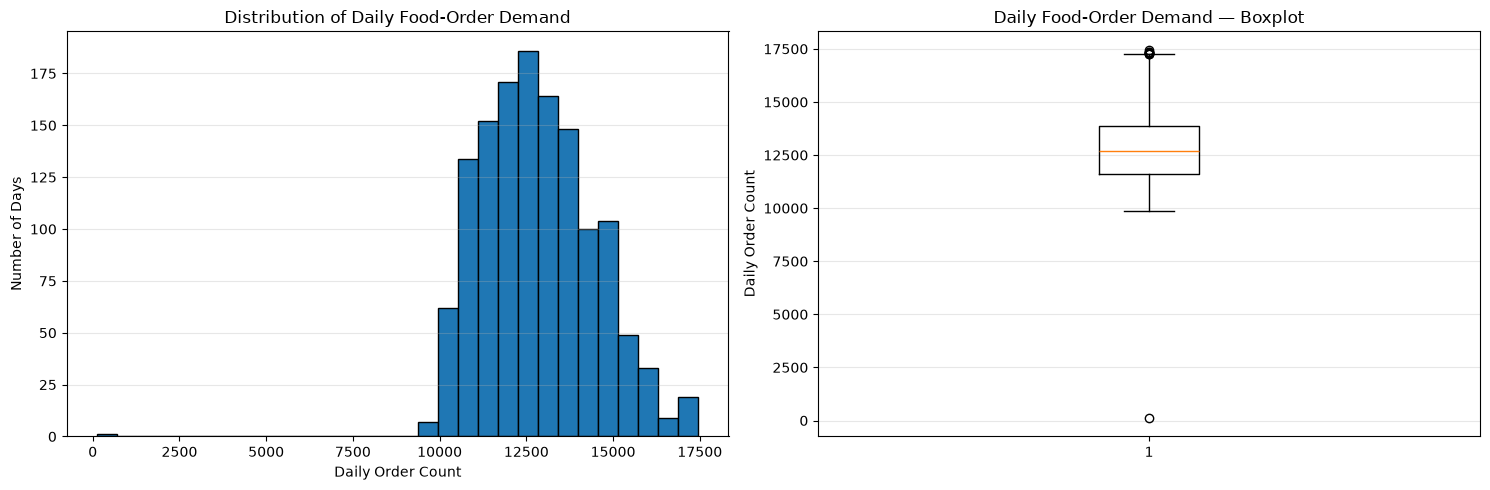

In [93]:
# ============================================================
# DAILY DEMAND DISTRIBUTION VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(
    daily_demand["order_count"],
    bins=30,
    edgecolor="black"
)

axes[0].set_title("Distribution of Daily Food-Order Demand")
axes[0].set_xlabel("Daily Order Count")
axes[0].set_ylabel("Number of Days")
axes[0].grid(axis="y", alpha=0.3)

# Boxplot
axes[1].boxplot(
    daily_demand["order_count"],
    vert=True
)

axes[1].set_title("Daily Food-Order Demand — Boxplot")
axes[1].set_ylabel("Daily Order Count")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [94]:
# ============================================================
# 03.3.11.2 — INVESTIGATE EXTREME DAILY DEMAND OBSERVATIONS
# ============================================================

# Display the 10 lowest-demand days
lowest_demand_days = (
    daily_demand
    .nsmallest(10, "order_count")
    .sort_values("order_date")
    .reset_index(drop=True)
)

print("=" * 75)
print("10 LOWEST-DEMAND DAYS")
print("=" * 75)

display(lowest_demand_days.round(2))

# Identify the minimum-demand date
minimum_demand_row = daily_demand.loc[
    daily_demand["order_count"].idxmin()
]

minimum_demand_date = minimum_demand_row["order_date"]

print("\nMinimum-demand date:", minimum_demand_date)
print("Orders recorded:", minimum_demand_row["order_count"])

# Display the three days before and after the minimum-demand date
nearby_days = daily_demand.loc[
    daily_demand["order_date"].between(
        minimum_demand_date - pd.Timedelta(days=3),
        minimum_demand_date + pd.Timedelta(days=3)
    )
].copy()

print("\nDemand around the minimum-demand date:")
display(nearby_days.round(2))

10 LOWEST-DEMAND DAYS


C:\Users\VENKAT_POTLA\AppData\Local\Temp\ipykernel_17572\3614515107.py:17: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(lowest_demand_days.round(2))


,order_date,order_count,total_order_value,average_order_value
0,2023-05-08,9932,3176069.01,319.78
1,2023-05-15,9878,3150296.17,318.92
2,2023-05-22,9891,3155648.42,319.04
3,2023-05-29,9930,3156446.67,317.87
4,2024-05-13,9949,3169567.68,318.58
5,2025-05-05,9922,3174833.64,319.98
6,2025-05-12,9887,3140220.69,317.61
7,2026-05-04,9897,3146418.70,317.92
8,2026-05-18,9949,3166818.19,318.31
9,2026-08-31,114,36494.92,320.13



Minimum-demand date: 2026-08-31 00:00:00
Orders recorded: 114

Demand around the minimum-demand date:


C:\Users\VENKAT_POTLA\AppData\Local\Temp\ipykernel_17572\3614515107.py:38: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(nearby_days.round(2))


,order_date,order_count,total_order_value,average_order_value
1335,2026-08-28,14151,4511700.18,318.83
1336,2026-08-29,15385,4902659.68,318.66
1337,2026-08-30,13401,4270137.56,318.64
1338,2026-08-31,114,36494.92,320.13


In [95]:
# ============================================================
# 03.3.11.2 — INVESTIGATE THE FINAL DAY
# ============================================================

# Filter transactions recorded on the final study date
final_day_orders = orders_df.loc[
    orders_df["order_timestamp"].dt.date
    == pd.Timestamp("2026-08-31").date()
].copy()

print("=" * 70)
print("FINAL-DAY TRANSACTION INVESTIGATION")
print("=" * 70)

print("Total orders:", len(final_day_orders))

print(
    "First transaction:",
    final_day_orders["order_timestamp"].min()
)

print(
    "Last transaction:",
    final_day_orders["order_timestamp"].max()
)

print("\nOrders by hour:")

final_day_orders["hour"] = (
    final_day_orders["order_timestamp"].dt.hour
)

display(
    final_day_orders
    .groupby("hour")
    .agg(order_count=("order_id", "count"))
    .reset_index()
)

FINAL-DAY TRANSACTION INVESTIGATION
Total orders: 114
First transaction: 2026-08-31 00:00:08
Last transaction: 2026-08-31 00:59:23

Orders by hour:


,hour,order_count
0,0,114


In [96]:
# ============================================================
# 03.3.11.3 — IDENTIFY COMPLETE DAILY OBSERVATIONS
# ============================================================

# Calculate transaction counts for each calendar date
daily_order_counts = (
    orders_df
    .assign(
        order_date=orders_df["order_timestamp"].dt.normalize()
    )
    .groupby("order_date")
    .size()
    .rename("order_count")
    .reset_index()
)

# Define the expected study period
expected_start = pd.Timestamp("2023-01-01")
expected_end = pd.Timestamp("2026-08-31")

# Identify dates with complete daily transaction volumes.
# Here, completeness means the daily count meets a threshold
# based on the observed daily demand distribution.
minimum_daily_orders = 9000

daily_order_counts["is_complete_day"] = (
    daily_order_counts["order_count"] >= minimum_daily_orders
)

# Summarize the results
print("=" * 70)
print("DAILY OBSERVATION COMPLETENESS CHECK")
print("=" * 70)

print("Total observed dates:", len(daily_order_counts))

print(
    "Dates meeting the daily-volume threshold:",
    daily_order_counts["is_complete_day"].sum()
)

print(
    "Dates below the daily-volume threshold:",
    (~daily_order_counts["is_complete_day"]).sum()
)

print("\nDates requiring investigation:")

display(
    daily_order_counts.loc[
        ~daily_order_counts["is_complete_day"]
    ]
)

DAILY OBSERVATION COMPLETENESS CHECK
Total observed dates: 1339
Dates meeting the daily-volume threshold: 1338
Dates below the daily-volume threshold: 1

Dates requiring investigation:


,order_date,order_count,is_complete_day
1338,2026-08-31,114,False


In [97]:
# ============================================================
# 03.3.11.4 — PREPARE COMPLETE-DAY DATA FOR ANALYSIS
# ============================================================

# Keep the original transaction dataset unchanged
# Exclude the incomplete final date from daily analysis

incomplete_date = pd.Timestamp("2026-08-31")

complete_orders_df = orders_df.loc[
    orders_df["order_timestamp"].dt.normalize() < incomplete_date
].copy()

# Generate daily order counts using complete dates only
complete_daily_demand = (
    complete_orders_df
    .assign(
        order_date=complete_orders_df["order_timestamp"].dt.normalize()
    )
    .groupby("order_date")
    .agg(
        order_count=("order_id", "count"),
        total_order_value=("order_value", "sum"),
        average_order_value=("order_value", "mean")
    )
    .reset_index()
)

# Display validation results
print("=" * 65)
print("COMPLETE-DAY DATASET VALIDATION")
print("=" * 65)

print("Original transaction rows:", len(orders_df))
print("Complete-day transaction rows:", len(complete_orders_df))
print("Daily observations:", len(complete_daily_demand))

print(
    "First complete date:",
    complete_daily_demand["order_date"].min()
)

print(
    "Last complete date:",
    complete_daily_demand["order_date"].max()
)

print(
    "Minimum daily orders:",
    complete_daily_demand["order_count"].min()
)

print(
    "Maximum daily orders:",
    complete_daily_demand["order_count"].max()
)

print("\nFirst five daily observations:")
display(complete_daily_demand.head())

print("\nLast five daily observations:")
display(complete_daily_demand.tail())

COMPLETE-DAY DATASET VALIDATION
Original transaction rows: 17188957
Complete-day transaction rows: 17188843
Daily observations: 1338
First complete date: 2023-01-01 00:00:00
Last complete date: 2026-08-30 00:00:00
Minimum daily orders: 9878
Maximum daily orders: 17460

First five daily observations:


,order_date,order_count,total_order_value,average_order_value
0,2023-01-01,12485,3976646.95,318.51
1,2023-01-02,10255,3242477.77,316.19
2,2023-01-03,10942,3481270.88,318.16
3,2023-01-04,11393,3636232.52,319.16
4,2023-01-05,11919,3792880.50,318.22



Last five daily observations:


,order_date,order_count,total_order_value,average_order_value
1333,2026-08-26,12196,3892285.16,319.14
1334,2026-08-27,12937,4119869.13,318.46
1335,2026-08-28,14151,4511700.18,318.83
1336,2026-08-29,15385,4902659.68,318.66
1337,2026-08-30,13401,4270137.56,318.64


COMPLETE-DAY DEMAND STATISTICAL SUMMARY


,daily_order_count
count,1338.00
mean,12846.67
std,1586.92
min,9878.00
25%,11618.00
50%,12679.50
75%,13879.00
max,17460.00



Mean daily orders: 12,846.67
Median daily orders: 12,679.50
Standard deviation: 1,586.92
Mean-median difference: 167.17


C:\Users\VENKAT_POTLA\AppData\Local\Temp\ipykernel_17572\994157913.py:50: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


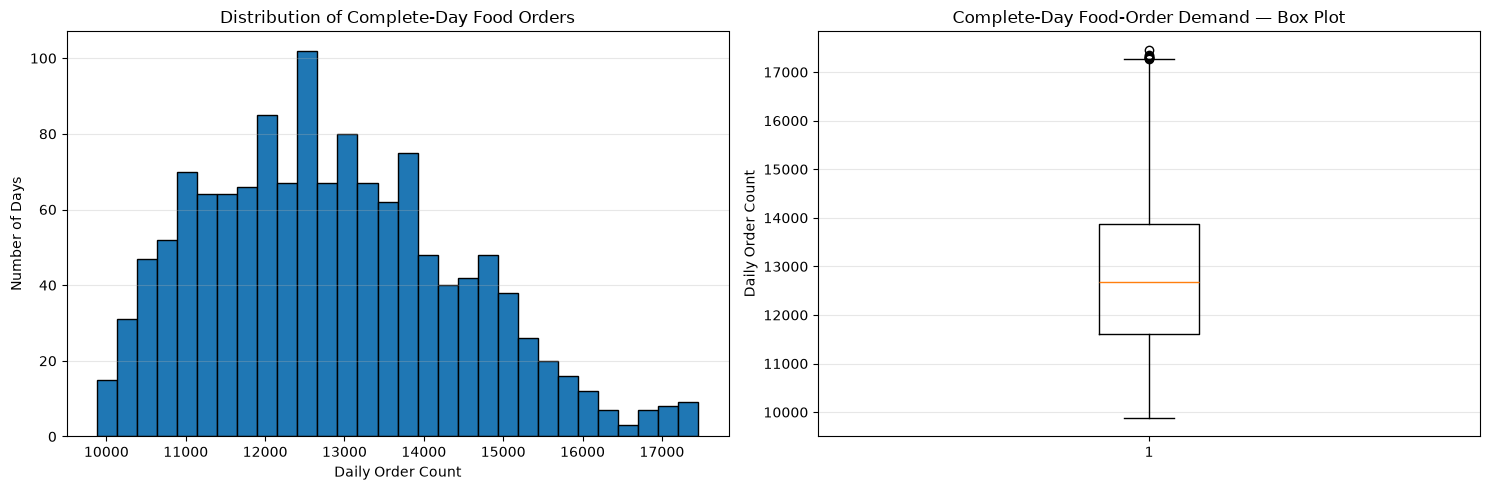

In [98]:
# ============================================================
# 03.3.11.5 — COMPLETE-DAY DEMAND DISTRIBUTION ANALYSIS
# ============================================================

import matplotlib.pyplot as plt

# Calculate descriptive statistics
daily_demand_stats = (
    complete_daily_demand["order_count"]
    .describe()
    .to_frame(name="daily_order_count")
)

print("=" * 65)
print("COMPLETE-DAY DEMAND STATISTICAL SUMMARY")
print("=" * 65)

display(daily_demand_stats.round(2))

# Calculate mean, median, and standard deviation
mean_daily_orders = complete_daily_demand["order_count"].mean()
median_daily_orders = complete_daily_demand["order_count"].median()
std_daily_orders = complete_daily_demand["order_count"].std()

print(f"\nMean daily orders: {mean_daily_orders:,.2f}")
print(f"Median daily orders: {median_daily_orders:,.2f}")
print(f"Standard deviation: {std_daily_orders:,.2f}")

print(
    "Mean-median difference:",
    f"{mean_daily_orders - median_daily_orders:,.2f}"
)

# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(
    complete_daily_demand["order_count"],
    bins=30,
    edgecolor="black"
)

axes[0].set_title("Distribution of Complete-Day Food Orders")
axes[0].set_xlabel("Daily Order Count")
axes[0].set_ylabel("Number of Days")
axes[0].grid(axis="y", alpha=0.3)

# Box plot
axes[1].boxplot(
    complete_daily_demand["order_count"],
    vert=True
)

axes[1].set_title("Complete-Day Food-Order Demand — Box Plot")
axes[1].set_ylabel("Daily Order Count")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [99]:
# ============================================================
# 03.3.11.6 — HIGH-DEMAND DAY AND OUTLIER INVESTIGATION
# ============================================================

# Calculate quartiles
q1 = complete_daily_demand["order_count"].quantile(0.25)
q3 = complete_daily_demand["order_count"].quantile(0.75)

# Calculate the interquartile range
iqr = q3 - q1

# Define statistical outlier boundaries
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify potential outliers
potential_outliers = complete_daily_demand.loc[
    (complete_daily_demand["order_count"] < lower_bound)
    | (complete_daily_demand["order_count"] > upper_bound)
].copy()

# Identify the ten highest-demand days
highest_demand_days = (
    complete_daily_demand
    .nlargest(10, "order_count")
    .copy()
)

# Display results
print("=" * 65)
print("HIGH-DEMAND DAY AND OUTLIER INVESTIGATION")
print("=" * 65)

print(f"First quartile (Q1): {q1:,.2f}")
print(f"Third quartile (Q3): {q3:,.2f}")
print(f"Interquartile range (IQR): {iqr:,.2f}")
print(f"Lower outlier boundary: {lower_bound:,.2f}")
print(f"Upper outlier boundary: {upper_bound:,.2f}")

print(f"\nPotential outlier days: {len(potential_outliers)}")

print("\nTen highest-demand days:")
display(highest_demand_days.round(2))

print("\nPotential outlier observations:")
display(potential_outliers.round(2))

HIGH-DEMAND DAY AND OUTLIER INVESTIGATION
First quartile (Q1): 11,618.00
Third quartile (Q3): 13,879.00
Interquartile range (IQR): 2,261.00
Lower outlier boundary: 8,226.50
Upper outlier boundary: 17,270.50

Potential outlier days: 8

Ten highest-demand days:


C:\Users\VENKAT_POTLA\AppData\Local\Temp\ipykernel_17572\732447352.py:43: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(highest_demand_days.round(2))


,order_date,order_count,total_order_value,average_order_value
349,2023-12-16,17460,5543953.30,317.52
1084,2025-12-20,17350,5531011.98,318.79
335,2023-12-02,17334,5526020.24,318.80
720,2024-12-21,17308,5493438.05,317.39
1070,2025-12-06,17293,5502619.86,318.20
713,2024-12-14,17287,5516814.95,319.13
356,2023-12-23,17283,5520747.85,319.43
1077,2025-12-13,17278,5511347.10,318.98
706,2024-12-07,17264,5492671.59,318.16
1091,2025-12-27,17205,5483373.08,318.71



Potential outlier observations:


C:\Users\VENKAT_POTLA\AppData\Local\Temp\ipykernel_17572\732447352.py:46: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(potential_outliers.round(2))


,order_date,order_count,total_order_value,average_order_value
335,2023-12-02,17334,5526020.24,318.80
349,2023-12-16,17460,5543953.30,317.52
356,2023-12-23,17283,5520747.85,319.43
713,2024-12-14,17287,5516814.95,319.13
720,2024-12-21,17308,5493438.05,317.39
1070,2025-12-06,17293,5502619.86,318.20
1077,2025-12-13,17278,5511347.10,318.98
1084,2025-12-20,17350,5531011.98,318.79


FOOD-ORDER DEMAND BY DAY OF THE WEEK


,day_name,average_orders,median_orders,minimum_orders,maximum_orders,standard_deviation,observed_days
0,Monday,10936.06,10791.00,9878,12632,706.85,191
1,Tuesday,11553.43,11358.00,10424,13460,743.48,191
2,Wednesday,12155.18,12003.00,10910,13991,781.40,191
3,Thursday,12747.62,12553.00,11489,14695,812.92,191
4,Friday,13953.88,13749.00,12618,16219,891.32,191
5,Saturday,15191.23,14968.00,13667,17460,970.57,191
6,Sunday,13386.45,13172.50,12073,15574,873.28,192



HIGHEST AVERAGE-DEMAND WEEKDAY
Day: Saturday
Average orders: 15191.23

LOWEST AVERAGE-DEMAND WEEKDAY
Day: Monday
Average orders: 10936.06


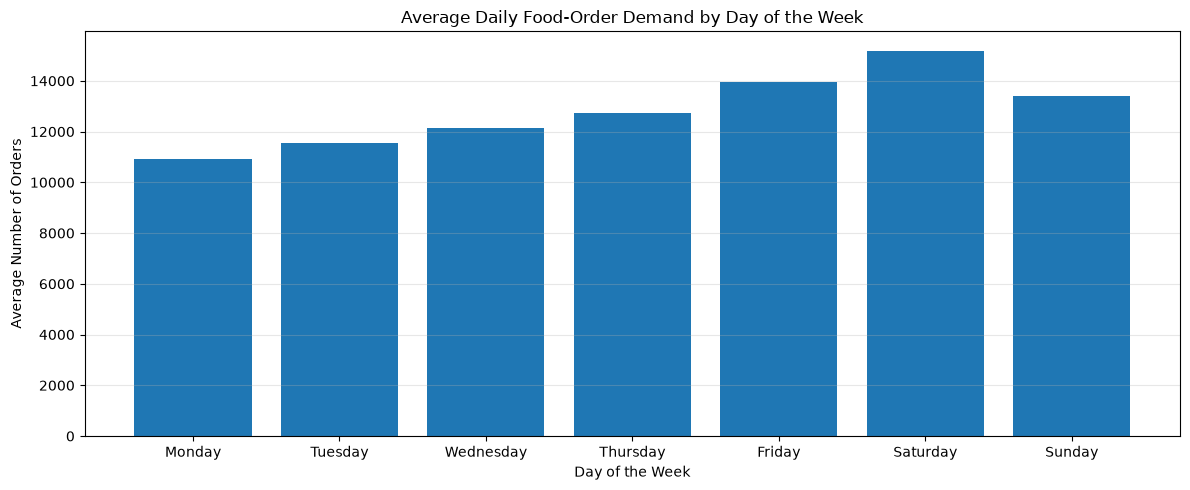

In [100]:
# ============================================================
# 03.3.11.7 — DAY-OF-WEEK DEMAND ANALYSIS
# ============================================================

# Create a copy of the complete daily dataset
weekday_demand_df = complete_daily_demand.copy()

# Extract weekday information
weekday_demand_df["day_of_week"] = (
    weekday_demand_df["order_date"].dt.dayofweek
)

weekday_demand_df["day_name"] = (
    weekday_demand_df["order_date"].dt.day_name()
)

# Aggregate daily demand by weekday
weekday_demand_summary = (
    weekday_demand_df
    .groupby(["day_of_week", "day_name"])
    .agg(
        average_orders=("order_count", "mean"),
        median_orders=("order_count", "median"),
        minimum_orders=("order_count", "min"),
        maximum_orders=("order_count", "max"),
        standard_deviation=("order_count", "std"),
        observed_days=("order_count", "count")
    )
    .reset_index()
    .sort_values("day_of_week")
)

print("=" * 75)
print("FOOD-ORDER DEMAND BY DAY OF THE WEEK")
print("=" * 75)

display(
    weekday_demand_summary
    .drop(columns="day_of_week")
    .round(2)
)

# Identify the highest- and lowest-demand weekdays
highest_demand_weekday = weekday_demand_summary.loc[
    weekday_demand_summary["average_orders"].idxmax()
]

lowest_demand_weekday = weekday_demand_summary.loc[
    weekday_demand_summary["average_orders"].idxmin()
]

print("\nHIGHEST AVERAGE-DEMAND WEEKDAY")
print("Day:", highest_demand_weekday["day_name"])
print(
    "Average orders:",
    round(highest_demand_weekday["average_orders"], 2)
)

print("\nLOWEST AVERAGE-DEMAND WEEKDAY")
print("Day:", lowest_demand_weekday["day_name"])
print(
    "Average orders:",
    round(lowest_demand_weekday["average_orders"], 2)
)

# Visualize average demand by weekday
plt.figure(figsize=(12, 5))

plt.bar(
    weekday_demand_summary["day_name"],
    weekday_demand_summary["average_orders"]
)

plt.title("Average Daily Food-Order Demand by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Number of Orders")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

WEEKDAY VS. WEEKEND DEMAND COMPARISON


,day_type,average_daily_orders,median_daily_orders,minimum_daily_orders,maximum_daily_orders,standard_deviation,observed_days
0,Weekday,12269.24,12131.00,9878,16219,1302.34,955
1,Weekend,14286.48,14334.00,12073,17460,1290.84,383



Average weekday demand: 12,269.24
Average weekend demand: 14,286.48
Absolute difference: 2,017.24
Percentage difference: 16.44%


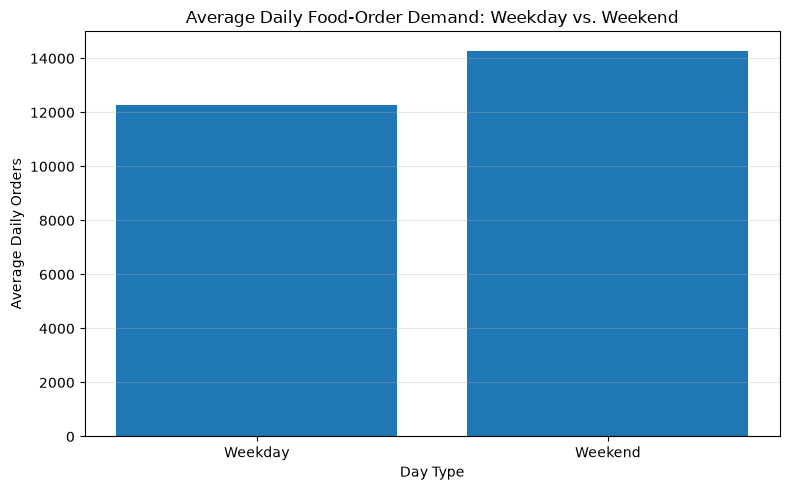

In [101]:
# ============================================================
# 03.3.11.8 — WEEKDAY VS. WEEKEND DEMAND COMPARISON
# ============================================================

# Create a copy of the complete daily dataset
weekday_weekend_df = complete_daily_demand.copy()

# Extract day of week: Monday=0, Sunday=6
weekday_weekend_df["day_of_week"] = (
    weekday_weekend_df["order_date"].dt.dayofweek
)

# Classify days
weekday_weekend_df["day_type"] = weekday_weekend_df[
    "day_of_week"
].apply(
    lambda day: "Weekend" if day >= 5 else "Weekday"
)

# Aggregate demand by day type
day_type_summary = (
    weekday_weekend_df
    .groupby("day_type")
    .agg(
        average_daily_orders=("order_count", "mean"),
        median_daily_orders=("order_count", "median"),
        minimum_daily_orders=("order_count", "min"),
        maximum_daily_orders=("order_count", "max"),
        standard_deviation=("order_count", "std"),
        observed_days=("order_count", "count")
    )
    .reindex(["Weekday", "Weekend"])
    .reset_index()
)

print("=" * 70)
print("WEEKDAY VS. WEEKEND DEMAND COMPARISON")
print("=" * 70)

display(day_type_summary.round(2))

# Extract average demand values
weekday_avg = day_type_summary.loc[
    day_type_summary["day_type"] == "Weekday",
    "average_daily_orders"
].iloc[0]

weekend_avg = day_type_summary.loc[
    day_type_summary["day_type"] == "Weekend",
    "average_daily_orders"
].iloc[0]

# Calculate absolute and percentage differences
demand_difference = weekend_avg - weekday_avg

percentage_difference = (
    demand_difference / weekday_avg
) * 100

print(f"\nAverage weekday demand: {weekday_avg:,.2f}")
print(f"Average weekend demand: {weekend_avg:,.2f}")
print(f"Absolute difference: {demand_difference:,.2f}")
print(f"Percentage difference: {percentage_difference:.2f}%")

# Visualize the comparison
plt.figure(figsize=(8, 5))

plt.bar(
    day_type_summary["day_type"],
    day_type_summary["average_daily_orders"]
)

plt.title("Average Daily Food-Order Demand: Weekday vs. Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Orders")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 03.3.11.8 — Weekday vs. Weekend Demand Comparison

**Objective:** Compare average daily food-order demand between weekdays and weekends using the complete-day dataset.

#### Key Findings

- **Average weekday demand:** 12,269.24 orders per day.
- **Average weekend demand:** 14,286.48 orders per day.
- **Absolute demand difference:** 2,017.24 orders per day.
- **Percentage difference:** Weekend demand is approximately 16.44% higher than weekday demand.
- **Median demand:** 12,131 orders on weekdays and 14,334 orders on weekends.
- **Observed days:** 955 weekdays and 383 weekend days.

#### Interpretation

The synthetic dataset exhibits higher average and median demand on weekends than on weekdays. The difference is consistent with the weekday-specific demand multipliers used during synthetic data generation.

The weekday and weekend standard deviations are similar, indicating comparable absolute variability despite their different average demand levels.

#### Research Significance

Weekday/weekend patterns are useful temporal features for food-demand forecasting. They can help forecasting models capture recurring weekly demand patterns.

These results describe the synthetic dataset and should not be interpreted as empirical evidence of actual customer behavior in Hyderabad.

#### Conclusion

Weekend demand is approximately 16.44% higher than weekday demand in the generated dataset. The observed pattern provides a useful foundation for subsequent temporal feature engineering and forecasting experiments.

03.3.11.9 — Daily Demand Trend Analysis
Objective

Analyze daily food-order demand over the study period to identify:

Long-term demand trends.
Short-term fluctuations.
Weekly patterns using a 7-day rolling average.
Monthly-level trends using a 30-day rolling average.

DAILY FOOD-ORDER DEMAND TREND ANALYSIS
Number of complete days: 1,339
Study period: 2023-01-01 to 2026-08-31
Average daily orders: 12,837.16
Median daily orders: 12,679.00
Minimum daily orders: 114
Maximum daily orders: 17,460


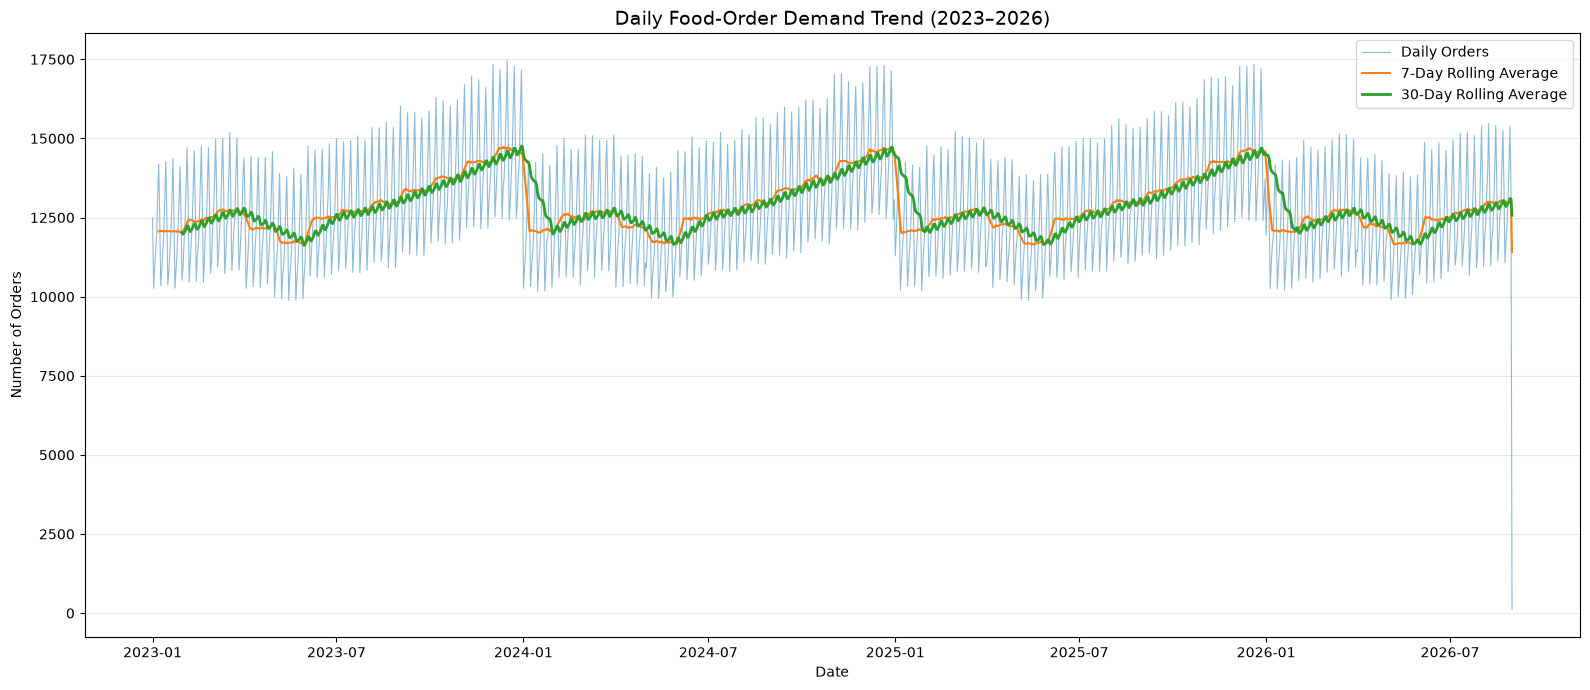

In [102]:
# ============================================================
# 03.3.11.9 — DAILY DEMAND TREND ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Create a copy of the complete-day dataset
daily_trend = daily_demand.copy()

# Ensure dates are in datetime format
daily_trend["order_date"] = pd.to_datetime(
    daily_trend["order_date"]
)

# Sort observations chronologically
daily_trend = daily_trend.sort_values(
    "order_date"
).reset_index(drop=True)

# Calculate rolling averages
daily_trend["rolling_7_day"] = (
    daily_trend["order_count"]
    .rolling(window=7, min_periods=7)
    .mean()
)

daily_trend["rolling_30_day"] = (
    daily_trend["order_count"]
    .rolling(window=30, min_periods=30)
    .mean()
)

# Display dataset information
print("=" * 75)
print("DAILY FOOD-ORDER DEMAND TREND ANALYSIS")
print("=" * 75)

print(f"Number of complete days: {len(daily_trend):,}")
print(
    f"Study period: {daily_trend['order_date'].min().date()} "
    f"to {daily_trend['order_date'].max().date()}"
)

print(
    f"Average daily orders: "
    f"{daily_trend['order_count'].mean():,.2f}"
)

print(
    f"Median daily orders: "
    f"{daily_trend['order_count'].median():,.2f}"
)

print(
    f"Minimum daily orders: "
    f"{daily_trend['order_count'].min():,}"
)

print(
    f"Maximum daily orders: "
    f"{daily_trend['order_count'].max():,}"
)

# Plot daily demand and rolling averages
plt.figure(figsize=(16, 7))

plt.plot(
    daily_trend["order_date"],
    daily_trend["order_count"],
    label="Daily Orders",
    linewidth=0.8,
    alpha=0.5
)

plt.plot(
    daily_trend["order_date"],
    daily_trend["rolling_7_day"],
    label="7-Day Rolling Average",
    linewidth=1.5
)

plt.plot(
    daily_trend["order_date"],
    daily_trend["rolling_30_day"],
    label="30-Day Rolling Average",
    linewidth=2
)

plt.title(
    "Daily Food-Order Demand Trend (2023–2026)",
    fontsize=14
)

plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

CORRECTED DAILY FOOD-ORDER DEMAND TREND
Complete days: 1,338
First date: 2023-01-01
Last date: 2026-08-30
Average daily orders: 12,846.67
Minimum daily orders: 9,878
Maximum daily orders: 17,460


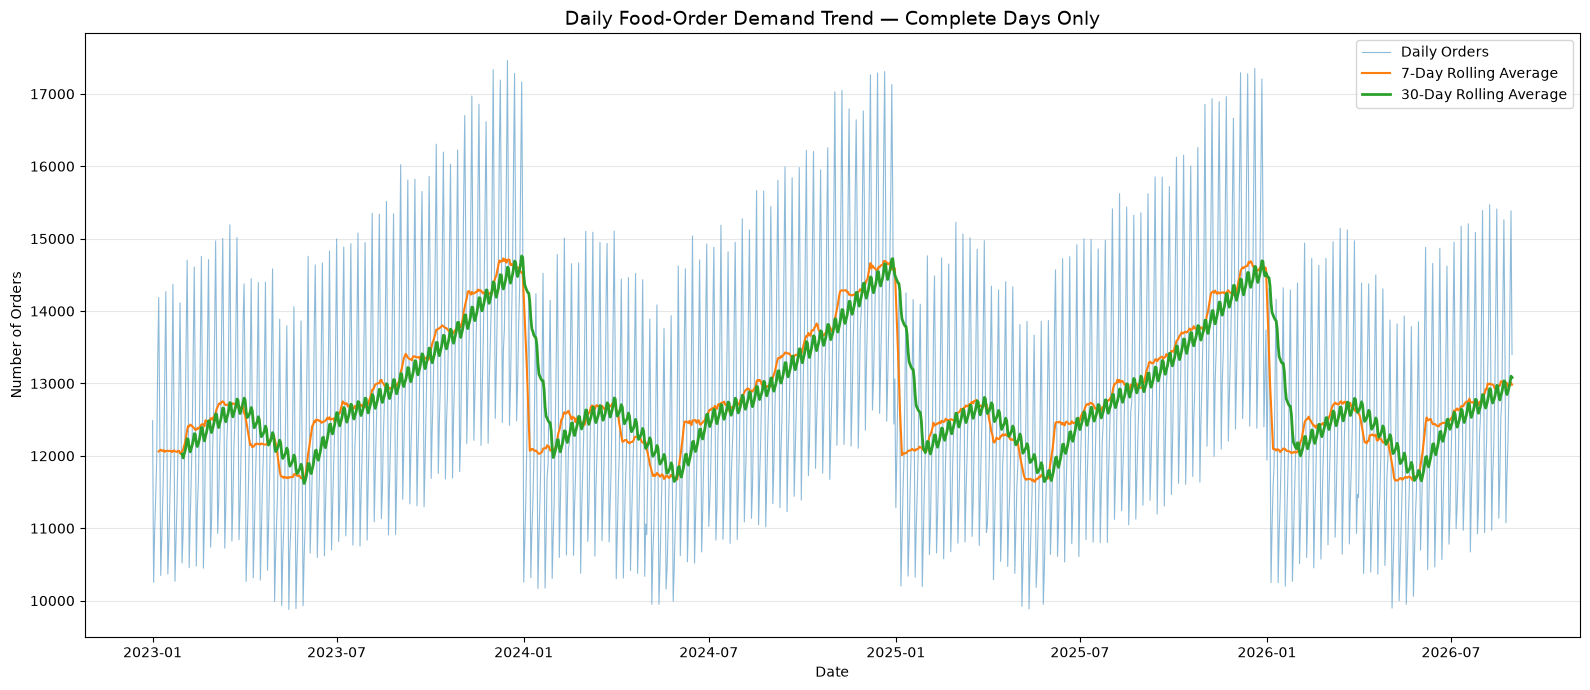

In [104]:
# ============================================================
# CORRECT DAILY DEMAND TREND — COMPLETE DAYS ONLY
# ============================================================

# Copy the existing daily demand dataset
daily_trend = daily_demand.copy()

# Ensure the date column is in datetime format
daily_trend["order_date"] = pd.to_datetime(
    daily_trend["order_date"]
)

# Remove the incomplete final day: 31 August 2026
daily_trend = daily_trend[
    daily_trend["order_date"].dt.date
    < pd.Timestamp("2026-08-31").date()
].copy()

# Sort observations chronologically
daily_trend = (
    daily_trend
    .sort_values("order_date")
    .reset_index(drop=True)
)

# Calculate rolling averages
daily_trend["rolling_7_day"] = (
    daily_trend["order_count"]
    .rolling(window=7, min_periods=7)
    .mean()
)

daily_trend["rolling_30_day"] = (
    daily_trend["order_count"]
    .rolling(window=30, min_periods=30)
    .mean()
)

# Display corrected statistics
print("=" * 65)
print("CORRECTED DAILY FOOD-ORDER DEMAND TREND")
print("=" * 65)

print(f"Complete days: {len(daily_trend):,}")
print(f"First date: {daily_trend['order_date'].min().date()}")
print(f"Last date: {daily_trend['order_date'].max().date()}")
print(f"Average daily orders: {daily_trend['order_count'].mean():,.2f}")
print(f"Minimum daily orders: {daily_trend['order_count'].min():,}")
print(f"Maximum daily orders: {daily_trend['order_count'].max():,}")

# Plot the corrected trend
plt.figure(figsize=(16, 7))

plt.plot(
    daily_trend["order_date"],
    daily_trend["order_count"],
    label="Daily Orders",
    linewidth=0.8,
    alpha=0.5
)

plt.plot(
    daily_trend["order_date"],
    daily_trend["rolling_7_day"],
    label="7-Day Rolling Average",
    linewidth=1.5
)

plt.plot(
    daily_trend["order_date"],
    daily_trend["rolling_30_day"],
    label="30-Day Rolling Average",
    linewidth=2
)

plt.title(
    "Daily Food-Order Demand Trend — Complete Days Only",
    fontsize=14
)
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 03.3.11.9 — Daily Demand Trend Analysis

#### Objective
Analyze daily food-order demand across the study period to identify
long-term trends, short-term fluctuations, and recurring temporal patterns.

#### Methodology
- Used the validated complete-day dataset covering January 1, 2023,
  to August 30, 2026.
- Excluded the incomplete observation for August 31, 2026.
- Calculated 7-day and 30-day rolling averages to smooth daily
  fluctuations and examine broader demand movements.
- Visualized daily order counts alongside both rolling averages.

#### Key Findings
1. The dataset contains 1,338 complete daily observations.
2. Average daily demand is 12,846.67 orders.
3. Daily demand ranges from 9,878 to 17,460 orders.
4. The smoothed trend displays recurring increases and decreases
   across the observed years.
5. Demand generally increases during the second half of the year,
   with higher levels toward the end of the year.
6. The 7-day rolling average helps reveal short-term patterns,
   while the 30-day rolling average highlights broader movements.

#### Research Implications
- Temporal patterns should be considered during feature engineering.
- Seasonal forecasting methods should be evaluated against appropriate
  baseline models.
- Rolling-origin backtesting will help determine whether these patterns
  improve forecasting performance.
- Further analysis is required to quantify the contribution of calendar
  and external contextual variables.

#### Data Limitation
The order transactions are synthetically generated. Therefore, the
observed patterns describe the generated dataset and do not establish
actual food-delivery demand trends in Hyderabad.

#### Conclusion
Daily demand analysis reveals recurring temporal patterns and substantial
day-to-day variability. These observations provide a foundation for
subsequent feature engineering and comparative forecasting experiments.

### 03.3.11.10 — Year-over-Year Daily Demand Comparison

#### Objective
Analyze and compare average daily food-order demand across calendar years
to identify changes in demand levels and year-over-year variation.

#### Analysis Scope
- Calculate annual total orders and average daily orders.
- Compare median daily demand across calendar years.
- Examine minimum and maximum daily demand for each year.
- Calculate year-over-year percentage changes in average daily orders.
- Visualize annual demand differences using a bar chart.

#### Research Significance
Year-over-year comparison helps examine how demand levels vary across
the study period. It provides an initial understanding of temporal
changes and supports subsequent forecasting and model evaluation.

#### Important Consideration
The dataset covers January 2023 through August 2026. Therefore, 2026
represents a partial calendar year. Annual total orders must not be
compared directly with totals from complete calendar years. Differences
in seasonal coverage must also be considered when interpreting average
daily demand.

#### Expected Outcome
A year-wise statistical summary and visualization of average daily
food-order demand, together with year-over-year percentage changes.

YEAR-OVER-YEAR DAILY DEMAND COMPARISON


,year,observed_days,total_orders,average_daily_orders,median_daily_orders,minimum_daily_orders,maximum_daily_orders,daily_demand_std,yoy_change_pct
0,2023,365,4724838,12944.76,12767.00,9878,17460,1634.04,NaN
1,2024,366,4734697,12936.33,12776.00,9949,17308,1628.42,-0.07
2,2025,365,4722182,12937.48,12809.00,9887,17350,1591.42,0.01
3,2026,242,3007126,12426.14,12340.50,9897,15468,1371.08,-3.95


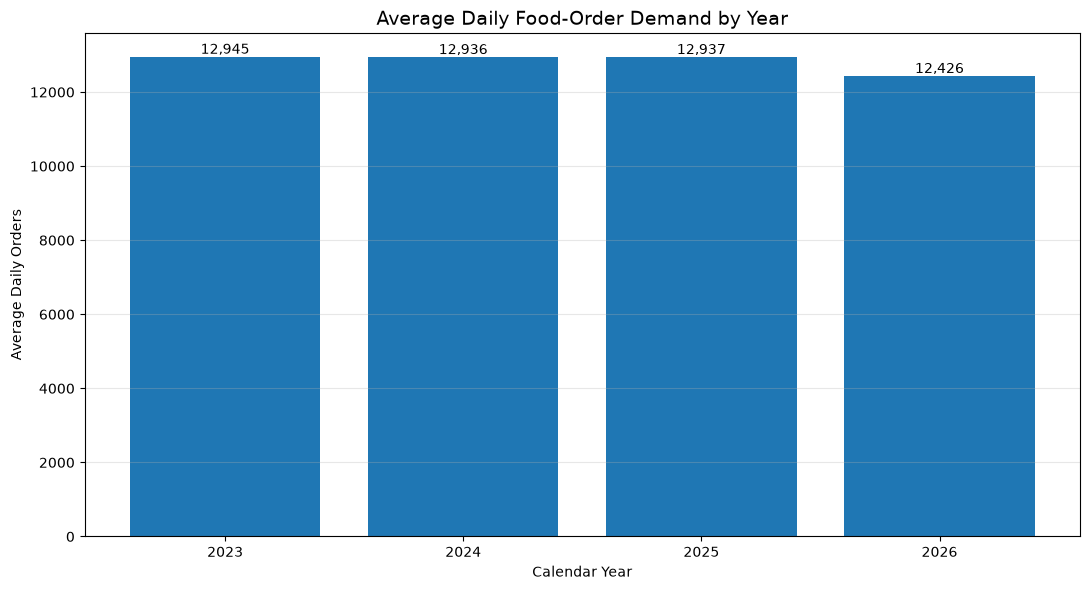


YEAR-OVER-YEAR CHANGE IN AVERAGE DAILY DEMAND
-------------------------------------------------------


,year,average_daily_orders,yoy_change_pct
0,2023,12944.76,NaN
1,2024,12936.33,-0.07
2,2025,12937.48,0.01
3,2026,12426.14,-3.95


In [105]:
# ============================================================
# 03.3.11.10 — YEAR-OVER-YEAR DAILY DEMAND COMPARISON
# ============================================================

# Use the validated complete-day dataset
yearly_demand = daily_trend.copy()

# Extract calendar year
yearly_demand["year"] = (
    yearly_demand["order_date"].dt.year
)

# Calculate annual demand statistics
yearly_demand_summary = (
    yearly_demand
    .groupby("year")
    .agg(
        observed_days=("order_count", "count"),
        total_orders=("order_count", "sum"),
        average_daily_orders=("order_count", "mean"),
        median_daily_orders=("order_count", "median"),
        minimum_daily_orders=("order_count", "min"),
        maximum_daily_orders=("order_count", "max"),
        daily_demand_std=("order_count", "std")
    )
    .reset_index()
)

# Calculate year-over-year change in average daily orders
yearly_demand_summary["yoy_change_pct"] = (
    yearly_demand_summary["average_daily_orders"]
    .pct_change()
    .mul(100)
)

# Display annual statistics
print("=" * 75)
print("YEAR-OVER-YEAR DAILY DEMAND COMPARISON")
print("=" * 75)

display(yearly_demand_summary.round(2))

# Visualize average daily demand by year
plt.figure(figsize=(11, 6))

bars = plt.bar(
    yearly_demand_summary["year"].astype(str),
    yearly_demand_summary["average_daily_orders"]
)

plt.title(
    "Average Daily Food-Order Demand by Year",
    fontsize=14
)
plt.xlabel("Calendar Year")
plt.ylabel("Average Daily Orders")
plt.grid(axis="y", alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# Display year-over-year changes
print("\nYEAR-OVER-YEAR CHANGE IN AVERAGE DAILY DEMAND")
print("-" * 55)

display(
    yearly_demand_summary[
        ["year", "average_daily_orders", "yoy_change_pct"]
    ].round(2)
)

### 03.3.11.10 — Year-over-Year Daily Demand Comparison

#### Objective
Compare average daily food-order demand across calendar years to
identify changes in demand levels and year-over-year variation.

#### Key Findings

1. **2023:** Average daily demand was 12,944.76 orders across 365 days.

2. **2024:** Average daily demand was 12,936.33 orders across 366 days,
   representing a 0.07% decrease compared with 2023.

3. **2025:** Average daily demand was 12,937.48 orders across 365 days,
   representing an approximately 0.01% increase compared with 2024.

4. **2026:** Average daily demand was 12,426.14 orders across 242
   complete days, covering January 1 through August 30. The observed
   average was 3.95% lower than the 2025 average.

#### Research Interpretation

- Average daily demand remained relatively stable from 2023 through 2025.
- The annual averages show limited variation during these three
  complete calendar years.
- The lower average observed in 2026 requires cautious interpretation
  because the year is incomplete and covers a different seasonal period.
- Daily, weekly, and monthly patterns may provide additional information
  for forecasting beyond annual averages.

#### Forecasting Implications

- Evaluate temporal and seasonal features during feature engineering.
- Compare forecasting models using consistent rolling-origin
  backtesting periods.
- Avoid interpreting partial-year comparisons as definitive annual
  demand growth or decline.

#### Data Limitation

The transaction dataset is synthetically generated. These findings
describe the generated data and should not be generalized to actual
Hyderabad food-delivery demand without real-world validation.

#### Conclusion

Year-over-year analysis shows relatively stable average daily demand
during 2023–2025, while the partial-year 2026 result is lower.
Further temporal analysis and forecasting experiments are required
to evaluate demand patterns and predictive performance.

### 03.3.11.11 — Daily Demand Autocorrelation Analysis

#### Objective
Investigate the relationship between daily food-order demand and
demand observed on previous days to identify temporal dependencies
in the generated dataset.

#### Analysis Scope
- Examine autocorrelation in daily order counts.
- Analyze relationships between demand and previous-day observations.
- Investigate potential weekly and longer-term recurring patterns.
- Visualize autocorrelation using an autocorrelation plot.
- Identify temporal dependencies that may be useful for forecasting.

#### Research Significance
Autocorrelation analysis helps determine whether historical demand
contains information about subsequent demand. It can support the
selection of lag features and inform the evaluation of time-series
forecasting models.

#### Important Considerations
- Use the validated complete-day dataset.
- Preserve chronological ordering.
- Interpret autocorrelation in the context of the synthetic
  demand-generation process.
- Do not interpret autocorrelation alone as proof of causation.

#### Expected Outcome
An autocorrelation analysis identifying potentially useful temporal
lags for subsequent feature engineering and forecasting experiments.

DAILY DEMAND AUTOCORRELATION ANALYSIS
Number of daily observations: 1,338
Study period: 2023-01-01 to 2026-08-30

AUTOCORRELATION AT SELECTED LAGS


,lag_days,autocorrelation
0,1,0.61
1,2,0.02
2,3,-0.23
3,7,0.96
4,14,0.93
5,21,0.90
6,28,0.86
7,30,-0.09


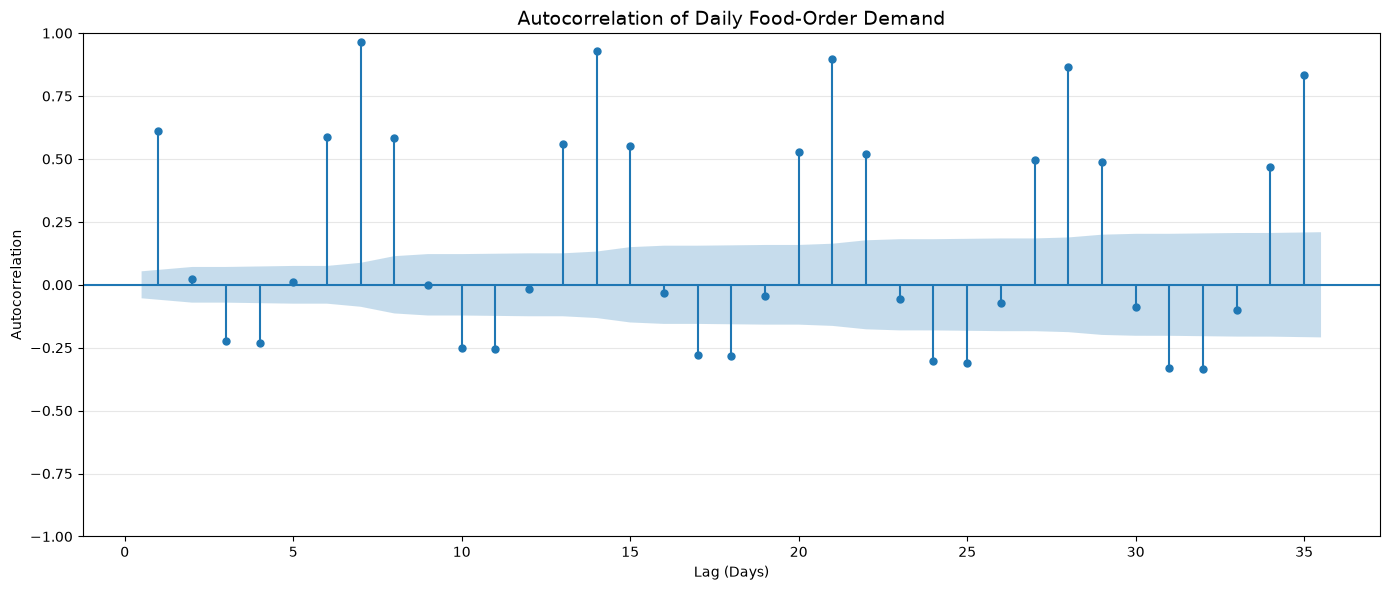


STRONGEST SELECTED LAG
----------------------------------------
Lag: 7 days
Autocorrelation: 0.9635


In [107]:
# ============================================================
# 03.3.11.11 — DAILY DEMAND AUTOCORRELATION ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# Use the validated complete-day dataset
autocorr_df = daily_trend.copy()

# Ensure chronological ordering
autocorr_df["order_date"] = pd.to_datetime(
    autocorr_df["order_date"]
)

autocorr_df = (
    autocorr_df
    .sort_values("order_date")
    .reset_index(drop=True)
)

# Extract daily order counts
daily_orders = autocorr_df["order_count"].astype(float)

# Calculate autocorrelation for selected lags
selected_lags = [1, 2, 3, 7, 14, 21, 28, 30]

autocorrelation_values = acf(
    daily_orders,
    nlags=max(selected_lags),
    fft=True
)

# Create a summary table
autocorrelation_summary = pd.DataFrame({
    "lag_days": selected_lags,
    "autocorrelation": [
        autocorrelation_values[lag]
        for lag in selected_lags
    ]
})

# Display results
print("=" * 70)
print("DAILY DEMAND AUTOCORRELATION ANALYSIS")
print("=" * 70)

print(f"Number of daily observations: {len(daily_orders):,}")
print(
    f"Study period: "
    f"{autocorr_df['order_date'].min().date()} to "
    f"{autocorr_df['order_date'].max().date()}"
)

print("\nAUTOCORRELATION AT SELECTED LAGS")
display(autocorrelation_summary.round(4))

# Plot autocorrelation for the first 35 lags
fig, ax = plt.subplots(figsize=(14, 6))

plot_acf(
    daily_orders,
    lags=35,
    ax=ax,
    alpha=0.05,
    zero=False
)

ax.set_title(
    "Autocorrelation of Daily Food-Order Demand",
    fontsize=14
)

ax.set_xlabel("Lag (Days)")
ax.set_ylabel("Autocorrelation")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Identify the strongest selected lag
strongest_lag = autocorrelation_summary.loc[
    autocorrelation_summary["autocorrelation"].abs().idxmax()
]

print("\nSTRONGEST SELECTED LAG")
print("-" * 40)
print(f"Lag: {int(strongest_lag['lag_days'])} days")
print(
    f"Autocorrelation: "
    f"{strongest_lag['autocorrelation']:.4f}"
)

### 03.3.11.11 Daily Demand Autocorrelation Analysis

#### Objective
Analyze the autocorrelation of daily food-order demand to identify temporal dependencies and recurring patterns. This analysis helps determine whether historical demand observations can provide useful information for forecasting future demand.

#### Key Findings

- **Lag 1 day:** Autocorrelation is 0.6122, indicating a positive relationship between demand on consecutive days.
- **Lag 7 days:** Autocorrelation is 0.9635, indicating a very strong weekly recurring pattern.
- **Lag 14 days:** Autocorrelation is 0.9304, showing that a strong relationship persists across two-week intervals.
- **Lag 21 days:** Autocorrelation is 0.8971, indicating continued weekly periodicity.
- **Lag 28 days:** Autocorrelation is 0.8638, suggesting that the weekly pattern remains evident over four weeks.
- **Lag 3 days:** Autocorrelation is -0.2250, indicating a negative relationship at this lag.
- **Lag 30 days:** Autocorrelation is -0.0870, indicating a weak negative relationship at this lag.

#### Interpretation

The strongest selected autocorrelation occurs at **lag 7 days, with a value of 0.9635**. The high autocorrelation at lags 7, 14, 21, and 28 days indicates a pronounced weekly demand pattern in the dataset.

The positive lag-1 autocorrelation also suggests that demand on consecutive days is related. These temporal dependencies indicate that lag-based features and weekly seasonal forecasting methods may be useful in subsequent experiments.

However, autocorrelation alone does not establish causation or prove that a particular forecasting model will perform best. The observed patterns should be evaluated using time-aware backtesting.

#### Research Significance

This analysis establishes the temporal structure of the synthetic food-order demand dataset. The identified weekly periodicity provides a basis for developing lag features and evaluating seasonal forecasting approaches during the model-development phase.

**Status:** Completed.

In [113]:
# ============================================================
# CHECK EXISTING DAILY DEMAND DATAFRAMES
# ============================================================

import pandas as pd

print("EXISTING DAILY DEMAND DATAFRAMES")
print("=" * 60)

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if {"order_date", "order_count"}.issubset(obj.columns):
            print(f"\nVariable name: {name}")
            print(f"Shape: {obj.shape}")
            print(
                f"Date range: "
                f"{obj['order_date'].min()} to "
                f"{obj['order_date'].max()}"
            )

EXISTING DAILY DEMAND DATAFRAMES

Variable name: daily_zone_orders
Shape: (6695, 3)
Date range: 2023-01-01 to 2026-08-31

Variable name: daily_demand
Shape: (1339, 4)
Date range: 2023-01-01 00:00:00 to 2026-08-31 00:00:00

Variable name: lowest_demand_days
Shape: (10, 4)
Date range: 2023-05-08 00:00:00 to 2026-08-31 00:00:00

Variable name: nearby_days
Shape: (4, 4)
Date range: 2026-08-28 00:00:00 to 2026-08-31 00:00:00

Variable name: daily_order_counts
Shape: (1339, 3)
Date range: 2023-01-01 00:00:00 to 2026-08-31 00:00:00

Variable name: complete_daily_demand
Shape: (1338, 4)
Date range: 2023-01-01 00:00:00 to 2026-08-30 00:00:00

Variable name: potential_outliers
Shape: (8, 4)
Date range: 2023-12-02 00:00:00 to 2025-12-20 00:00:00

Variable name: highest_demand_days
Shape: (10, 4)
Date range: 2023-12-02 00:00:00 to 2025-12-27 00:00:00

Variable name: weekday_demand_df
Shape: (1338, 6)
Date range: 2023-01-01 00:00:00 to 2026-08-30 00:00:00

Variable name: weekday_weekend_df
Shape: (

### 03.3.11.12 Daily Demand Stationarity Analysis

#### Objective
Evaluate the stationarity of daily food-order demand using the Augmented Dickey-Fuller (ADF) test. Stationarity analysis helps us understand whether the statistical properties of the demand series remain stable over time.

#### Hypothesis

- **Null Hypothesis (H₀):** The time series contains a unit root and is non-stationary.
- **Alternative Hypothesis (H₁):** The time series does not contain a unit root and is stationary.

#### Methodology

1. Load the raw food-order transaction dataset.
2. Aggregate transactions into daily order counts.
3. Exclude incomplete days from the analysis.
4. Apply the Augmented Dickey-Fuller test.
5. Interpret the test statistic, p-value, and critical values.

The significance level is set to 0.05.

#### Interpretation Criteria

- **p-value < 0.05:** Reject the null hypothesis; the test provides evidence of stationarity.
- **p-value ≥ 0.05:** Fail to reject the null hypothesis; the test does not provide sufficient evidence of stationarity.

#### Research Significance

The findings will help determine whether differencing or other transformations should be investigated before applying statistical forecasting models.

The results will also be interpreted alongside the weekly seasonality and temporal patterns identified in the earlier exploratory analyses.

**Status:** In Progress.

In [114]:
# ============================================================
# 03.3.11.12 — DAILY DEMAND STATIONARITY ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller

# ------------------------------------------------------------
# STEP 1: PREPARE THE EXISTING COMPLETE-DAY DATASET
# ------------------------------------------------------------

# Reuse the dataset already created in the notebook
stationarity_data = complete_daily_demand.copy()

stationarity_data["order_date"] = pd.to_datetime(
    stationarity_data["order_date"]
)

stationarity_data = (
    stationarity_data
    .sort_values("order_date")
    .reset_index(drop=True)
)

# Extract the daily order-count series
daily_orders = pd.to_numeric(
    stationarity_data["order_count"],
    errors="raise"
).astype(float)

# ------------------------------------------------------------
# STEP 2: VALIDATE THE TIME SERIES
# ------------------------------------------------------------

if daily_orders.isna().any():
    raise ValueError("Daily demand contains missing values.")

if not np.isfinite(daily_orders.to_numpy()).all():
    raise ValueError("Daily demand contains non-finite values.")

if len(daily_orders) < 30:
    raise ValueError("Insufficient observations for the ADF test.")

if daily_orders.nunique() <= 1:
    raise ValueError("Daily demand must contain varying values.")

if stationarity_data["order_date"].duplicated().any():
    raise ValueError("Duplicate dates found in the daily demand series.")

# ------------------------------------------------------------
# STEP 3: PERFORM THE AUGMENTED DICKEY-FULLER TEST
# ------------------------------------------------------------

adf_result = adfuller(
    daily_orders,
    regression="c",
    autolag="AIC"
)

adf_statistic = adf_result[0]
p_value = adf_result[1]
used_lags = adf_result[2]
observations_used = adf_result[3]
critical_values = adf_result[4]

# ------------------------------------------------------------
# STEP 4: DISPLAY THE RESULTS
# ------------------------------------------------------------

print("=" * 70)
print("DAILY FOOD-ORDER DEMAND STATIONARITY ANALYSIS")
print("=" * 70)

print(f"Number of observations : {len(daily_orders):,}")
print(
    f"First date             : "
    f"{stationarity_data['order_date'].min():%Y-%m-%d}"
)
print(
    f"Last date              : "
    f"{stationarity_data['order_date'].max():%Y-%m-%d}"
)

print("\nAUGMENTED DICKEY-FULLER TEST")
print("-" * 70)

print(f"ADF Statistic          : {adf_statistic:.6f}")
print(f"p-value                : {p_value:.8f}")
print(f"Used Lags              : {used_lags}")
print(f"Observations Used      : {observations_used}")

print("\nCRITICAL VALUES")
print("-" * 70)

for significance, value in critical_values.items():
    print(f"{significance} : {value:.6f}")

# ------------------------------------------------------------
# STEP 5: INTERPRET THE TEST
# ------------------------------------------------------------

print("\nTEST CONCLUSION")
print("-" * 70)

if p_value < 0.05:
    print("Reject the null hypothesis at the 5% significance level.")
    print("The ADF test provides evidence against a unit root.")
else:
    print("Fail to reject the null hypothesis at the 5% significance level.")
    print("The test does not provide sufficient evidence against a unit root.")

print("\nRESEARCH NOTE")
print("-" * 70)

print(
    "Interpret the ADF result alongside the observed trend, "
    "weekly seasonality, and autocorrelation patterns."
)

print("\nStationarity analysis completed successfully.")

DAILY FOOD-ORDER DEMAND STATIONARITY ANALYSIS
Number of observations : 1,338
First date             : 2023-01-01
Last date              : 2026-08-30

AUGMENTED DICKEY-FULLER TEST
----------------------------------------------------------------------
ADF Statistic          : -3.680377
p-value                : 0.00439779
Used Lags              : 23
Observations Used      : 1314

CRITICAL VALUES
----------------------------------------------------------------------
1% : -3.435336
5% : -2.863742
10% : -2.567942

TEST CONCLUSION
----------------------------------------------------------------------
Reject the null hypothesis at the 5% significance level.
The ADF test provides evidence against a unit root.

RESEARCH NOTE
----------------------------------------------------------------------
Interpret the ADF result alongside the observed trend, weekly seasonality, and autocorrelation patterns.

Stationarity analysis completed successfully.


C:\Users\VENKAT_POTLA\AppData\Local\Temp\ipykernel_17572\3779388073.py:55: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(


### Interpretation — Daily Demand Stationarity Analysis

The Augmented Dickey-Fuller (ADF) test was performed on 1,338 complete daily food-order demand observations covering January 1, 2023, to August 30, 2026.

**Key findings:**
- ADF statistic: -3.680377
- p-value: 0.00439779
- Lags used: 23
- Observations used: 1,314

Since the p-value is below the 0.05 significance level, the null hypothesis of a unit root is rejected. The test provides evidence that the daily demand series does not contain a unit root.

However, this result does not eliminate the possibility of seasonal patterns or other forms of non-stationarity. The strong weekly autocorrelation identified in the previous analysis should also be considered.

**Research implication:** Stationarity should be evaluated alongside trend, seasonality, and autocorrelation when selecting and preparing time-series forecasting models.

## 03.3.11.13 — Daily Demand Seasonal Decomposition Analysis

### Objective
Decompose the daily food-order demand time series into its underlying components to understand the structure of demand over time.

### Analysis Components
1. **Trend:** Identifies the long-term direction of food-order demand.
2. **Seasonality:** Identifies recurring weekly demand patterns.
3. **Residual:** Captures variations not explained by the estimated trend and seasonal components.

### Methodology
- Use the validated complete-day demand dataset.
- Sort observations chronologically and verify that daily observations are continuous.
- Apply additive seasonal decomposition with a period of 7 days.
- Visualize the observed demand, trend, seasonal component, and residuals.
- Interpret the components in the context of food-demand forecasting.

### Expected Outcome
Understand the contribution of long-term trends and recurring weekly patterns to daily food-order demand. These findings will help guide the selection and preparation of time-series forecasting models.

**Note:** Seasonal decomposition is an exploratory technique. Its results do not establish the cause of observed demand patterns.

DAILY DEMAND SEASONAL DECOMPOSITION ANALYSIS
Number of observations : 1,338
First date             : 2023-01-01
Last date              : 2026-08-30
Seasonal period        : 7 days
Decomposition model    : Additive

COMPONENT STATISTICS
---------------------------------------------------------------------------


C:\Users\VENKAT_POTLA\AppData\Local\Temp\ipykernel_17572\136051886.py:64: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  decomposition = seasonal_decompose(


,Component,Mean,Standard Deviation
0,Observed,12846.67,1586.92
1,Trend,12846.25,804.24
2,Seasonality,0.40,1352.71
3,Residual,0.01,165.22


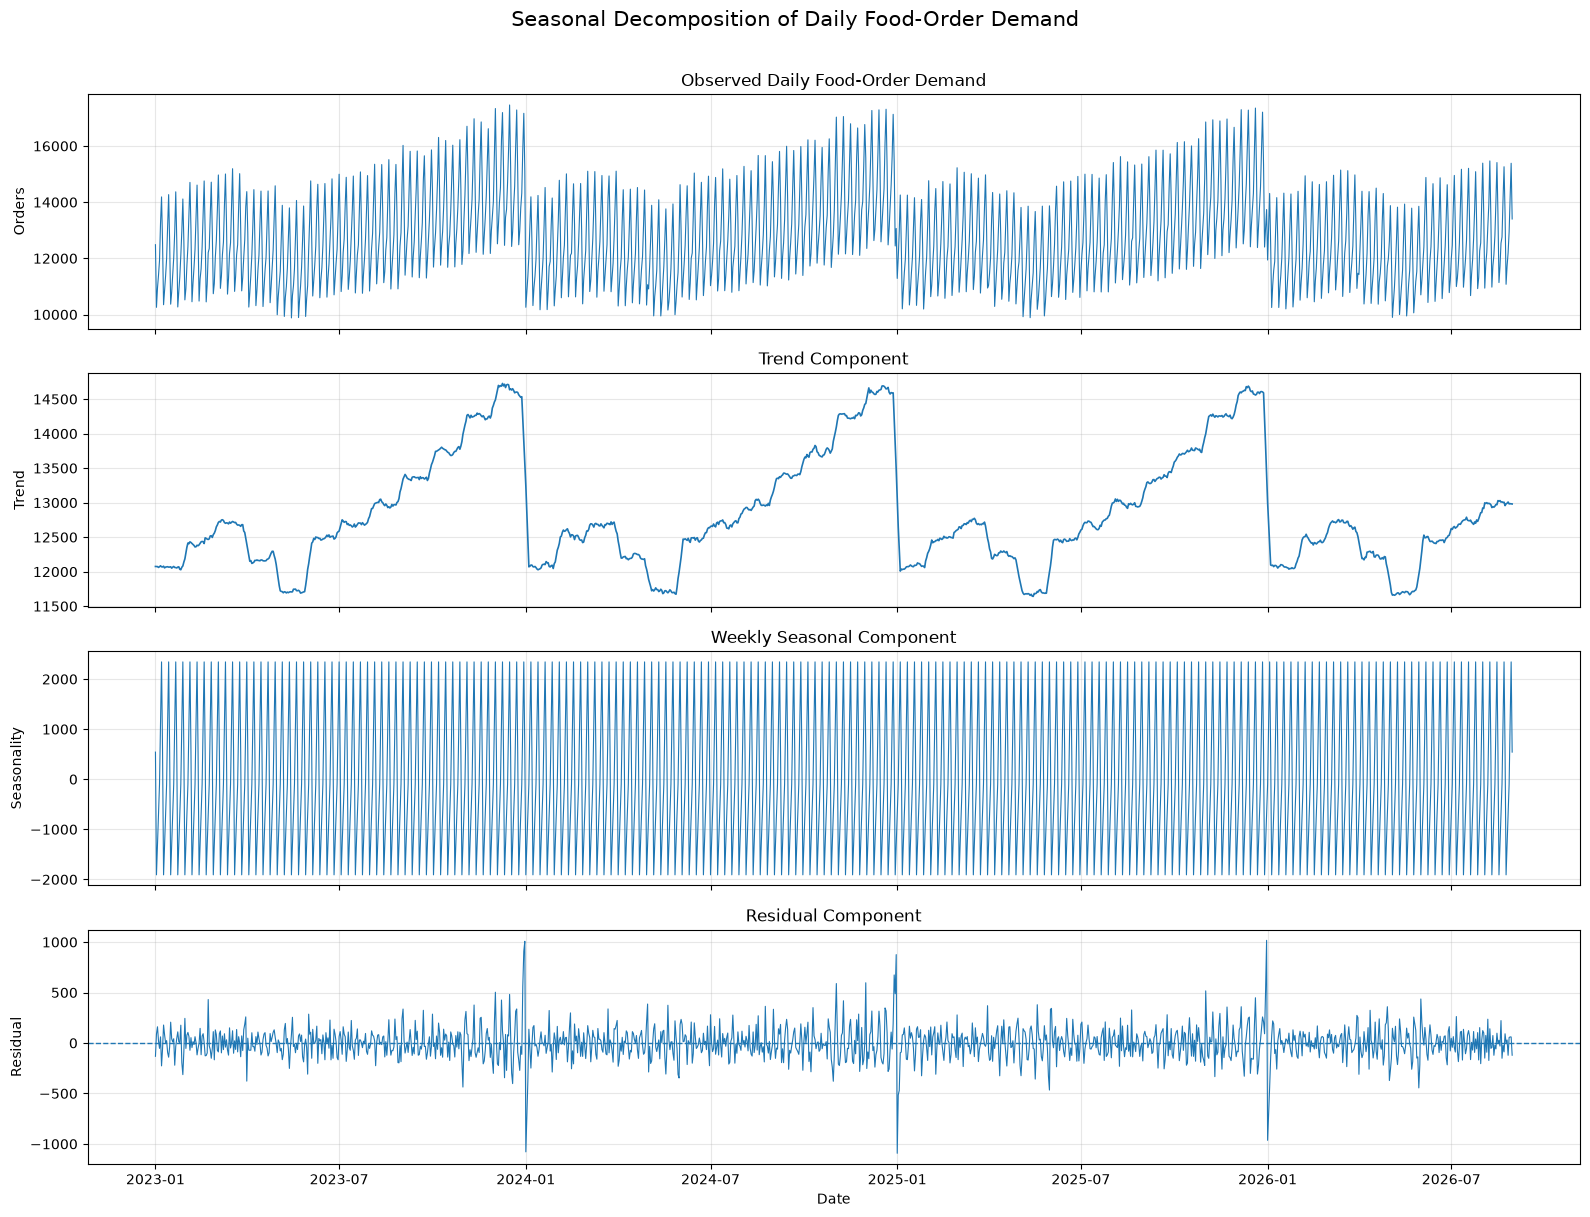


AVERAGE WEEKLY SEASONAL EFFECT
---------------------------------------------------------------------------


,day_of_week,day_name,seasonal_effect
0,0,Monday,-1908.70
1,1,Tuesday,-1292.00
2,2,Wednesday,-691.08
3,3,Thursday,-99.33
4,4,Friday,1106.31
5,5,Saturday,2343.07
6,6,Sunday,541.73



Seasonal decomposition completed successfully.


In [115]:
# ============================================================
# 03.3.11.13 — DAILY DEMAND SEASONAL DECOMPOSITION ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

# ------------------------------------------------------------
# 1. PREPARE THE DAILY DEMAND DATA
# ------------------------------------------------------------

# Reuse the validated complete-day dataset
decomposition_data = complete_daily_demand.copy()

decomposition_data["order_date"] = pd.to_datetime(
    decomposition_data["order_date"]
)

decomposition_data = (
    decomposition_data
    .sort_values("order_date")
    .drop_duplicates(subset="order_date")
    .set_index("order_date")
)

daily_orders = decomposition_data["order_count"].astype(float)

# ------------------------------------------------------------
# 2. VALIDATE THE TIME SERIES
# ------------------------------------------------------------

if daily_orders.isna().any():
    raise ValueError("Daily demand contains missing values.")

if not np.isfinite(daily_orders).all():
    raise ValueError("Daily demand contains non-finite values.")

if len(daily_orders) < 28:
    raise ValueError(
        "At least 28 daily observations are required "
        "for weekly seasonal decomposition."
    )

# Verify that dates are consecutive
expected_dates = pd.date_range(
    start=daily_orders.index.min(),
    end=daily_orders.index.max(),
    freq="D"
)

if not daily_orders.index.equals(expected_dates):
    raise ValueError(
        "Daily observations are not continuous. "
        "Check for missing dates before decomposition."
    )

# ------------------------------------------------------------
# 3. PERFORM SEASONAL DECOMPOSITION
# ------------------------------------------------------------

decomposition = seasonal_decompose(
    daily_orders,
    model="additive",
    period=7,
    extrapolate_trend="freq"
)

# Extract components
trend_component = decomposition.trend
seasonal_component = decomposition.seasonal
residual_component = decomposition.resid

# ------------------------------------------------------------
# 4. DISPLAY ANALYSIS SUMMARY
# ------------------------------------------------------------

print("=" * 75)
print("DAILY DEMAND SEASONAL DECOMPOSITION ANALYSIS")
print("=" * 75)

print(f"Number of observations : {len(daily_orders):,}")
print(f"First date             : {daily_orders.index.min():%Y-%m-%d}")
print(f"Last date              : {daily_orders.index.max():%Y-%m-%d}")
print("Seasonal period        : 7 days")
print("Decomposition model    : Additive")

print("\nCOMPONENT STATISTICS")
print("-" * 75)

component_summary = pd.DataFrame({
    "Component": ["Observed", "Trend", "Seasonality", "Residual"],
    "Mean": [
        daily_orders.mean(),
        trend_component.mean(),
        seasonal_component.mean(),
        residual_component.mean()
    ],
    "Standard Deviation": [
        daily_orders.std(),
        trend_component.std(),
        seasonal_component.std(),
        residual_component.std()
    ]
})

display(component_summary.round(2))

# ------------------------------------------------------------
# 5. VISUALIZE DECOMPOSITION COMPONENTS
# ------------------------------------------------------------

fig, axes = plt.subplots(
    4,
    1,
    figsize=(16, 12),
    sharex=True
)

axes[0].plot(
    daily_orders.index,
    daily_orders,
    linewidth=0.8
)
axes[0].set_title("Observed Daily Food-Order Demand")
axes[0].set_ylabel("Orders")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    trend_component.index,
    trend_component,
    linewidth=1.2
)
axes[1].set_title("Trend Component")
axes[1].set_ylabel("Trend")
axes[1].grid(True, alpha=0.3)

axes[2].plot(
    seasonal_component.index,
    seasonal_component,
    linewidth=0.8
)
axes[2].set_title("Weekly Seasonal Component")
axes[2].set_ylabel("Seasonality")
axes[2].grid(True, alpha=0.3)

axes[3].plot(
    residual_component.index,
    residual_component,
    linewidth=0.8
)
axes[3].axhline(y=0, linestyle="--", linewidth=1)
axes[3].set_title("Residual Component")
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Date")
axes[3].grid(True, alpha=0.3)

plt.suptitle(
    "Seasonal Decomposition of Daily Food-Order Demand",
    fontsize=15,
    y=1.01
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. SUMMARIZE WEEKLY SEASONALITY
# ------------------------------------------------------------

weekday_seasonality = pd.DataFrame({
    "day_of_week": range(7),
    "day_name": [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ],
    "seasonal_effect": [
        seasonal_component[
            seasonal_component.index.dayofweek == day
        ].mean()
        for day in range(7)
    ]
})

weekday_seasonality["seasonal_effect"] = (
    weekday_seasonality["seasonal_effect"].round(2)
)

print("\nAVERAGE WEEKLY SEASONAL EFFECT")
print("-" * 75)

display(weekday_seasonality)

print("\nSeasonal decomposition completed successfully.")

### Key Findings — Daily Demand Seasonal Decomposition

- The analysis covered 1,338 complete daily observations from January 2023 to August 2026.
- Additive seasonal decomposition was performed using a seven-day seasonal period.
- The trend component revealed recurring increases and decreases in daily demand.
- The seasonal component identified a strong weekly demand pattern.
- Saturday recorded the highest positive seasonal effect (+2,343.07 orders).
- Monday recorded the strongest negative seasonal effect (-1,908.70 orders).
- The residual component captured variations not explained by the estimated trend and weekly seasonality.
- Pronounced changes around the beginning of each year require further investigation to determine whether they originate from the synthetic demand-generation process.

**Conclusion:** The decomposition confirms that weekly seasonality is an important feature of the generated demand series. Trend, seasonal, and residual components provide useful insights for subsequent forecasting experiments.

**Research consideration:** These findings describe the synthetic dataset and should not be interpreted as empirical evidence of actual Hyderabad food-delivery demand.